### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

# Plan your approach (Assignment Activity 1)

#### What business questions is the NHS trying to answer?

- Has there been adequate staff and capacity in the networks (ICB locations)?

- What was the actual utilisation of resources?

#### How would you summarise the requirements of the scenario?

- The NHS must expand its infrastructure and resources to match its increasing population capacity. For this, it needs to budget correctly. When deciding on budget allotment, the NHS must understand the utilisation trends of each component in its network.

- My role is to use Python for data wrangling, analysis, and visualisation, and to identify possible patterns, trends, and insights from the datasets. I will investigate several smaller, analytical questions that help answer the NHS's two high-level business questions.

- The main purpose of my analytical work is to help the NHS understand whether their capacity needs to be increased or whether they need to make better use of their existing infrastructure and resources.

#### Which data sets and variables are likely to be relevant?

- Appointment dates and months

- Minimum and maximum appointment dates within each dataset

- Count of appointments

- ICB locations

- Service settings

- Appointment statuses

- Appointment modes

- Top trending hashtags (#) on the supplied Twitter (X) data set

#### What initial steps might you take to investigate the different questions?

- Import libraries

- Load the data

- Inspect and validate the data, counting unique values, checking for missing values and fully duplicated rows, determining the metadata, and performing descriptive statistics to understand, for example, the spread of the values

- Wrangle (clean and transform) the data to make it more reliable and easier to work with

- Undertake exploratory data analysis and create effective visualisations to help identify patterns and trends and draw insights

#### What challenges or risks might affect your analysis?

- Some of the data could be incomplete, inaccurate, duplicated, and/or inconsistent.

- It might not be possible to adequately answer the analytical or high-level business questions with reference to the available data.

- It might not be possible to combine the datasets in such a way that supports answering the questions.

- There's a risk that I'll confuse correlation with causation.

- I used to work for an NHS ICB, where I analysed primary care workforce data. This is helpful, because it means that I have relevant domain knowledge to help me understand the context of the assignment. However, there is a risk that I will lean too heavily on my pre-existing knowledge and deviate from what I'm expected to do for the purposes of this assignment, e.g., by seeing patterns and trends that don't exist within the data.

# Libraries

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings("ignore")

# DataFrames

In [125]:
# View all variables, including DataFrames.
%whos

Variable                                                      Type         Data/Info
------------------------------------------------------------------------------------
FuncFormatter                                                 type         <class 'matplotlib.ticker.FuncFormatter'>
ad                                                            DataFrame    Shape: (137793, 9)
ad_max_date                                                   Timestamp    2022-06-30 00:00:00
ad_min_date                                                   Timestamp    2021-12-01 00:00:00
appointment_status_percentages                                Series       Shape: (3,)
ar                                                            DataFrame    Shape: (596821, 7)
ar_agg                                                        DataFrame    Shape: (3754, 6)
ar_agg_appt_modes_by_month                                    DataFrame    Shape: (55, 3)
ar_agg_appt_status_by_month                                   Data

# User-defined Functions

In [3]:
# List all user-defined functions in their order of appearance within the Notebook.

# Data Inspection and Validation Function.
def inspect_and_validate_data(df):
    """
    This function inspects and validates the data within a specified DataFrame and returns key statistics and validation metrics.
    """

    # Count the number of unique values per column.
    unique_counts = df.nunique()
    print("Number of unique values per column:")
    print(unique_counts)

    # Count the number of missing values in each column.
    missing_counts = df.isnull().sum()
    print("\nNumber of missing values per column:")
    print(missing_counts)

    # Count the number of fully duplicated rows.
    duplicate_count = df.duplicated().sum()
    print("\nNumber of fully duplicated rows:")
    print(duplicate_count)

    # Print the DataFrame’s shape.
    shape = df.shape
    print("\nShape:")
    print(shape)

    # Print the DataFrame’s data types.
    data_types = df.dtypes
    print("\nData types:")
    print(data_types)

    # Print the DataFrame’s columns.
    columns = df.columns
    print("\nColumns:")
    print(columns)

    # Print the DataFrame’s detailed information.
    print("\nDetailed information:")
    df.info()

    # Print the DataFrame’s head.
    print("\nHead:")
    print(df.head())

    # Print the DataFrame’s tail.
    print("\nTail:")
    print(df.tail())

    # Produce the summary statistics.
    summary_stats = df.describe()
    print("\nSummary statistics:")
    print(summary_stats)

    # Return key outputs for programmatic use.
    return missing_counts, duplicate_count, summary_stats

# Perform Outlier Analysis and Generate Boxplot Function.
def perform_outlier_analysis_and_generate_boxplot(df, column_name = "count_of_appointments", palette = "colorblind", plot_title = "Outlier Analysis", 
                                                 prefix = "plot", **kwargs):
    # Detect and visualise outliers with a boxplot and the IQR method.
        
    # Calculate the IQR (interquartile range).
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Identify the outlier bounds.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Set the plot size.
    plt.figure(figsize=(10, 6))

    # Create the boxplot to visualise the outliers.
    sns.boxplot(y = df[column_name], palette = palette)

    # Customise the plot.
    plt.title(plot_title)
    plt.ylabel(column_name)

    # Save the plot.
    plt.savefig(f"{prefix}_boxplot.png", dpi = 100, bbox_inches = "tight")

    # View the plot.
    plt.show()

    # Return statistics.
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(df[(df[column_name] < lower_bound) | 
                                       (df[column_name] > upper_bound)])
    }

# Clean Label Function.
def clean_label(label):
    """
    This function changes the naming convention of a chart’s x- and y-axis labels from the original column names to the desired format.
    This is useful for professionalising stakeholder visualisations.
    """
    
    return label.replace("_", " " ).title()

# Time Series Plot Function.
def generate_time_series_plot(df, time_col, value_col, plot_title = "Time Series Plot", palette = "colorblind", reference_line = None, 
                              ref_line_label = None, prefix = "plot", y_axis_format = "millions", y_axis_limit = None, show_trendline = True, 
                              **kwargs):
    """
    The user must specify the variable names (where possible, default values will be used if unspecified).
    **kwargs indicates that the user can add their own additional parameters if desired.
    """
    # This function creates a time series plot with an optional trendline from the variables specified by the user.
    
    # Ensure the time column is in datetime format.
    df[time_col] = pd.to_datetime(df[time_col])
    
    # Sort the DataFrame by the time column.
    df.sort_values(by = time_col, inplace = True)

    # Calculate the trendline only if single column and show_trendline is True.
    p = None
    if isinstance(value_col, str) and show_trendline:
        x = np.arange(len(df))
        y = df[value_col].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)

    # Set the plot size.
    plt.figure(figsize = (12, 6))

    # Plot the time series, handling both a single column and multiple columns.
    if isinstance(value_col, list):
        # For multiple columns, plot each one.
        ax = plt.gca()
        for col in value_col:
            ax.plot(df[time_col], df[col], label=col, marker="o", markersize=6)
        ax.set_xlabel(time_col)
        ax.set_ylabel("DNA Rate (%)")
    else:
        # For a single column...
        ax = sns.lineplot(data = df, x = time_col, y = value_col, label = "Observed", marker = "o", markersize = 6, estimator = None)

    # Add labels for minimum points on each line (for multiple columns only).
    if isinstance(value_col, list):
        for col in value_col:
            min_idx = df[col].idxmin()
            
            min_val = df.loc[min_idx, col]
            min_time = df.loc[min_idx, time_col]
        
            # Label the min point.
            ax.annotate(f'{min_val:.2f}%', 
                        xy=(min_time, min_val), 
                        textcoords="offset points", 
                        xytext=(0, -15), 
                        ha='center', 
                        fontsize=9,
                        fontweight='bold',
                        color='black')
    
    # Plot the trendline only if it exists.
    if p is not None:
        x_numeric = np.arange(len(df))
        trendline_values = p(x_numeric)
        plt.plot(df[time_col].values, trendline_values, linestyle = "-", color = "red", label = "Trendline")

    # Add data labels (for single columns only).
    if isinstance(value_col, str):
        if y_axis_format == "millions":
            for idx, row in df.iterrows():
                ax.annotate(f'{row[value_col]/1000000:.2f}m', 
                    xy=(row[time_col], row[value_col]), 
                    textcoords="offset points", 
                    xytext=(0, 8), 
                    ha='center', 
                    fontsize=10)
        elif y_axis_format == "thousands":
            for idx, row in df.iterrows():
                ax.annotate(f'{row[value_col]/1000:.2f}k', 
                    xy=(row[time_col], row[value_col]), 
                    textcoords="offset points", 
                    xytext=(0, 8), 
                    ha='center', 
                    fontsize=10)
        elif y_axis_format is None:
            for idx, row in df.iterrows():
                ax.annotate(f'{row[value_col]:.2f}', 
                    xy=(row[time_col], row[value_col]), 
                    textcoords="offset points", 
                    xytext=(0, 8), 
                    ha='center', 
                    fontsize=10)
    
    # Add an optional reference line to represent capacity.
    if reference_line is not None:
        plt.axhline(y = reference_line, color = "green", linestyle = "-" , linewidth = 2, label = ref_line_label)

    # Format the y-axis based on user preference.
    if y_axis_format == "millions":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000000:.1f}m'))
    elif y_axis_format == "thousands":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.1f}k'))
    
    # Set y-axis limits (works for all formats).
    if y_axis_limit is not None:
        ax.set_ylim(0, y_axis_limit)
    elif y_axis_format is None and isinstance(value_col, str):
        max_value = df[value_col].max()
        if max_value > 100 and max_value <= 200:
            ax.set_ylim(0, 200)
        else:
            ax.set_ylim(0, 100)
    
    # Customise the plot.
    plt.title(plot_title)
    plt.xlabel(clean_label(time_col))

    # Handle the ylabel for both single and multiple columns.
    if isinstance(value_col, list):
        plt.ylabel("DNA Rate (%)")
    else:
        plt.ylabel(clean_label(value_col))

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save the plot.
    plt.savefig(f"{prefix}_timeseriesplot.png", dpi = 100, bbox_inches = "tight")

    # View the plot.
    plt.show()

# Generate Standard Bar Plot (Days) Function.
def generate_standard_bar_plot_days(df, x_variable, y_variable, plot_title = "Bar Plot", palette = "colorblind", errorbar = None, reference_line = None, 
                               ref_line_label = None, prefix = "plot", y_axis_format = "millions", show_percentages = False, total_value = None, 
                               **kwargs):
    """
    The user must specify the variable names (where possible, default values will be used if unspecified).
    **kwargs indicates that the user can add their own additional parameters if desired).
    """
    # This function creates a standard bar plot (count of days) from the variables specified by the user.

    # Set the axis labels.
    x_label = clean_label(x_variable)
    y_label = clean_label(y_variable)

    # Set the plot size.
    plt.figure(figsize = (10,6))

    # Plot the bar(s).
    ax = sns.barplot(data = df, x = x_variable, y = y_variable, palette = palette, errorbar = None, **kwargs)

    # Add a data label to the top of each column.
    if show_percentages and total_value is not None:
        for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: f'{x/total_value*100:.1f}%')
    else:
        for container in ax.containers:
            ax.bar_label(container, fmt='%d')

    # Add an optional reference line to represent capacity.
    if reference_line is not None:
        plt.axhline(y = reference_line, color = "green", linestyle = "-" , linewidth = 2, label = ref_line_label)
    
    # Customise the plot.
    plt.title(plot_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(ha = "right")
    plt.tight_layout()

    # Save the plot.
    plt.savefig(f"{prefix}_barplot.png", dpi = 100, bbox_inches = "tight")
    
    # View the plot.
    plt.show()

# Generate Standard Bar Plot (Appts) Function.
def generate_standard_bar_plot_appts(df, x_variable, y_variable, plot_title = "Bar Plot", palette = "colorblind", errorbar = None,
                                     reference_line = None, ref_line_label = None, prefix = "plot", y_axis_format = "millions",
                                     show_percentages = False, total_value = None, label_variable = None, y_axis_limit = None, **kwargs):
    """
    The user must specify the variable names (where possible, default values will be used if unspecified).
    **kwargs indicates that the user can add their own additional parameters if desired).
    """
    # This function creates a standard bar plot (count of appts) from the variables specified by the user.

    # Set the axis labels.
    x_label = clean_label(x_variable)
    y_label = clean_label(y_variable)

    # Set the plot size.
    plt.figure(figsize = (10,6))

    # Plot the bar(s).
    ax = sns.barplot(data = df, x = x_variable, y = y_variable, palette = palette, errorbar = None, **kwargs)

    # Add a data label to the top of each column.
    if label_variable is not None:
        # Add custom labels using text() instead of bar_label().
        for i, (bar, label_val) in enumerate(zip(ax.patches, df[label_variable].values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{label_val:.2f}%',
                    ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')
    elif show_percentages and total_value is not None:
        for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: f'{x/total_value*100:.1f}%')
    else:
        if y_axis_format == "millions":
            for container in ax.containers:
                ax.bar_label(container, fmt=lambda x: f'{x/1000000:.2f}m')
        elif y_axis_format == "thousands":
            for container in ax.containers:
                ax.bar_label(container, fmt=lambda x: f'{x/1000:.2f}k')
        elif y_axis_format is None:
            for container in ax.containers:
                ax.bar_label(container, fmt=lambda x: f'{x:.2f}%')
    
    # Add an optional reference line to represent capacity.
    if reference_line is not None:
        plt.axhline(y = reference_line, color = "green", linestyle = "-" , linewidth = 2, label = ref_line_label)

    # Format the y-axis based on user preference.
    if y_axis_format == "millions":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000000:.1f}m'))
    elif y_axis_format == "thousands":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.1f}k'))
    
    # Set y-axis limits (independent of format).
    if y_axis_limit is not None:
        # Use custom limit if provided.
        ax.set_ylim(0, y_axis_limit)
    else:
        # Use automatic limits based on data.
        max_value = df[y_variable].max()
        if max_value > 100 and max_value <= 200:
            ax.set_ylim(0, 200)
        elif max_value <= 100:
            ax.set_ylim(0, 100)
        else:
            ax.set_ylim(0, max_value * 1.1)
    
    # Customise the plot.
    plt.title(plot_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    # Rotate x-axis ticks only if the y_axis_format is not None.
    if y_axis_format is not None:
        plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    # Save the plot.
    plt.savefig(f"{prefix}_barplot.png", dpi = 100, bbox_inches = "tight")
    
    # View the plot.
    plt.show()


# Generate Stacked Bar Plot Function.
def generate_stacked_bar_plot(df, x_variable, hue_variable, y_variable, plot_title = "Stacked Bar Plot", palette = "colorblind", prefix = "plot", 
                              y_axis_format = "millions", label_font_size = 10, show_labels = True, **kwargs):
    """
    The user must specify the variable names (where possible, default values will be used if unspecified).
    **kwargs indicates that the user can add their own additional parameters if desired).
    """
    
    # Set the axis labels.
    x_label = clean_label(x_variable)
    y_label = clean_label(y_variable)
    hue_label = clean_label(hue_variable)

    # Set the plot size.
    plt.figure(figsize = (10, 6))

    # Group by x_variable and hue_variable, sum y_variable, then transpose.
    stacked_data = df.groupby([x_variable, hue_variable])[y_variable].sum().unstack(fill_value=0)

    # Create the stacked bar plot.
    ax = stacked_data.plot(kind = 'bar', stacked = True, ax = plt.gca(), color = sns.color_palette(palette, len(stacked_data.columns)), **kwargs)

    # Add percentage labels inside stack segments.
    if show_labels:
        # Calculate totals for each bar.
        totals = stacked_data.sum(axis=1)
        
        # Iterate through each segment and add labels.
        for container in ax.containers:
            labels = []
            for i, (val, total) in enumerate(zip(container.datavalues, totals)):
                if val > 0: # Only label non-zero segments.
                    percentage = (val / total) * 100
                    labels.append(f'{percentage:.2f}%')
                else:
                    labels.append('')
            ax.bar_label(container, labels = labels, fontsize = label_font_size, 
                        label_type = 'center', weight='bold')
    
    # Format the y-axis based on user preference.
    if y_axis_format == "millions":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000000:.1f}m'))
    elif y_axis_format == "thousands":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.1f}k'))
    elif y_axis_format is None:
        # Get the maximum value in the stacked data.
        max_value = stacked_data.sum(axis=1).max()
        
        # Set y-axis limits based on the data range.
        if max_value > 100 and max_value <= 200:
            ax.set_ylim(0, 200)
        else:
            ax.set_ylim(0, 100)

    # Customise the plot.
    plt.title(plot_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(title = hue_label, bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 0)
    plt.tight_layout()

    # Save the plot.
    plt.savefig(f"{prefix}_stacked_barplot.png", dpi = 100, bbox_inches = "tight")

    # View the plot.
    plt.show()

# Loaded Data

In [4]:
# Import the actual_duration.csv dataset as ad.
ad = pd.read_csv("actual_duration.csv")

# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


In [5]:
# Import the appointments_regional.csv dataset as ar.
ar = pd.read_csv("appointments_regional.csv")

# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [6]:
# Import the national_categories.csv dataset as nc.
nc = pd.read_csv("national_categories.csv")

# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [7]:
# Import the tweets.csv dataset as tweets.
tweets = pd.read_csv("tweets.csv")

# View the DataFrame.
tweets

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,As Arkansas’ first Comprehensive Stroke Certif...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the...,"{'hashtags': [{'text': 'PremiseHealth', 'indic...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 're...",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long w...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies...,"{'hashtags': [{'text': 'NEW', 'indices': [20, ...",#NEW,"{'iso_language_code': 'en', 'result_type': 're...",5,0,False,False,en
4,1567582720460570625,ICYMI: Our recent blogs on Cybersecurity in Ac...,"{'hashtags': [{'text': 'blogs', 'indices': [18...","#blogs, #digitaltransformation, #cybersecurity...","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
...,...,...,...,...,...,...,...,...,...,...
1169,1567583004209332227,RT @PotomacPhotonic: Potomac #Innovation Repor...,"{'hashtags': [{'text': 'Innovation', 'indices'...","#Innovation, #precisionFabrication, #Microfluidic","{'iso_language_code': 'en', 'result_type': 're...",1,0,False,False,en
1170,1567582945342267393,Not a cent towards workers who would like to a...,"{'hashtags': [{'text': 'SKPoli', 'indices': [2...","#SKPoli, #healthcare","{'iso_language_code': 'en', 'result_type': 're...",0,1,False,False,en
1171,1567582936014241792,"The @hfmaorg Region 9 presents ""The Value of E...","{'hashtags': [{'text': 'webinar', 'indices': [...","#webinar, #ESG, #healthcare","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1172,1567582892892782592,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiothe...,"{'hashtags': [{'text': 'bpt', 'indices': [30, ...","#bpt, #physiotherapy, #HealthyNation, #healthc...","{'iso_language_code': 'en', 'result_type': 're...",0,5,False,False,en


# Data Inspection, Validation, and Exploration (inc. Assignment Activity 2)

#### Data Inspection and Validation:

In [8]:
# Call the inspect_and_validate_data function for the ad DataFrame.
inspect_and_validate_data(ad)

Number of unique values per column:
sub_icb_location_code         106
sub_icb_location_ons_code     106
sub_icb_location_name         106
icb_ons_code                   42
region_ons_code                 7
appointment_date              212
actual_duration                 7
count_of_appointments        7611
dtype: int64

Number of missing values per column:
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

Number of fully duplicated rows:
0

Shape:
(137793, 8)

Data types:
sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

Columns:

(sub_icb_location_code        0
 sub_icb_location_ons_code    0
 sub_icb_location_name        0
 icb_ons_code                 0
 region_ons_code              0
 appointment_date             0
 actual_duration              0
 count_of_appointments        0
 dtype: int64,
 np.int64(0),
        count_of_appointments
 count          137793.000000
 mean             1219.080011
 std              1546.902956
 min                 1.000000
 25%               194.000000
 50%               696.000000
 75%              1621.000000
 max             15400.000000)

**Observation(s):** There are no missing values or fully duplicated rows within the dataset, which could indicate high data quality.

**Observation(s):** All columns within the dataset contain values that are objects, except for count_of_appointments, which contains integers. Therefore, mathematical operations may be performed on the values within the count_of_appointments column only.

**Observation(s):** The count_of_appointments values' mean (1219) is lower than the std (1546), which indicates high variability of values within the dataset. There is a large gap between the 1st and 3rd quartile (194 and 1621) and between the 3rd quartile and the max value (1621 and 15400), indicating that outliers are likely.

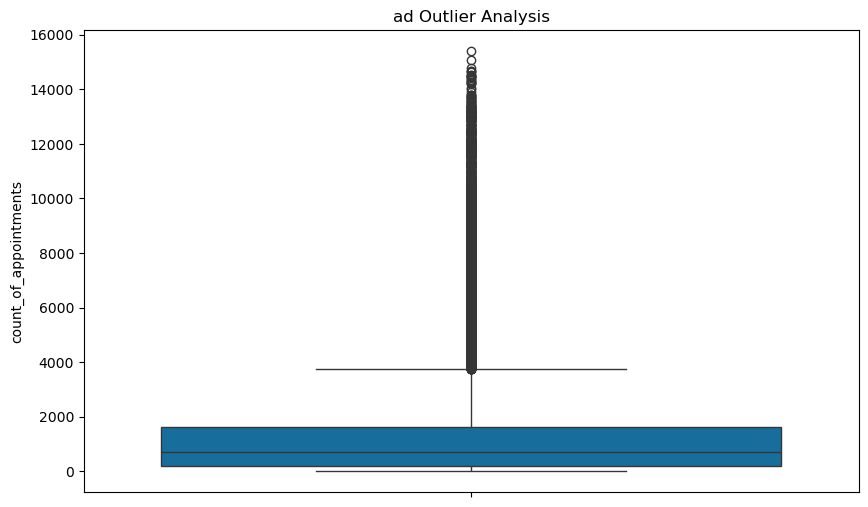

{'Q1': np.float64(194.0),
 'Q3': np.float64(1621.0),
 'IQR': np.float64(1427.0),
 'lower_bound': np.float64(-1946.5),
 'upper_bound': np.float64(3761.5),
 'outlier_count': 9291}

In [9]:
# Perform outlier analysis on the ad DataFrame and generate a boxplot.
perform_outlier_analysis_and_generate_boxplot(ad, column_name = "count_of_appointments", palette = "colorblind", 
                                              plot_title = "ad Outlier Analysis", prefix = "ad Outlier Analysis")

**Observation(s):** The IQR (1427) is large, which suggests genuine diversity within the dataset, i.e., there will have been some days on which a sub-ICB location had ~194 appointments that lasted a certain number of minutes, and other days on which the same or a different sub-ICB location had ~1621 appointments that lasted a certain number of minutes. At first, the number of outliers (9291) appears high, but this only represents 6.74% of the total dataset, which is within the expected 5-10% range for outliers. Therefore, all the outliers will be retained during data wrangling, as they are deemed likely to represent legitimate variation in the count of appointments booked across different sub-ICB locations and time periods.

In [10]:
# Call the inspect_and_validate_data function for the ar DataFrame.
inspect_and_validate_data(ar)

Number of unique values per column:
icb_ons_code                            42
appointment_month                       30
appointment_status                       3
hcp_type                                 3
appointment_mode                         5
time_between_book_and_appointment        8
count_of_appointments                22807
dtype: int64

Number of missing values per column:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

Number of fully duplicated rows:
21604

Shape:
(596821, 7)

Data types:
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment

(icb_ons_code                         0
 appointment_month                    0
 appointment_status                   0
 hcp_type                             0
 appointment_mode                     0
 time_between_book_and_appointment    0
 count_of_appointments                0
 dtype: int64,
 np.int64(21604),
        count_of_appointments
 count          596821.000000
 mean             1244.601857
 std              5856.887042
 min                 1.000000
 25%                 7.000000
 50%                47.000000
 75%               308.000000
 max            211265.000000)

**Observation(s):** The count_of_appointments in the ar DataFrame is much higher than in the ad and nc DataFrames. This is likely because the ar DataFrame includes data from 30 months, compared with the ad DataFrame which has 7 months' worth and the nc DataFrame which has 11 months' worth. If each DataFrame was filtered to show the data from a standard range, e.g., 1st December 2021 to 30th June 2022, the expectation would be that the count of appointments would be similar or the same for each.

**Observation(s):** There are no missing values within the dataset, which may indicate high data quality. However, there are 21604 full duplicated rows (3.62% of the dataset), which may indicate low data quality. Also, the preview of the datasets shows that the appointment_status, hcp_type, and appointment_mode columns contain 'unknown' values, which may indicate low data quality caused by issues with reporting.

**Observation(s):** All columns within the dataset contain values that are objects, except for count_of_appointments, which contains integers. Therefore, mathematical operations may be performed on the values within the count_of_appointments column only.

**Observation(s):** The count_of_appointments values' mean (1244) is lower than the std (5856), which indicates high variability of values within the dataset. There is a large gap between the 3rd quartile and the max value (308 and 211265), indicating that outliers are likely.

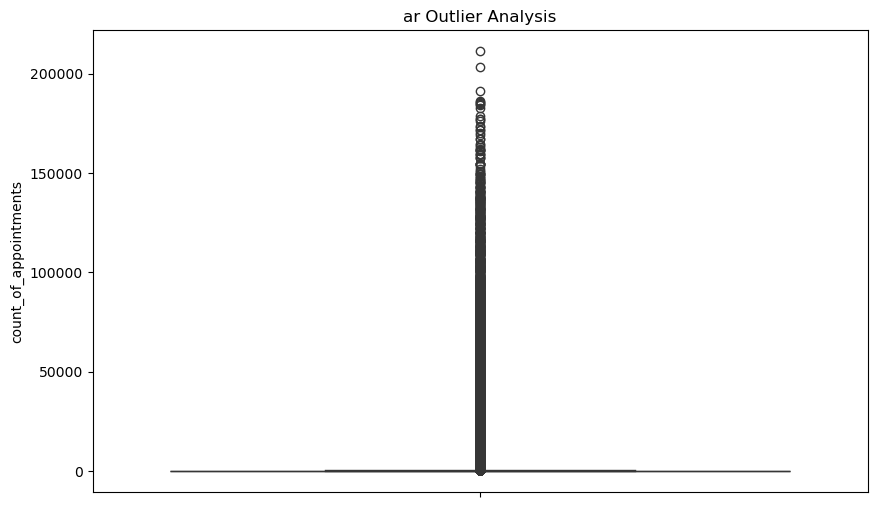

{'Q1': np.float64(7.0),
 'Q3': np.float64(308.0),
 'IQR': np.float64(301.0),
 'lower_bound': np.float64(-444.5),
 'upper_bound': np.float64(759.5),
 'outlier_count': 97348}

In [11]:
# Perform outlier analysis on the ar DataFrame and generate a boxplot.
perform_outlier_analysis_and_generate_boxplot(ar, column_name = "count_of_appointments", palette = "colorblind", 
                                              plot_title = "ar Outlier Analysis", prefix = "ar Outlier Analysis")

**Observation(s):** The IQR (301) is large, which suggests genuine diversity within the dataset. The number of outliers (97348) is high and represents 16.31% of the total dataset, which is outside the expected 5-10% range. However, the high values seem to represent scenarios in which appointments were confirmed as attended, with details of the healthcare professional type and mode being well-documented. Meanwhile, the low values mostly seem to represent records with incomplete information on attendance, healthcare professional type, and/or appointment mode. Additionally, data is aggregated by month rather than day, which amplifies the variation in values. Therefore, all the outliers will be retained during data wrangling, as they are deemed likely to represent legitimate variation in the count of appointments booked, with the caveat that rows with one or more unknown values may represent data quality limitations rather than true variation.

In [12]:
# Call the inspect_and_validate_data function for the nc DataFrame.
inspect_and_validate_data(nc)

Number of unique values per column:
appointment_date          334
icb_ons_code               42
sub_icb_location_name     106
service_setting             5
context_type                3
national_category          18
count_of_appointments    9957
appointment_month          11
dtype: int64

Number of missing values per column:
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

Number of fully duplicated rows:
0

Shape:
(817394, 8)

Data types:
appointment_date         object
icb_ons_code             object
sub_icb_location_name    object
service_setting          object
context_type             object
national_category        object
count_of_appointments     int64
appointment_month        object
dtype: object

Columns:
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', '

(appointment_date         0
 icb_ons_code             0
 sub_icb_location_name    0
 service_setting          0
 context_type             0
 national_category        0
 count_of_appointments    0
 appointment_month        0
 dtype: int64,
 np.int64(0),
        count_of_appointments
 count          817394.000000
 mean              362.183684
 std              1084.576600
 min                 1.000000
 25%                 7.000000
 50%                25.000000
 75%               128.000000
 max             16590.000000)

**Observation(s):** There are no missing values within the dataset, which may indicate high data quality.

**Observation(s):** All columns within the dataset contain values that are objects, except for count_of_appointments, which contains integers. Therefore, mathematical operations may be performed on the values within the count_of_appointments column only.

**Observation(s):** The descriptive statistics relating to the appointment_date column can be ignored because the values are objects, not integers. The count_of_appointments values' mean (362) is lower than its std (1084), which indicates high variability of values within the dataset. There is a large gap between the 3rd quartile and the max value (128 and 16590), indicating that outliers are likely.

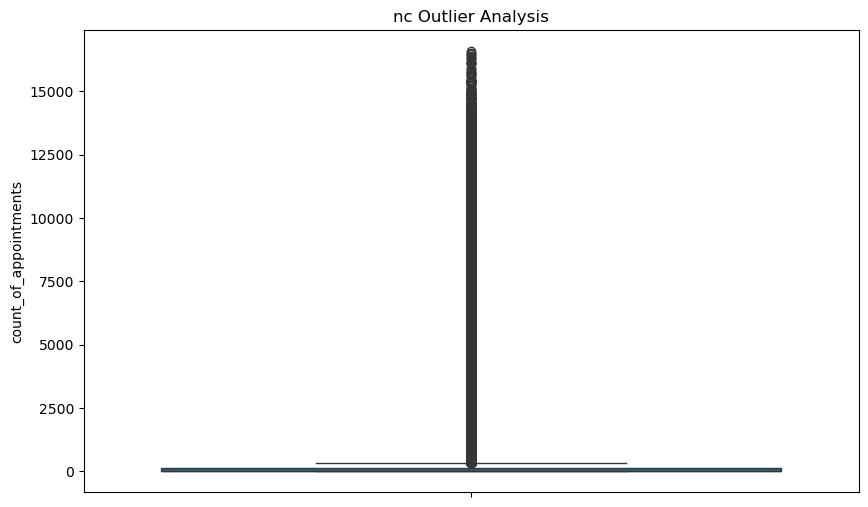

{'Q1': np.float64(7.0),
 'Q3': np.float64(128.0),
 'IQR': np.float64(121.0),
 'lower_bound': np.float64(-174.5),
 'upper_bound': np.float64(309.5),
 'outlier_count': 147958}

In [13]:
# Perform outlier analysis on the nc DataFrame and generate a boxplot.
perform_outlier_analysis_and_generate_boxplot(nc, column_name = "count_of_appointments", palette = "colorblind", 
                                              plot_title = "nc Outlier Analysis", prefix = "nc Outlier Analysis")

**Observation(s):** The IQR (121) is relatively small, indicating that most rows have low appointment counts. The number of outliers (147958) is high and represents 18.09% of the total dataset, which is outside the expected 5-10% range. However, the high values seem to represent scenarios in which the service setting, context type, and national category are well-documented. Meanwhile, the low values mostly seem to represent records in which the service setting, context type, and/or national category are "unmapped" or "inconsistent mapping". Therefore, all the outliers will be retained during data wrangling, as they are deemed likely to represent legitimate variation in the count of appointments booked, with the caveat that rows with one or more "unmapped" or "inconsistent mapping" values may represent data quality limitations rather than true variation.

#### Data Exploration (Assignment Activity 2 Questions):

**Question 1:** How many locations are there in the data set?

In [14]:
# Determine the number of locations.
# Count unique locations.
print(nc["sub_icb_location_name"].nunique())

106


In [15]:
# Determine the number of locations.
# List unique locations.
print(*sorted(nc["sub_icb_location_name"].unique()), sep="\n")

NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G
NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y
NHS Birmingham and Solihull ICB - 15E
NHS Black Country ICB - D2P2L
NHS Bristol North Somerset and South Gloucestershire ICB - 15C
NHS Buckinghamshire Oxfordshire and Berkshire West ICB - 10Q
NHS Buckinghamshire Oxfordshire and Berkshire West ICB - 14Y
NHS Buckinghamshire Oxfordshire and Berkshire West ICB - 15A
NHS Cambridgeshire and Peterborough ICB - 06H
NHS Cheshire and Merseyside ICB - 01F
NHS Cheshire and Merseyside ICB - 01J
NHS Cheshire and Merseyside ICB - 01T
NHS Cheshire and Merseyside ICB - 01V
NHS Cheshire and Merseyside ICB - 01X
NHS Cheshire and Merseyside ICB - 02E
NHS Cheshire and Merseyside ICB - 12F
NHS Cheshire and Merseyside ICB - 27D
NHS Cheshire and Merseyside ICB - 99A
NHS Cornwall and The Isles Of Scilly ICB - 11N
NHS Coventry and Warwickshire ICB - B2M3M
NHS Derby and Derbyshire ICB - 15M
NHS Devon ICB - 15N
NHS Dorset ICB - 11J
NHS Frimley ICB

**Observation:** At first, it appears as though there are 106 unique locations within the datasets. However, this is because several ICBs appear multiple times but with different sub-location codes written into their naming conventions. This is creating duplicate location values which must be amalgamated, as follows.

In [16]:
# Determine the true number of locations.
# Create the icb_location_name column within the nc DataFrame (including everything in the icb_sub_location_name column before "-")
nc["icb_location_name"] = nc["sub_icb_location_name"].str.split(" - ").str[0]

# Count truly unique locations.
print(nc["icb_location_name"].nunique())

42


In [17]:
# Determine the true number of locations.
# List truly unique locations.
print(*sorted(nc["icb_location_name"].unique()), sep="\n")

NHS Bath and North East Somerset Swindon and Wiltshire ICB
NHS Bedfordshire Luton and Milton Keynes ICB
NHS Birmingham and Solihull ICB
NHS Black Country ICB
NHS Bristol North Somerset and South Gloucestershire ICB
NHS Buckinghamshire Oxfordshire and Berkshire West ICB
NHS Cambridgeshire and Peterborough ICB
NHS Cheshire and Merseyside ICB
NHS Cornwall and The Isles Of Scilly ICB
NHS Coventry and Warwickshire ICB
NHS Derby and Derbyshire ICB
NHS Devon ICB
NHS Dorset ICB
NHS Frimley ICB
NHS Gloucestershire ICB
NHS Greater Manchester ICB
NHS Hampshire and Isle Of Wight ICB
NHS Herefordshire and Worcestershire ICB
NHS Hertfordshire and West Essex ICB
NHS Humber and North Yorkshire ICB
NHS Kent and Medway ICB
NHS Lancashire and South Cumbria ICB
NHS Leicester Leicestershire and Rutland ICB
NHS Lincolnshire ICB
NHS Mid and South Essex ICB
NHS Norfolk and Waveney ICB
NHS North Central London ICB
NHS North East London ICB
NHS North East and North Cumbria ICB
NHS North West London ICB
NHS Nort

**Observation:** The number of unique locations has fallen to 42, reflecting the amalgamation of the duplicate values. There were 42 ICBs in England at the time of this data's publication, meaning the number of locations is now accurate.

**Question 2:** What are the five locations with the highest number of appointments?



In [18]:
# Determine the top five locations based on appointment count.
nc.groupby("icb_location_name")["count_of_appointments"].sum().nlargest(5)

icb_location_name
NHS North East and North Cumbria ICB    16882235
NHS West Yorkshire ICB                  14358371
NHS Greater Manchester ICB              13857900
NHS Cheshire and Merseyside ICB         13250311
NHS North West London ICB               12142390
Name: count_of_appointments, dtype: int64

**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [19]:
# Determine the number of service settings.
# Count unique service settings.
print(nc['service_setting'].nunique())

5


In [20]:
# Determine the number of service settings.
# List unique service settings.
print(*sorted(nc['service_setting'].unique()), sep='\n')

Extended Access Provision
General Practice
Other
Primary Care Network
Unmapped


**Observation:** One of the service settings is called 'unmapped'. This option is selected when category data is not received. This is an example of a data quality issue that could affect the analysis, and therefore, warrants further investigation.

In [21]:
# Calculate the percentage that each service setting represents.
service_setting_percentages = (nc['service_setting'].value_counts() / nc['service_setting'].value_counts().sum()) * 100

# Print the percentages.
print(service_setting_percentages)

service_setting
General Practice             43.953589
Primary Care Network         22.484873
Other                        16.979449
Extended Access Provision    13.227648
Unmapped                      3.354441
Name: count, dtype: float64


**Observation:** 3.35% of all service settings are unmapped, which indicates a minor-moderate data quality issue.

In [22]:
# Determine the number of context types.
# Count unique context types.
print(nc['context_type'].nunique())

3


In [23]:
# Determine the number of context types.
# List unique context types.
print(*sorted(nc['context_type'].unique()), sep='\n')

Care Related Encounter
Inconsistent Mapping
Unmapped


**Observation:** One of the context types is called 'unmapped'. This option is selected when category data is not received. Another of the context types is called 'inconsistent mapping'. This option is selected when an appointment is not mapped to a care related encounter, because the details conflict with the description of an appointment. These are examples of data quality issues that could affect the analysis, and therefore, warrant further investigation.

In [24]:
# Calculate the percentage that each context type represents.
context_type_percentages = (nc['context_type'].value_counts() / nc['context_type'].value_counts().sum()) * 100

# Print the percentages.
print(context_type_percentages)

context_type
Care Related Encounter    85.696861
Inconsistent Mapping      10.948698
Unmapped                   3.354441
Name: count, dtype: float64


**Observation:** 3.35% of all context types are unmapped, which indicates a minor-moderate data quality issue (and presumably, these are the same of records for which the service settings are unmapped). 10.94% of all context types are inconsistently mapped, which indicates a major data quality issue. This issue is known by the stakeholder and work is already planned to address it.

In [25]:
# Determine the number of national categories.
# Count unique national categories.
print(nc['national_category'].nunique())

18


In [26]:
# Determine the number of national categories.
# List unique national categories.
print(*sorted(nc['national_category'].unique()), sep='\n')

Care Home Needs Assessment & Personalised Care and Support Planning
Care Home Visit
Clinical Triage
General Consultation Acute
General Consultation Routine
Group Consultation and Group Education
Home Visit
Inconsistent Mapping
Non-contractual chargeable work
Patient contact during Care Home Round
Planned Clinical Procedure
Planned Clinics
Service provided by organisation external to the practice
Social Prescribing Service
Structured Medication Review
Unmapped
Unplanned Clinical Activity
Walk-in


**Observation:** One of the national categories is called 'unmapped'. This option is selected when category data is not received. Another of the national categories is called 'inconsistent mapping'. This option is selected when a care related encounter does not fit into a pre-defined category **OR** when an appointment is not mapped to a care related encounter. These are examples of data quality issues that could affect the analysis, and therefore, warrant further investigation.

In [27]:
# Calculate the percentage that each national category represents.
national_category_percentages = (nc['national_category'].value_counts() / nc['national_category'].value_counts().sum()) * 100

# Print the percentages.
print(national_category_percentages)

national_category
Inconsistent Mapping                                                   10.948698
General Consultation Routine                                           10.928512
General Consultation Acute                                             10.383487
Planned Clinics                                                         9.350326
Clinical Triage                                                         9.119103
Planned Clinical Procedure                                              7.295258
Structured Medication Review                                            5.440094
Service provided by organisation external to the practice               5.272243
Home Visit                                                              5.119930
Unplanned Clinical Activity                                             4.944372
Patient contact during Care Home Round                                  3.522781
Unmapped                                                                3.354441
Care Home 

**Observation:** 3.35% of all national categories are unmapped, which indicates a minor-moderate data quality issue (and presumably, these are the same of records for which the service settings and context types are unmapped). 10.92% of all national categories are inconsistently mapped, which indicates a major data quality issue (and presumably, these are the same records for which the context types are inconsistently mapped). This issue is known by the stakeholder and work is already planned to address it.

In [28]:
# Determine the number of appointment statuses.
# Count unique appointment statuses.
print(ar['appointment_status'].nunique())

3


In [29]:
# Determine the number of appointment statuses.
# List unique appointment statuses.
print(*sorted(ar['appointment_status'].unique()), sep='\n')

Attended
DNA
Unknown


**Observation:** One of the appointment statuses is called 'unknown'. This option is selected when the final status of an appointment remains as 'booked', meaning it is unknown whether the patient attended or DNA'd. Also, between June and November 2018 (inclusive), 'DNA' appointment statuses were underreported by GP surgeries using the TPP SystmOne system because they were not captured correctly. For the purposes of this analysis, it is assumed that these appointments' statuses were instead classed as 'unknown'. These are examples of data quality issues that could affect the analysis, and therefore, warrant further investigation.

In [30]:
# Calculate the percentage that each appointment status.
appointment_status_percentages = (ar['appointment_status'].value_counts() / ar['appointment_status'].value_counts().sum()) * 100

# Print the percentages.
print(appointment_status_percentages)

appointment_status
Attended    38.895582
Unknown     33.732727
DNA         27.371691
Name: count, dtype: float64


**Observation:** 33.73% of all appointment statuses are unknown, indicating a major data quality issue. This is partly due to underreporting of DNA statuses between June and November 2018. Therefore, when analysing appointment statuses, only data from December 2018 onwards will be used.

# Data Wrangling and Analysis (inc. Assignment Activity 3)

#### Data Cleaning:

In [31]:
# Earlier data inspection and validation indicated that there are no missing values in any of the datasets.
# The values in all columns are object data types, except for the values in the count_of_appointments columns, which are all integers.
# The appointment_date column should be converted to a datetime format (undertaken in the below Assignment Activity 3 questions).
# The appointment_month column should be converted to a string format (undertaken in the below Assignment Activity 4 questions).
# Outliers were identified in the ad, ar, and nc datasets but a decision has been taken to retain them all.
# The ar dataset contains 21604 fully duplicated rows that must be removed before data transformation, analysis, and visualisation can be undertaken.

In [32]:
# Remove 21604 fully duplicated rows from the ar dataset.
ar_no_dups = ar.drop_duplicates()

# Re-inspect and validate the ar dataset.
inspect_and_validate_data(ar_no_dups)

Number of unique values per column:
icb_ons_code                            42
appointment_month                       30
appointment_status                       3
hcp_type                                 3
appointment_mode                         5
time_between_book_and_appointment        8
count_of_appointments                22807
dtype: int64

Number of missing values per column:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

Number of fully duplicated rows:
0

Shape:
(575217, 7)

Data types:
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    

(icb_ons_code                         0
 appointment_month                    0
 appointment_status                   0
 hcp_type                             0
 appointment_mode                     0
 time_between_book_and_appointment    0
 count_of_appointments                0
 dtype: int64,
 np.int64(0),
        count_of_appointments
 count          575217.000000
 mean             1290.868940
 std              5960.868058
 min                 1.000000
 25%                 8.000000
 50%                52.000000
 75%               332.000000
 max            211265.000000)

**Observation(s):** All fully duplicated rows have been removed from the ar dataset. Outlier analysis can now be re-performed to more accurately assess the number of outliers within the dataset.

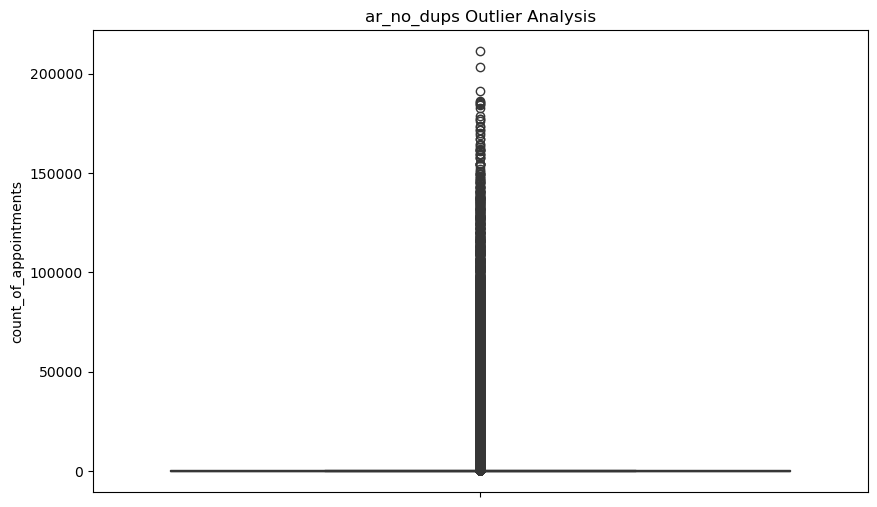

{'Q1': np.float64(8.0),
 'Q3': np.float64(332.0),
 'IQR': np.float64(324.0),
 'lower_bound': np.float64(-478.0),
 'upper_bound': np.float64(818.0),
 'outlier_count': 93641}

In [33]:
# Re-perform outlier analysis on the ar DataFrame and generate a boxplot.
perform_outlier_analysis_and_generate_boxplot(df = ar_no_dups, column_name = "count_of_appointments", palette = "colorblind", 
                                              plot_title = "ar_no_dups Outlier Analysis", prefix = "ar_no_dups Outlier Analysis")

**Observation(s):** The IQR has increased from 301 to 324 and continues to suggest genuine diversity within the dataset. The number of outliers has reduced from 97348 to 93641, which confirms that the presence of fully duplicated rows was exaggerating the number of outliers. However, the number of outliers is still high and represents 16.27% of the dataset (as opposed to 16.31% pre-removal of the fully duplicated rows), which is outside the expected 5-10% range. Despite this, all the outliers will be retained, as they were previously deemed likely to represent legitimate variation in the count of appointments booked, with the caveat that rows with one or more unknown values may represent data quality limitations rather than true variation.

#### Data Transformation (Assignment Activity 3 Questions):

**Question 1:** Between what dates were appointments scheduled? 

In [34]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
print(ad['appointment_date'].head())

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object


In [35]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
print(nc['appointment_date'].head())

0    02/08/2021
1    02/08/2021
2    02/08/2021
3    02/08/2021
4    02/08/2021
Name: appointment_date, dtype: object


**Observation(s):** The date format of the ad dataset's appointment_date column is different to that of the nc dataset's appointment_date column. The formats should be standardised to make the data easier to interpret and work with.

In [36]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DataFrame.
print(ad['appointment_date'].head())

0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns]


In [37]:
# Change the date format of nc['appointment_date'].
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], format='%d/%m/%Y')

# View the DataFrame.
print(nc['appointment_date'].head())

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]


**Observation(s):** Both appointment_date columns are now in the same format, making it easier to see that the ad dataset begins on 1st December 2021 and the nc dataset begins on 2nd August 2021. This is important, because if both datasets were to be used to answer the same analytical question, the range would need to begin from a commonly held date, i.e., 1st December 2021 or later.

In [38]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
""" This identifies the first and last dates on which appointments were booked. """

# Create two new DataFrames to hold the minimum and maximum dates.
ad_min_date = ad['appointment_date'].min()
ad_max_date = ad['appointment_date'].max()

# View the minimum and maximum dates.
print(f"Earliest Appointment Date: {ad_min_date}")
print(f"Latest Appointment Date: {ad_max_date}")

Earliest Appointment Date: 2021-12-01 00:00:00
Latest Appointment Date: 2022-06-30 00:00:00


**Observation(s):** Appointments were booked between 1st December 2021 and 30th June 2022.

In [39]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
""" This identifies the first and last dates on which appointments were booked. """

# Create two new DataFrames to hold the minimum and maximum dates.
nc_min_date = nc['appointment_date'].min()
nc_max_date = nc['appointment_date'].max()

# View the minimum and maximum dates.
print(f"Earliest Appointment Date: {nc_min_date}")
print(f"Latest Appointment Date: {nc_max_date}")

Earliest Appointment Date: 2021-08-01 00:00:00
Latest Appointment Date: 2022-06-30 00:00:00


**Observation(s):** Appointments were booked between 1st August 2021 and 30th June 2022.

**Observation(s):** The ad and nc datasets could be used together to answer analytical questions so long as the data range was set as 1st December 2021 to 30th June 2022.

**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [40]:
# Determine the number of appointments booked at each of the five service settings in NHS North West London between 1st January and 1st June 2022.
nwl_icb_subset = nc[(nc['icb_location_name'] == 'NHS North West London ICB') &
    (nc['appointment_date'] >= '2022-01-01') &
    (nc['appointment_date'] <= '2022-06-01')]

# Group the data by service setting and sum the count of appointments.
nwl_icb_ser_set_appt_counts = nwl_icb_subset.groupby('service_setting')['count_of_appointments'] \
    .sum().reset_index().sort_values('count_of_appointments', ascending=False)

# Calculate the total appointments in NHS North West London and add a percentage column.
nwl_icb_total_appointments = nwl_icb_ser_set_appt_counts['count_of_appointments'].sum()
nwl_icb_ser_set_appt_counts['percentage'] = (nwl_icb_ser_set_appt_counts['count_of_appointments'] / nwl_icb_total_appointments * 100).round(2)

# View the results.
print(nwl_icb_ser_set_appt_counts)

             service_setting  count_of_appointments  percentage
1           General Practice                4804239       86.47
4                   Unmapped                 391106        7.04
2                      Other                 152897        2.75
3       Primary Care Network                 109840        1.98
0  Extended Access Provision                  98159        1.77


**Observation(s):** General Practice was the most popular service setting in NHS North West London between 1st January and 1st June 2022, experiencing 86.47% of the demand for appointments. Extended Access Provision, Primary Care Networks, and 'Other' service settings experienced just 6.50% of the demand for appointments, suggesting that either they had significantly less starting capacity than General Practices or that patients have a strong preference for attending appointments at General Practices (or both).

**Question 3:** Which month had the highest number of appointments?

In [41]:
# Determine the number of appointments booked per month, then sort by highest to lowest appointment count.
# Continue using the nc dataset for consistency within the analysis.
# Use the groupby() and sort_values() functions.
nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index().sort_values('count_of_appointments', ascending=False)

,appointment_month,count_of_appointments
3,2021-11,30405070
2,2021-10,30303834
7,2022-03,29595038
1,2021-09,28522501
9,2022-05,27495508
10,2022-06,25828078
5,2022-01,25635474
6,2022-02,25355260
4,2021-12,25140776
8,2022-04,23913060


**Observation(s):** November 2021 was the month in which the highest number of appointments were booked, which is unsurprising, given demand is expected to rise as the season changes from Autumn to Winter. However, of the 11 months observed, January 2022, February 2022, and December 2021 placed 7th, 8th, and 9th highest for appointment count respectively. This is surprising, as demand is expected to be higher during Winter because seasonal illnesses cause the 'Winter Pressures' phenomenon.

**Question 4:** What was the total number of records per month?

In [42]:
# Calculate the total number of records per month in the ad dataset.
# Convert the appointment dates into appointment months.
ad['appointment_month'] = ad['appointment_date'].dt.to_period('M')

# Use the groupby() function.
ad.groupby('appointment_month').size().reset_index(name="number_of_records")

,appointment_month,number_of_records
0,2021-12,19507
1,2022-01,19643
2,2022-02,18974
3,2022-03,21236
4,2022-04,19078
5,2022-05,20128
6,2022-06,19227


**Observation(s):** Each row represents a different possible 'actual duration', per day, per sub-ICB location. Compared with the national_categories dataset, the number of records is relatively small. This is because only one variable (actual duration) is used to separate the records.

In [43]:
# Calculate the total number of records per month in the ar dataset.
# Use the ar_no_dups dataset to ensure no fully duplicated rows are included.
# Use the groupby() function.
ar_no_dups.groupby('appointment_month').size().reset_index(name="number_of_records")

,appointment_month,number_of_records
0,2020-01,20136
1,2020-02,19901
2,2020-03,20557
3,2020-04,18426
4,2020-05,17584
5,2020-06,18136
6,2020-07,18761
7,2020-08,18517
8,2020-09,19353
9,2020-10,19441


**Observation(s):** Each row represents a different combination of possible 'appointment statuses', 'hcp types', 'appointment modes', and 'times between bookings and appointments', per month, per ICB location. Compared with the national_categories dataset, the number of records is relatively small. This is because there are far fewer possible combinations of categorical variables within the ar dataset than there are in the nc dataset.

In [44]:
# Calculate the total number of records per month in the national categories dataset.
# Use the groupby() function.
nc.groupby('appointment_month').size().reset_index(name="number_of_records")

,appointment_month,number_of_records
0,2021-08,69999
1,2021-09,74922
2,2021-10,74078
3,2021-11,77652
4,2021-12,72651
5,2022-01,71896
6,2022-02,71769
7,2022-03,82822
8,2022-04,70012
9,2022-05,77425


**Observation(s):** Each row represents a different combination of possible 'service settings', 'context types', and 'national categories', per day, per sub-ICB location. Compared with the actual_duration and appointments_regional datasets, the number of records is relatively large. This is because there are far more possible combinations of categorical variables within the nc dataset, mostly caused by the national_categories column having 18 possible values.

#### Data Transformation (Additional Analytical Questions beyond Assignment Activity 3):

##### High-level Business Question 1) Has there been adequate staff and capacity in the networks (primary care services)?

**Question 1:** How many appointments were available each month nationally (capacity)?

In [45]:
# The assignment details inform us that the daily national appointment capacity is 1.2 million.

# Create a DataFrame to store the daily national appointment capacity.
daily_nat_cap = 1200000

# Create a DataFrame to calculate and store the monthly national capacity.
monthly_nat_cap = daily_nat_cap * 30

# View the result.
print(monthly_nat_cap)

36000000


**Observation(s):** There are approximately 36 million appointments available nationally each month. This is an approximation because each month will have either 28, 29, 30, or 31 days in it, but the monthly national capacity calculation assumes each month has 30 days (for simplicity).

**Question 2:** How many appointments were booked each month nationally (demand)?

In [46]:
# Use the nc dataset to determine the number of appointments booked per month.
# Use the groupby() function.
nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776
5,2022-01,25635474
6,2022-02,25355260
7,2022-03,29595038
8,2022-04,23913060
9,2022-05,27495508


**Observation(s):** Each month's count of appointments (demand) is lower than the monthly national capacity of 36 million. This implies that, on a national level at least, the NHS has enough capacity to meet demand. However, this calculation should be repeated with the ar_no_dups dataset to determine whether the same result is observed.

In [47]:
# Determine the number of appointments booked per month.
# Use the ar_no_dups dataset to ensure no fully duplicated rows are included.
# Limit the data range to between August 2021 and June 2022, to ensure consistency with the nc dataset.
# Use the groupby() function.
ar_no_dups[(ar_no_dups['appointment_month'] >= '2021-08') & 
           (ar_no_dups['appointment_month'] <= '2022-06')].groupby('appointment_month')['count_of_appointments'].sum().reset_index()

,appointment_month,count_of_appointments
0,2021-08,23843177
1,2021-09,28514685
2,2021-10,30296850
3,2021-11,30395923
4,2021-12,25132174
5,2022-01,25623928
6,2022-02,25344812
7,2022-03,29586020
8,2022-04,23904960
9,2022-05,27478652


**Observation(s):** The count of appointments per month is largely consistent between the nc and ar_no_dups datasets, so it is deemed appropriate to compare the two datasets. Again, each month's count of appointments (demand) is lower than the monthly national capacity of 36 million, implying that, on a national level at least, the NHS has enough capacity to meet demand. However, aggregating the data by month does not tell us how many days demand was manageable within capacity.

**Question 3:** How often was national daily demand manageable within national capacity?

In [48]:
# Calculate the number of days on which appointments were booked.
nc_num_appt_days = nc['appointment_date'].nunique()

# View the result.
print(f"Number of days on which appointments were booked: {nc_num_appt_days}")

# Group by appointment date and sum all appointments nationally.
daily_nat_dem = nc.groupby('appointment_date')['count_of_appointments'].sum()

# Filter the appointment dates to determine the number of days where national demand was manageable within national capacity.
days_sufficient_nat_cap = daily_nat_dem[daily_nat_dem < daily_nat_cap]

# View the result.
print(f"Number of days with sufficient national capacity to meet demand: {len(days_sufficient_nat_cap)}")

# Calculate the percentage of total days where national demand was manageable within national capacity.
perc_days_sufficient_nat_cap = round((len(days_sufficient_nat_cap) / nc_num_appt_days) * 100, 2)

# View the result.
print(f"Percentage of days with sufficient national capacity to meet demand: {perc_days_sufficient_nat_cap}")

Number of days on which appointments were booked: 334
Number of days with sufficient national capacity to meet demand: 159
Percentage of days with sufficient national capacity to meet demand: 47.6


**Observation(s):** Whilst monthly national demand appeared manageable within monthly national capacity, comparing each day's national demand with it's national capacity (1.2 million appointments) informs us that daily demand was manageable only 47.6% of time. Again, this is an approximation, because some days of the week will have had capacity below 1.2 million, e.g., Sundays, and other days will have had no capacity at all, e.g., Bank Holidays. However, national demand vs. capacity does not necessarily reflect each ICB location’s local demand vs. capacity.

**Question 4:** What were the top five ICB locations by appointment count?

In [49]:
# Determine the top five locations based on appointment count.
nc.groupby("icb_location_name")['count_of_appointments'].sum().nlargest(5)

icb_location_name
NHS North East and North Cumbria ICB    16882235
NHS West Yorkshire ICB                  14358371
NHS Greater Manchester ICB              13857900
NHS Cheshire and Merseyside ICB         13250311
NHS North West London ICB               12142390
Name: count_of_appointments, dtype: int64

**Observation(s):** The two ICBs with the highest number of appointments were both based in the North East and Yorkshire Region. The two ICBs with the third and fourth highest number of appointments were both based in the North West Region. The ICB with the fifth highest number of appointments was based in the London Region.

**Question 5:** What was each ICB's monthly capacity?

In [50]:
# We are not told the proportion of the daily national capacity that each ICB location has locally.
# Therefore, it is assumed that each ICB location has 1/42 of the daily national capacity (an equal share).

# Create a DataFrame to store the daily ICB location appointment capacity.
daily_icb_cap = round(1200000 / 42)

# Create a DataFrame to calculate and store the monthly ICB location appointment capacity.
monthly_icb_cap = round(daily_icb_cap * 30)

# View the result as a whole number.
print(monthly_icb_cap)

857130


**Observation(s):** There are approximately 857130 appointments available per ICB location each month. This is an approximation because each month will have either 28, 29, 30, or 31 days in it, but the monthly ICB capacity calculation assumes each month has 30 days (for simplicity). Attributing an equal share of the total national capacity to each ICB location is not the most robust method of analysis available to us, as each ICB will serve a differently sized population of patients, and will, therefore, have a different amount of capacity to meet local demand. However, each ICB's capacity was not provided to us by the NHS, so in the interests of time and simplicity, an equal share will be applied. It should be noted, however, that future analyses could utilise either commissioning or population size data to more robustly approximate each ICB's capacity.

**Question 6:** How many appointments were booked in the top ICB location by appointment count each month (demand)?

In [51]:
# The top ICB location by appointment amount was NHS North East and North Cumbria ICB.
# Create a subset of the nc dataset to determine the number of appointments booked per month in NHS North East and North Cumbria ICB.
nenc_icb_subset = nc[(nc['icb_location_name'] == 'NHS North East and North Cumbria ICB')]

# Group the data by month and sum the count of appointments.
nenc_icb_monthly_appt_counts = nenc_icb_subset.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# View the results.
nenc_icb_monthly_appt_counts

,appointment_month,count_of_appointments
0,2021-08,1341051
1,2021-09,1653075
2,2021-10,1725403
3,2021-11,1738485
4,2021-12,1437989
5,2022-01,1456780
6,2022-02,1439488
7,2022-03,1679342
8,2022-04,1379494
9,2022-05,1564541


**Observation(s):** Each month's count of appointments (demand) was higher than the monthly ICB capacity of 857130. This implies that, for NHS North East and North Cumbria ICB at least, there was not enough capacity to meet demand. However, aggregating the data by month does not tell us how many days demand was manageable within capacity.

**Question 7:** How often was the top ICB location by appointment count’s demand manageable within its capacity?

In [52]:
# The top ICB location by appointment amount was NHS North East and North Cumbria ICB.
# Calculate the number of days on which appointments were booked.
nenc_num_appt_days = nenc_icb_subset['appointment_date'].nunique()

# View the result.
print(f"Number of days on which appointments were booked: {nenc_num_appt_days}")

# Group by appointment date and sum all appointments in NHS North East and North Cumbria ICB.
daily_nenc_dem = nenc_icb_subset.groupby('appointment_date')['count_of_appointments'].sum()

# Filter the appointment dates to determine the number of days where demand was manageable within NHS North East and North Cumbria ICB's capacity.
days_sufficient_nenc_cap = daily_nenc_dem[daily_nenc_dem < daily_icb_cap]

# View the result.
print(f"Number of days with sufficient capacity in NHS North East and North Cumbria ICB to meet demand: {len(days_sufficient_nenc_cap)}")

# Calculate the percentage of total days where demand was manageable within NHS North East and North Cumbria ICB's capacity.
perc_days_sufficient_nenc_cap = round((len(days_sufficient_nenc_cap) / nenc_num_appt_days) * 100, 2)

# View the result.
print(f"Percentage of days with sufficient capacity in NHS North East and North Cumbria ICB to meet demand: {perc_days_sufficient_nenc_cap}")

Number of days on which appointments were booked: 334
Number of days with sufficient capacity in NHS North East and North Cumbria ICB to meet demand: 104
Percentage of days with sufficient capacity in NHS North East and North Cumbria ICB to meet demand: 31.14


**Observation(s):** Comparing each day's demand in NHS North East and North Cumbria ICB with it's daily capacity (28571 appointments) informs us that daily demand was manageable only 31.14% of time (16.46% lower than the national average). Again, this is an approximation, because some days of the week will have had capacity below 28571, e.g., Sundays, and other days will have had no capacity at all, e.g., Bank Holidays. However, with demand appearing to be manageable less than 1/3 of the time, it seems safe to assume that NHS North East and North Cumbria ICB did not have enough built-in capacity to meet its local demand. This will not have been the case for every ICB location though, so an assessment of each ICB's ability to manage its daily demand within capacity is needed.

**Question 8:** Which ICB locations did not have enough daily capacity to manage their average daily demand (the average of their total demand over time)?

In [53]:
# We are not told the proportion of the daily national capacity that each ICB location has locally.
# Therefore, it is assumed that each ICB location has 1/42 of the daily national capacity (an equal share).
# Calculate the average number of appointments booked per day per ICB location.
avg_daily_icb_dem = nc.groupby("icb_location_name")['count_of_appointments'].sum() / nc_num_appt_days

# Filter the ICB locations to determine which did not have enough daily capacity to manage their average daily demand.
icb_loc_insufficient_cap = avg_daily_icb_dem[avg_daily_icb_dem > daily_icb_cap].index.tolist()

# View the result.
print(f"ICB locations with insufficient daily capacity:")
for location in icb_loc_insufficient_cap:
    print(location)

ICB locations with insufficient daily capacity:
NHS Cheshire and Merseyside ICB
NHS Greater Manchester ICB
NHS North East London ICB
NHS North East and North Cumbria ICB
NHS North West London ICB
NHS West Yorkshire ICB


**Observation(s):** Six of the 42 ICB locations did not have enough daily capacity to manage their average daily demand (one in every seven ICBs). Five of the six ICBs were also the top five ICBs by appointment count (NHS North East London ICB had the sixth highest appointment count). This may suggest that some or all of the other 36 ICBs may have unutilised capacity available to manage the demand that is not being met by these six ICBs.

**Question 9:** How many appointments were booked, month on month, in each of the ICB locations that did not have enough daily capacity to manage their average daily demand?

In [54]:
# List the ICB locations with insufficient capacity.
insufficient_cap_icbs = [
    'NHS Cheshire and Merseyside ICB',
    'NHS Greater Manchester ICB',
    'NHS North East London ICB',
    'NHS North East and North Cumbria ICB',
    'NHS North West London ICB',
    'NHS West Yorkshire ICB'
]

# Filter the nc dataset to include only these ICBs.
insufficient_cap_icb_subset = nc[nc['icb_location_name'].isin(insufficient_cap_icbs)]

# Group by appointment month and icb location, then sum the count of appointments.
insufficient_cap_icbs_monthly_appt_counts = insufficient_cap_icb_subset.groupby(['appointment_month', 'icb_location_name'])['count_of_appointments'] \
    .sum().reset_index()

# Pivot the data so each ICB location has its own column and all the data can be viewed at the same time.
pivot_insufficient_cap_icbs_monthly_appt_counts = insufficient_cap_icbs_monthly_appt_counts \
    .pivot(index='appointment_month', columns='icb_location_name', values='count_of_appointments')

# View the results.
pivot_insufficient_cap_icbs_monthly_appt_counts

icb_location_name,NHS Cheshire and Merseyside ICB,NHS Greater Manchester ICB,NHS North East London ICB,NHS North East and North Cumbria ICB,NHS North West London ICB,NHS West Yorkshire ICB
appointment_month,,,,,,
2021-08,1064804,1096394,777887,1341051,981385,1164839
2021-09,1310834,1337180,932975,1653075,1144590,1356222
2021-10,1379405,1406861,942650,1725403,1180674,1431468
2021-11,1366727,1425077,968353,1738485,1204118,1473951
2021-12,1112173,1170262,798445,1437989,1022195,1269888
2022-01,1146065,1191627,830144,1456780,1050517,1252475
2022-02,1131219,1191581,827045,1439488,1053468,1214320
2022-03,1331604,1412576,965909,1679342,1232596,1430842
2022-04,1062508,1118651,774019,1379494,1006387,1174475


**Observation(s):** NHS North East London ICB appears to have had enough capacity to manage its local demand during five of the 11 observed months (August 2021, December 2021, January 2022, February 2022, and April 2022. None of the other five ICBs appeared to have enough capacity to manage their local demand during any of the 11 observed months. Assuming it is not possible to increase an ICB's local capacity, it would be helpful to determine which of the other 36 ICB locations had unutilised capacity available to meet demand and when, so efforts could be made to try to shift demand to these locations.

**Question 10:** Which ICB locations had unutilised capacity available and in which months to help manage the demand of ICBs with insufficient capacity?

In [55]:
# It is assumed that an ICB would only be able to shift demand to another ICB if they belong to the same NHS Region.
# This is because ICBs within the same Region would be more likely to have established contracting and commissioning relationships.
# It would also be easier to shift demand across a smaller geographic distance if patients were expected to travel, e.g., just over a county line.
# The ICBs locations that need to shift demand are based in the London, North East and Yorkshire, and North West Regions.

# List the ICB locations in the London, North East and Yorkshire, and North West Regions with available capacity.
available_cap_icbs = [
    'NHS North Central London ICB',
    'NHS South East London ICB',
    'NHS South West London ICB',
    'NHS Humber and North Yorkshire ICB',
    'NHS South Yorkshire ICB',
    'NHS Lancashire and South Cumbria ICB'
]

# Filter the nc dataset to include only the ICB locations in the London, North East and Yorkshire, and North West Regions with available capacity.
available_cap_icb_subset = nc[nc['icb_location_name'].isin(available_cap_icbs)]

# Group by appointment month and icb location, then sum the count of appointments.
available_cap_icbs_monthly_appt_counts = available_cap_icb_subset.groupby(['appointment_month', 'icb_location_name'])['count_of_appointments'] \
    .sum().reset_index()

# Filter for months where each ICB had unutilised capacity (count of appointments < 857130).
available_cap_icbs_unutilised_capacity = available_cap_icbs_monthly_appt_counts[available_cap_icbs_monthly_appt_counts['count_of_appointments'] \
    < 857130]

# Pivot the data so each ICB location has its own column and all the data can be viewed at the same time.
pivot_available_cap_icbs_unutilised_capacity = available_cap_icbs_unutilised_capacity \
    .pivot(index='appointment_month', columns='icb_location_name', values='count_of_appointments')

# View the results.
pivot_available_cap_icbs_unutilised_capacity

icb_location_name,NHS Humber and North Yorkshire ICB,NHS Lancashire and South Cumbria ICB,NHS North Central London ICB,NHS South East London ICB,NHS South West London ICB,NHS South Yorkshire ICB
appointment_month,,,,,,
2021-08,741301.0,701143.0,551815.0,643439.0,586988.0,605346.0
2021-09,NaN,NaN,648829.0,753909.0,687200.0,713143.0
2021-10,NaN,NaN,674149.0,805256.0,713981.0,775761.0
2021-11,NaN,NaN,690124.0,807761.0,723453.0,777943.0
2021-12,784363.0,740330.0,566643.0,656619.0,592494.0,650409.0
2022-01,792499.0,758205.0,586319.0,681122.0,620753.0,657482.0
2022-02,784545.0,747012.0,587932.0,673031.0,622835.0,651106.0
2022-03,NaN,NaN,679626.0,779408.0,718995.0,755471.0
2022-04,742852.0,701515.0,540612.0,634790.0,578361.0,614425.0


**Observation(s):** NHS North Central London ICB, NHS South East London ICB, NHS South West London ICB, and NHS South Yorkshire ICB all had unutilised capacity during each of the 11 observed months. NHS Humber and North Yorkshire ICB and NHS Lancashire and South Cumbria ICB both had unutilised capacity during seven of the 11 observed months (August 2021, December 2021, January 2022, February 2022, April 2022, May 2022, and June 2022). This suggests that NHS North East London ICB and NHS North West London ICB could shift some of their demand to the other three ICBs in the London Region all year round. NHS North East and North Cumbria ICB and NHS West Yorkshire ICB could shift some of their demand NHS South Yorkshire ICB all year round and to NHS Humber and North Yorkshire ICB during seven of the 11 observed months. NHS Cheshire and Merseyside ICB and NHS Greater Manchester ICB could shift some of their demand to NHS Lancashire and South Cumbria ICB during seven of the 11 observed months. However, some types of demand would be easier to shift than others.

**Question 11:** Of the ICB locations that did not have enough capacity, how was demand split between appointment modes?

In [56]:
# Show the number of appointments by appointment mode for each ICB location with insufficient capacity.
# Use the ar_no_dups dataset because this includes the appointment_mode column.
# The ar_no_dups DataFrame doesn't have the icb_location_name colummn, so this must be derived from the nc DataFrame.
# Create a mapping dictionary from the nc DataFrame for the icb_ons_code and icb_location_name columns.
# Use drop_duplicates to get unique pairs of icb_ons_code and icb_location_name.
icb_ons_code_and_location_name_mapping = nc[['icb_ons_code', 'icb_location_name']] \
    .drop_duplicates().set_index('icb_ons_code')['icb_location_name'].to_dict()

# Apply the mapping to the ar_no_dups DataFrame.
ar_no_dups['icb_location_name'] = ar_no_dups['icb_ons_code'].map(icb_ons_code_and_location_name_mapping)

# Filter the ar_no_dups dataset to only include the ICBs with insufficient capacity.
ar_insufficient_cap_icb_subset = ar_no_dups[ar_no_dups['icb_location_name'].isin(insufficient_cap_icbs)]

# Group by appointment mode and icb location, then sum the count of appointments.
insufficient_cap_icbs_appt_counts_by_mode = ar_insufficient_cap_icb_subset \
    .groupby(['appointment_mode', 'icb_location_name'])['count_of_appointments'].sum().reset_index()

# Pivot the data so each ICB location has its own column and all the data can be viewed at the same time.
pivot_insufficient_cap_icbs_appt_counts_by_mode = insufficient_cap_icbs_appt_counts_by_mode \
    .pivot(index=['appointment_mode'], columns='icb_location_name', values='count_of_appointments')

# View the results.
pivot_insufficient_cap_icbs_appt_counts_by_mode

icb_location_name,NHS Cheshire and Merseyside ICB,NHS Greater Manchester ICB,NHS North East London ICB,NHS North East and North Cumbria ICB,NHS North West London ICB,NHS West Yorkshire ICB
appointment_mode,,,,,,
Face-to-Face,18548817,18328791,13083807,27540847,16720440,22981972
Home Visit,466241,448518,131708,304467,72832,122044
Telephone,13373030,12362106,10208320,13944722,11363315,11608870
Unknown,578948,2803309,90924,1140979,618918,1119345
Video/Online,97169,61229,79500,123106,605262,242789


**Observation(s):** The most commonly booked appointment mode in each ICB location was face-to-face, followed by telephone. Video/online appointments were the least commonly booked appointment mode in NHS Cheshire and Merseyside ICB, NHS Greater Manchester ICB, NHS North East London ICB, and NHS North East and North Cumbria ICB. Video/online online appointments were the second least commonly booked appointment mode in NHS North West London ICB and NHS West Yorkshire ICB. Of the five different appointment modes, demand for telephone and video/online appointments could be the easiest to shift from one ICB location to another, as all that would be required for this mode of appointment to take place anywhere else in England would be an internet or phone connection, the ability to share patient records between each service setting's IT system, and a data sharing agreement (for information governance purposes). Geography would not be a barrier to attendance (unless a patient was required to attend a face-to-face follow-up appointment at a service setting or receive a home visit, in which case, the next available local appointment could be booked for them.

**Question 12:** Of the ICB locations that did not have enough capacity, how much demand did they experience for telephone and video/online appointments?

In [57]:
# Filter the ar_no_dups dataset to only show appointments for which the appointment modes was either telephone or video/online.
insufficient_cap_icbs_filtered_by_mode = insufficient_cap_icbs_appt_counts_by_mode[insufficient_cap_icbs_appt_counts_by_mode['appointment_mode'] \
    .isin(['Telephone', 'Video/Online'])]

# Pivot the filtered data.
pivot_insufficient_cap_icbs_filtered_by_mode = insufficient_cap_icbs_filtered_by_mode \
    .pivot(index=['appointment_mode'], columns='icb_location_name', values='count_of_appointments')

# View the results.
pivot_insufficient_cap_icbs_filtered_by_mode

icb_location_name,NHS Cheshire and Merseyside ICB,NHS Greater Manchester ICB,NHS North East London ICB,NHS North East and North Cumbria ICB,NHS North West London ICB,NHS West Yorkshire ICB
appointment_mode,,,,,,
Telephone,13373030,12362106,10208320,13944722,11363315,11608870
Video/Online,97169,61229,79500,123106,605262,242789


**Observation(s):** Telephone and video/online appointments could be amalgamated into "remote/virtual" appointments.

In [58]:
# Amalgamate the Telephone and Video/Online appointment counts and rename the mode "Remote/Virtual".
insufficient_cap_icbs_remote_virtual = insufficient_cap_icbs_filtered_by_mode.copy()
insufficient_cap_icbs_remote_virtual['appointment_mode'] = insufficient_cap_icbs_remote_virtual['appointment_mode'].replace(
    {'Telephone': 'Remote/Virtual', 'Video/Online': 'Remote/Virtual'})

# Group by appointment_mode and icb_location_name, then sum the counts.
insufficient_cap_icbs_remote_virtual_appt_counts = insufficient_cap_icbs_remote_virtual \
    .groupby(['appointment_mode', 'icb_location_name'])['count_of_appointments'].sum().reset_index()

# Pivot the data
pivot_insufficient_cap_icbs_remote_virtual = insufficient_cap_icbs_remote_virtual_appt_counts \
    .pivot(index=['appointment_mode'], columns='icb_location_name', values='count_of_appointments')

# View the results
pivot_insufficient_cap_icbs_remote_virtual

icb_location_name,NHS Cheshire and Merseyside ICB,NHS Greater Manchester ICB,NHS North East London ICB,NHS North East and North Cumbria ICB,NHS North West London ICB,NHS West Yorkshire ICB
appointment_mode,,,,,,
Remote/Virtual,13470199,12423335,10287820,14067828,11968577,11851659


**Observation(s):** Each of the six ICB locations with insufficient capacity to manage their local demand experienced demand for between 10 and 15 million remote/virtual appointments over the 11 observed months. some of which could potentially be undertaken by other ICB locations.

**Summary of high-level business question 1:** At the highest level - monthly national demand for appointments - it would appear as though the NHS has enough capacity to manage its demand. However, as more granular analyses are undertaken - daily national demand vs capacity, ICB demand vs capacity, etc. - it becomes apparent that this is an inaccurate assessment. National demand was manageable on fewer than half the observed days (47.6%), and six ICB locations were unable to manage their average daily demand within their existing capacity. However, these six ICBs locations experienced demand for between 10 and 15 million remote/virtual appointments each over the observed 11 month period, some of which could potentially be shifted to neighbouring ICB locations, thus enabling the NHS to make better use of its existing capacity. Further work would be required to determine the volume of appointments that could be shifted between ICBs and the best days/months to do this. Consideration would also need to be given to the appropriateness of shifting particular types of remote/virtual appointments, as some may need to be retained by a local service setting for quality and safety reasons.

##### High-level Business Question 2) What was the actual utilisation of resources?

**Question 1:** What was the total national appointment capacity utilisation (%) for the period August 2021 to June 2022?

In [59]:
# Filter the ar_no_dups DataFrame for the appointment months August 2021 to June 2022.
ar_no_dups_aug21_to_jun22 = ar_no_dups[(ar_no_dups['appointment_month'] >= '2021-08') & (ar_no_dups['appointment_month'] <= '2022-06')]

# Sum the count_of_appointments column.
ar_no_dups_total_appts_aug21_to_jun22 = ar_no_dups_aug21_to_jun22['count_of_appointments'].sum()

# Create a new DataFrame to hold the national capacity utilisation calculation.
# There are 11 months between August 2021 and June 2022, so monthly_nat_cap will be multiplied by 11 to get the total capacity for this period.
nat_cap_utilisation_aug21_to_jun22 = ar_no_dups_total_appts_aug21_to_jun22 / (monthly_nat_cap * 11)

print(f"National appointment capacity utilisation (August 2021 - June 2022): {nat_cap_utilisation_aug21_to_jun22 * 100:.2f}%")

National appointment capacity utilisation (August 2021 - June 2022): 74.73%


**Observation(s):** Over the 11-month period, 74.73% of the NHS's total appointment capacity was utilised (booked). However, aggregating the data by month does not tell us the daily rate of capacity utilisation or how often demand outstripped capacity.

**Question 2:** What was the average daily national appointment capacity utilisation (%) for the period August 2021 to June 2022?

In [60]:
# Calculate the average number of appointments booked per day nationally between August 2021 to June 2022.
# Use the nc_num_appt_days DataFrame for the total number of appointment dates.
avg_daily_nat_dem = ar_no_dups_aug21_to_jun22['count_of_appointments'].sum() / nc_num_appt_days

# Create a new DataFrame to hold the average daily national capacity utilisation calculation.
avg_daily_nat_cap_utilisation_aug21_to_jun22 = avg_daily_nat_dem / daily_nat_cap

# View the result.
print(f"Average daily national appointment capacity utilisation (August 2021 - June 2022): {avg_daily_nat_cap_utilisation_aug21_to_jun22 * 100:.2f}%")

Average daily national appointment capacity utilisation (August 2021 - June 2022): 73.84%


**Observation(s):** Over the 11-month period, the average daily national appointment capacity utilisation was 73.84%. However, national capacity utilisation does not necessarily reflect each ICB location’s capacity utilisation.

**Question 3:** What was NHS North East and North Cumbria ICB's total appointment capacity utilisation (%) for the period August 2021 to June 2022?

In [61]:
# Filter the ar_no_dups DataFrame for the appointment months August 2021 to June 2022 for NHS North East and North Cumbria ICB.
ar_no_dups_aug21_to_jun22_nenc = ar_no_dups[(ar_no_dups['appointment_month'] >= '2021-08') & (ar_no_dups['appointment_month'] <= '2022-06') \
    & (ar_no_dups['icb_location_name'] == 'NHS North East and North Cumbria ICB')]

# Sum the count_of_appointments column.
ar_no_dups_total_appts_aug21_to_jun22_nenc = ar_no_dups_aug21_to_jun22_nenc['count_of_appointments'].sum()

# Create a new DataFrame to hold NHS North East and North Cumbria ICB's capacity utilisation calculation.
# There are 11 months between August 2021 and June 2022, so monthly_icb_cap will be multiplied by 11 to get the total capacity for this period.
nenc_cap_utilisation_aug21_to_jun22 = ar_no_dups_total_appts_aug21_to_jun22_nenc / (monthly_icb_cap * 11)

print(f"NHS North East and North Cumbria ICB's appointment capacity utilisation (August 2021 - June 2022): \
{nenc_cap_utilisation_aug21_to_jun22 * 100:.2f}%")

NHS North East and North Cumbria ICB's appointment capacity utilisation (August 2021 - June 2022): 178.94%


**Observation(s):** Over the 11-month period, NHS North East and North Cumbria ICB's appointment demand outstripped its available capacity by 78.94%, indicating that, for this ICB at least, there was not enough capacity to meet demand. However, aggregating the data by month does not tell us the daily rate of capacity utilisation or how often demand outstripped capacity.

**Question 4:** What was NHS North East and North Cumbria ICB's average daily appointment capacity utilisation (%) for the period August 2021 to June 2022?

In [62]:
# Calculate the average number of appointments booked per day between August 2021 to June 2022 in NHS North East and North Cumbria ICB.
# Use the nc_num_appt_days DataFrame for the total number of appointment dates.
avg_daily_nenc_dem = ar_no_dups_aug21_to_jun22_nenc['count_of_appointments'].sum() / nc_num_appt_days

# Create a new DataFrame to hold the average daily capacity utilisation calculation of NHS North East and North Cumbria ICB.
avg_daily_nenc_cap_utilisation_aug21_to_jun22 = avg_daily_nenc_dem / daily_icb_cap

# View the result.
print(f"NHS North East and North Cumbria ICB's average daily national appointment capacity utilisation (August 2021 - June 2022): \
{avg_daily_nenc_cap_utilisation_aug21_to_jun22 * 100:.2f}%")

NHS North East and North Cumbria ICB's average daily national appointment capacity utilisation (August 2021 - June 2022): 176.79%


**Observation(s):** Over the 11-month period, NHS North East and North Cumbria ICB's average daily appointment demand outstripped its available capacity by 76.79%, which further indicates that , for this ICB at least, there was not enough capacity to meet demand. However, strengthen our understanding of resource utilisation, it would be helpful to know the proportion of booked appointments that were actually attended by patients.

**Question 5:** What proportions of the total national appointment demand between August 2021 and June 2022 were attended, booked, or status unknown?

In [63]:
# Group the ar_no_dups_aug21_to_jun22 DataFrame by appointment_status and sum the count of appointments.
ar_no_dups_aug21_to_jun22_statuses = ar_no_dups_aug21_to_jun22.groupby('appointment_status')['count_of_appointments'].sum().reset_index()

# Add a percentage column to the ar_no_dups_aug21_to_jun22_statuses DataFrame.
ar_no_dups_aug21_to_jun22_statuses['percentage'] = (ar_no_dups_aug21_to_jun22_statuses['count_of_appointments'] / \
                                                    ar_no_dups_total_appts_aug21_to_jun22 * 100).round(2)

ar_no_dups_aug21_to_jun22_statuses

,appointment_status,count_of_appointments,percentage
0,Attended,270617423,91.44
1,DNA,13285796,4.49
2,Unknown,12037388,4.07


**Observation(s):** Over the 11-month period, at least 4.49% of all booked appointments were classed as DNAs (the patients did not attend, but also did not cancel). The percentage could have been as high as 8.56% (if all the appointments with unknown statuses were in fact DNAs). This indicates that approximately one in every 22 booked appointments actually went unutilised (wasted capacity). Reducing DNA rates is a universal priority for health services, as doing this helps free-up resources helps them to manage demand more effectively. It would be helpful to determine NHS North East and North Cumbria ICB's DNA rate and to compare this with national rate.

**Question 6:** What proportions of NHS North East and North Cumbria ICB's total appointment demand between August 2021 and June 2022 were attended, booked, or status unknown?

In [64]:
# Group the ar_no_dups_aug21_to_jun22_nenc DataFrame by appointment_status and sum the count of appointments.
ar_no_dups_aug21_to_jun22_nenc_statuses = ar_no_dups_aug21_to_jun22_nenc.groupby('appointment_status')['count_of_appointments'].sum().reset_index()

# Add a percentage column to the ar_no_dups_aug21_to_jun22_nenc_statuses DataFrame.
ar_no_dups_aug21_to_jun22_nenc_statuses['percentage'] = (ar_no_dups_aug21_to_jun22_nenc_statuses['count_of_appointments'] / \
                                                    ar_no_dups_total_appts_aug21_to_jun22_nenc * 100).round(2)

# View the output.
ar_no_dups_aug21_to_jun22_nenc_statuses

,appointment_status,count_of_appointments,percentage
0,Attended,15498465,91.87
1,DNA,724157,4.29
2,Unknown,648148,3.84


**Observation(s):** Over the 11-month period, at least 4.29% of all booked appointments in NHS North East and North Cumbria ICB were classed as DNAs. The percentage could have been as high as 8.13% (if all the appointments with unknown statuses were in fact DNAs). This broadly reflects the national average and indicates that approximately one in every 23 booked appointments actually went unutilised (wasted capacity). It would be helpful to determine which appointment mode had the highest DNA rate in NHS North East and North Cumbria ICB.

**Question 7:** What was NHS North East and North Cumbria ICB's DNA rate per appointment mode between August 2021 and June 2022?

In [65]:
# Calculate the total number of appointments per appointment mode.
ar_no_dups_aug21_to_jun22_appt_mode_totals = ar_no_dups_aug21_to_jun22_nenc \
    .groupby('appointment_mode')['count_of_appointments'].sum().reset_index()

# Add the appointment mode and appt mode totals columns to the ar_no_dups_aug21_to_jun22_appt_mode_totals DataFrame.
ar_no_dups_aug21_to_jun22_appt_mode_totals.columns = ['appointment_mode', 'appt_mode_totals']

# Sum the DNA counts by appointment mode.
ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_mode = ar_no_dups_aug21_to_jun22_nenc[ar_no_dups_aug21_to_jun22_nenc['appointment_status'] == 'DNA'] \
    .groupby('appointment_mode')['count_of_appointments'].sum().reset_index()

# Add the appointment mode and dna_count columns to the ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_mode DataFrame.
ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_mode.columns = ['appointment_mode', 'dna_count']

# Merge the ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode DataFrame with the DNA counts by appointment mode.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode = ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_mode \
    .merge(ar_no_dups_aug21_to_jun22_appt_mode_totals, on='appointment_mode')

# Calculate the DNA rate per appointment mode.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode['dna_rate'] = (ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode['dna_count'] / \
                                                                ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode['appt_mode_totals'] * 100).round(2)

# Reorder the columns within the ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode DataFrame.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode = ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode \
    [['appointment_mode', 'appt_mode_totals', 'dna_count', 'dna_rate']]

# View results.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode

,appointment_mode,appt_mode_totals,dna_count,dna_rate
0,Face-to-Face,11327961,609528,5.38
1,Home Visit,123916,4061,3.28
2,Telephone,4894010,92769,1.90
3,Unknown,481089,15623,3.25
4,Video/Online,43794,2176,4.97


**Observation(s):** Over the 11-month period, NHS North East and North Cumbria ICB experienced DNA rates of at least 5.38% for face-to-face appointments, 4.97% for video/online appointments, 3.28% for home visits, and 1.90% for telephone appointments. It would be helpful to determine the proportion of appointments booked via these modes that were classed as DNAs each month, to confirm whether these figures are representative all year round.

**Question 8:** What was NHS North East and North Cumbria ICB's DNA rates for face-to-face and video/online appointments, month on month, between August 2021 and June 2022?

In [66]:
# Filter the ar_no_dups_aug21_to_jun22_nenc DataFrame for face-to-face and video/online appointment modes only.
ar_no_dups_aug21_to_jun22_nenc_f2f_and_vo_appts = ar_no_dups_aug21_to_jun22_nenc[ar_no_dups_aug21_to_jun22_nenc['appointment_mode'] \
    .isin(['Face-to-Face', 'Home Visit', 'Telephone', 'Video/Online'])]

# Calculate the total number of appointments per appointment mode and appointment month.
ar_no_dups_aug21_to_jun22_nenc_appt_mode_monthly_totals = ar_no_dups_aug21_to_jun22_nenc_f2f_and_vo_appts \
    .groupby(['appointment_mode', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Add the appointment mode, appointment month, and appt mode month totals columns to the
# ar_no_dups_aug21_to_jun22_nenc_appt_mode_monthly_totals DataFrame.
ar_no_dups_aug21_to_jun22_nenc_appt_mode_monthly_totals.columns = ['appointment_mode', 'appointment_month', 'appt_mode_month_totals']

# Filter the ar_no_dups_aug21_to_jun22_nenc_f2f_and_vo_appts DataFrame for DNAs only.
ar_no_dups_aug21_to_jun22_nenc_dnas = ar_no_dups_aug21_to_jun22_nenc_f2f_and_vo_appts[ar_no_dups_aug21_to_jun22_nenc_f2f_and_vo_appts \
    ['appointment_status'] == 'DNA']

# Sum the DNA counts by appointment mode and appointment month.
ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_month_and_mode = ar_no_dups_aug21_to_jun22_nenc_dnas \
    .groupby(['appointment_mode', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Add the appointment mode, appointment month, and DNA count columns to the ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_month_and_mode DataFrame.
ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_month_and_mode.columns = ['appointment_mode', 'appointment_month', 'dna_count']

# Merge the DNA counts with the total appointment counts.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_month_and_mode = ar_no_dups_aug21_to_jun22_nenc_dna_counts_by_month_and_mode \
    .merge(ar_no_dups_aug21_to_jun22_nenc_appt_mode_monthly_totals, on=['appointment_mode', 'appointment_month'])

# Calculate the DNA rate per appointment mode, per appointment month.
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_month_and_mode['dna_rate'] = (ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_month_and_mode['dna_count'] / \
                                            ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_month_and_mode['appt_mode_month_totals'] * 100).round(2)

# Pivot the aggregated data.
pivot_ar_no_dups_aug21_to_jun22_nenc_dnas = ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_month_and_mode \
    .pivot(index='appointment_month', columns='appointment_mode', values='dna_rate')

# Rename the appointment mode column header to DNA rate (%).
pivot_ar_no_dups_aug21_to_jun22_nenc_dnas.columns.name = 'dna_rate (%)'

# View the results.
pivot_ar_no_dups_aug21_to_jun22_nenc_dnas

dna_rate (%),Face-to-Face,Home Visit,Telephone,Video/Online
appointment_month,,,,
2021-08,4.81,3.08,1.85,4.98
2021-09,5.24,2.16,1.78,4.02
2021-10,5.97,1.91,1.82,3.78
2021-11,5.40,2.51,1.80,4.90
2021-12,5.93,3.61,1.87,6.22
2022-01,5.29,3.55,1.77,4.93
2022-02,5.14,3.79,1.85,5.45
2022-03,5.31,4.15,1.96,5.82
2022-04,5.32,3.46,2.04,4.96


**Observation(s):** Over the 11-month period, the lowest monthly DNA rates that the NHS North East and North Cumbria ICB experienced were 4.81% DNAs for face-to-face appointments (August 2021), 1.91% DNAs for home visits (October 2021), 1.77% DNAs for telephone appointments (January 2022), and 3.78% DNAs for video/online appointments (October 2021). In round numbers, this means that a minimum of one in every 20 face-to-face appointments was not attended, one in every 52 home visits were not attended, one in every 56 telephone appointments were not attended, and one in every 26 video/online appointments were not attended. The ICB could benefit from either trying to reduce the DNA rates **OR** by accepting that the DNA rates are likely to persist, and instead, deliberately overbook some appointments by small number on the assumption that all patients who attend will be seen, because some patients will inevitably choose not to attend.

**Summary of high-level business question 2:** At the highest level - national capacity utilisation - it would appear as though only 75% of the NHS's capacity was utilised over the observed 11-month period. However, the more granular analysis of NHS North East and North Cumbria ICB's capacity utilisation informs us that, for this ICB, at least, demand outstripped capacity by 79%. This suggests that significant variation in capacity utilisaton is likely be observed between the 42 ICBs. The national DNA rate over the observed 11-month period was 4.49%, with NHS North East and North Cumbria ICB experiencing a comparable rate of 4.29%. When segmenting this ICB's DNA rate by appointment mode and month, we can see that a minimum of 4.81% of all face-to-face appointments were not attended, meaning approximately one in every 20 were wasted. Meanwhile, a minimum of 3.78% of video/online appointments were not attended, meaning approximately one in every 26 were wasted. Therefore, the ICB might consider undertaking a pilot study of implementing an overbooking policy, specifically for face-to-face appointments and video/online appointments, whereby they deliberately overbook their appointments by 4.81% and 3.78% respectively, on the assumption that all patients who attend will be seen, because some patients will inevitably choose not to attend. Before implementing such a policy, further work would be required to determine whether overbooking appointments based on monthly DNA rates is clinically safe. This is because daily DNA rates are likely to differ from monthly rates, meaning to overbook appointments every day of the month by a set amount could sometimes lead to all patients attending but not all patients being seen, due to a lack of time available. One way to reduce the likelihood of this happening could be to round down the percentages by which appointments are overbooked, e.g., to 4% for face-to-face appointments and to 3% for video/online appointments.

# Data Visualisation (inc. Assignment Activity 4)

#### Assignment Activity 4 Visualisations:

In [67]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

##### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [68]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype(str)

In [69]:
# Aggregate on monthly level and determine the sum of records per month.
nc_appts_per_month = nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# View output.
nc_appts_per_month

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776
5,2022-01,25635474
6,2022-02,25355260
7,2022-03,29595038
8,2022-04,23913060
9,2022-05,27495508


**Service settings:**

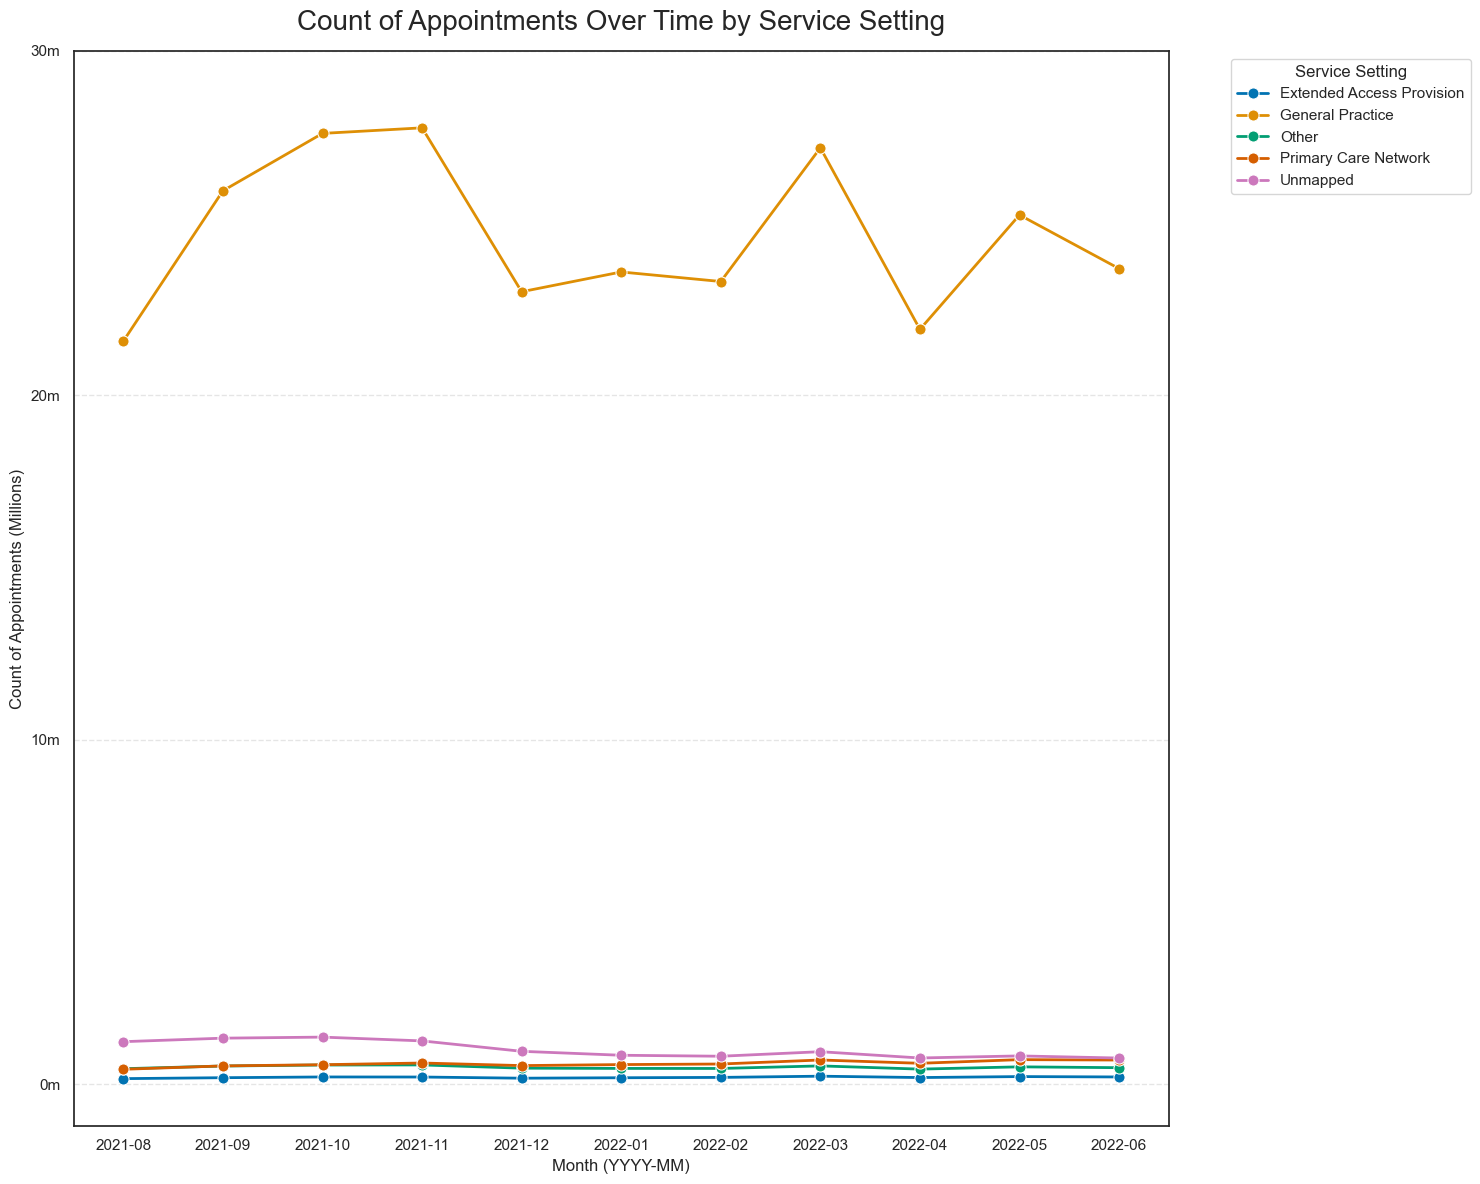

In [70]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.

nc_appts_per_month_ss = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_month_ss, errorbar=None,
            linewidth=2, marker='o', markersize=8)

# Add an informative title.
plt.title('Count of Appointments Over Time by Service Setting', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments (Millions)', fontsize=12)

# Set custom y-axis tick labels
plt.yticks([0, 1e7, 2e7, 3e7], ['0m', '10m', '20m', '30m'])

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Context types:**

In [71]:
# Create a separate data set that can be used in future weeks. 
nc_appts_per_month_ct = nc.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index()

# View output.
nc_appts_per_month_ct

,appointment_month,context_type,count_of_appointments
0,2021-08,Care Related Encounter,20255235
1,2021-08,Inconsistent Mapping,2363093
2,2021-08,Unmapped,1233843
3,2021-09,Care Related Encounter,24404251
4,2021-09,Inconsistent Mapping,2782135
5,2021-09,Unmapped,1336115
6,2021-10,Care Related Encounter,26125201
7,2021-10,Inconsistent Mapping,2811977
8,2021-10,Unmapped,1366656
9,2021-11,Care Related Encounter,26282778


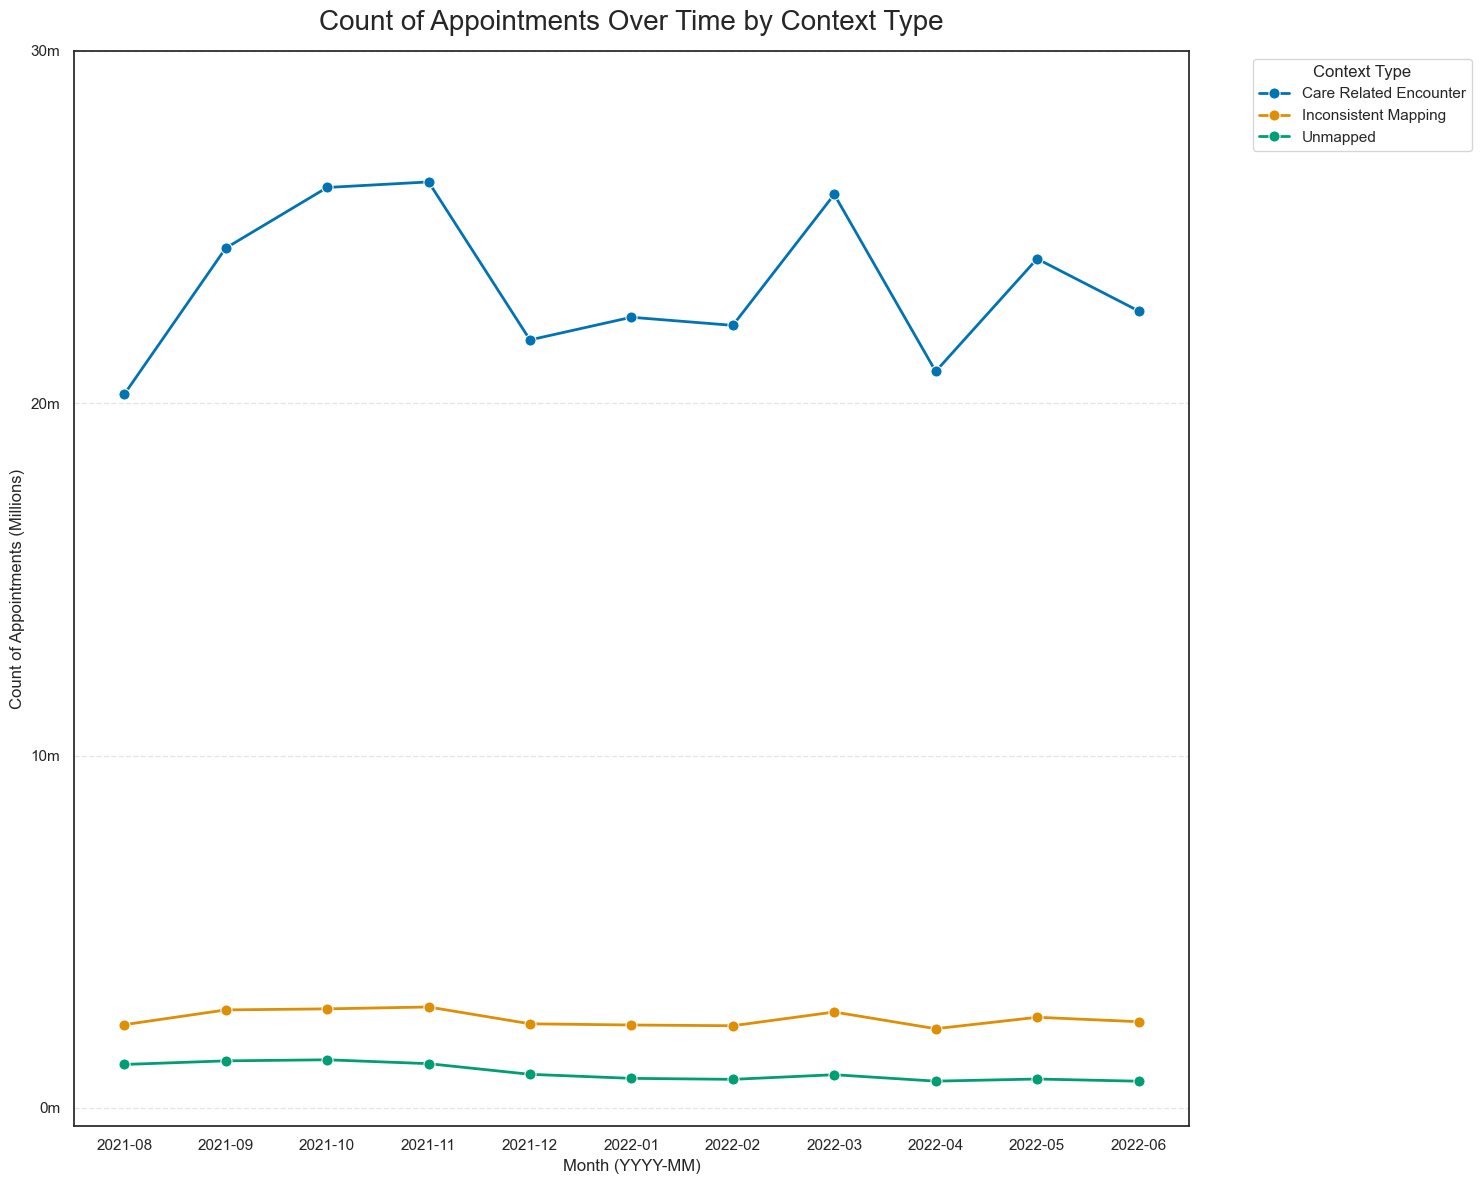

In [72]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.

sns.lineplot(x='appointment_month', y='count_of_appointments', hue='context_type', palette='colorblind', data=nc_appts_per_month_ct, errorbar=None, 
             linewidth=2, marker='o', markersize=8)

# Add an informative title.
plt.title('Count of Appointments Over Time by Context Type', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments (Millions)', fontsize=12)

# Set custom y-axis tick labels
plt.yticks([0, 1e7, 2e7, 3e7], ['0m', '10m', '20m', '30m'])

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Context Type')

plt.tight_layout()
plt.show()

**National categories:**

In [73]:
# Create a separate data set that can be used in future weeks. 
nc_appts_per_month_nc = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

# View output.
nc_appts_per_month_nc

,appointment_month,national_category,count_of_appointments
0,2021-08,Care Home Needs Assessment & Personalised Care...,29676
1,2021-08,Care Home Visit,47583
2,2021-08,Clinical Triage,3704207
3,2021-08,General Consultation Acute,4280920
4,2021-08,General Consultation Routine,7756045
...,...,...,...
193,2022-06,Social Prescribing Service,55066
194,2022-06,Structured Medication Review,187800
195,2022-06,Unmapped,758640
196,2022-06,Unplanned Clinical Activity,274491


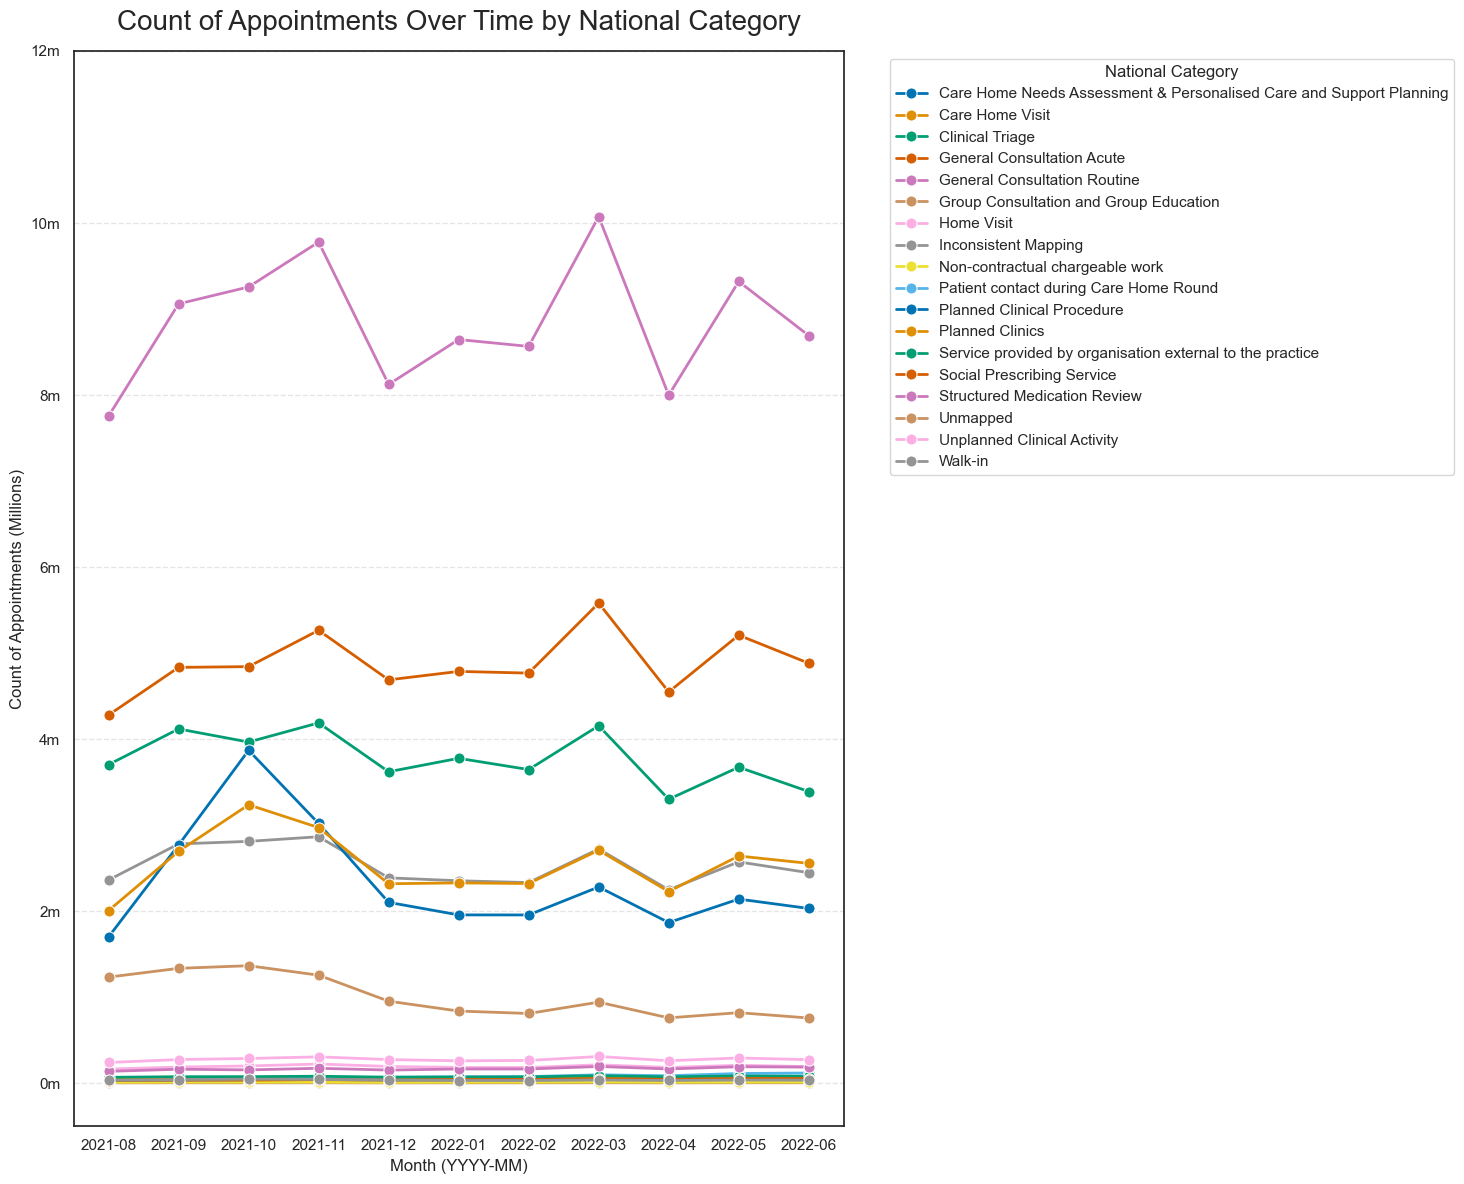

In [74]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='national_category', palette='colorblind', data=nc_appts_per_month_nc, errorbar=None,
            linewidth=2, marker='o', markersize=8)

# Add an informative title.
plt.title('Count of Appointments Over Time by National Category', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments (Millions)', fontsize=12)

# Set custom y-axis tick labels
plt.yticks([0, 2e6, 4e6, 6e6, 8e6, 1e7, 12e6], ['0m', '2m', '4m', '6m', '8m', '10m', '12m'])

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='National Category')

plt.tight_layout()
plt.show()

##### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [75]:
# Create a separate data set that can be used in future weeks. 
nc_appts_per_ss = nc.groupby(['appointment_date', 'appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View output.
nc_appts_per_ss

,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08,Extended Access Provision,438
1,2021-08-01,2021-08,General Practice,3411
2,2021-08-01,2021-08,Other,401
3,2021-08-01,2021-08,Primary Care Network,323
4,2021-08-01,2021-08,Unmapped,1054
...,...,...,...,...
1665,2022-06-30,2022-06,Extended Access Provision,9163
1666,2022-06-30,2022-06,General Practice,1124374
1667,2022-06-30,2022-06,Other,23115
1668,2022-06-30,2022-06,Primary Care Network,34774


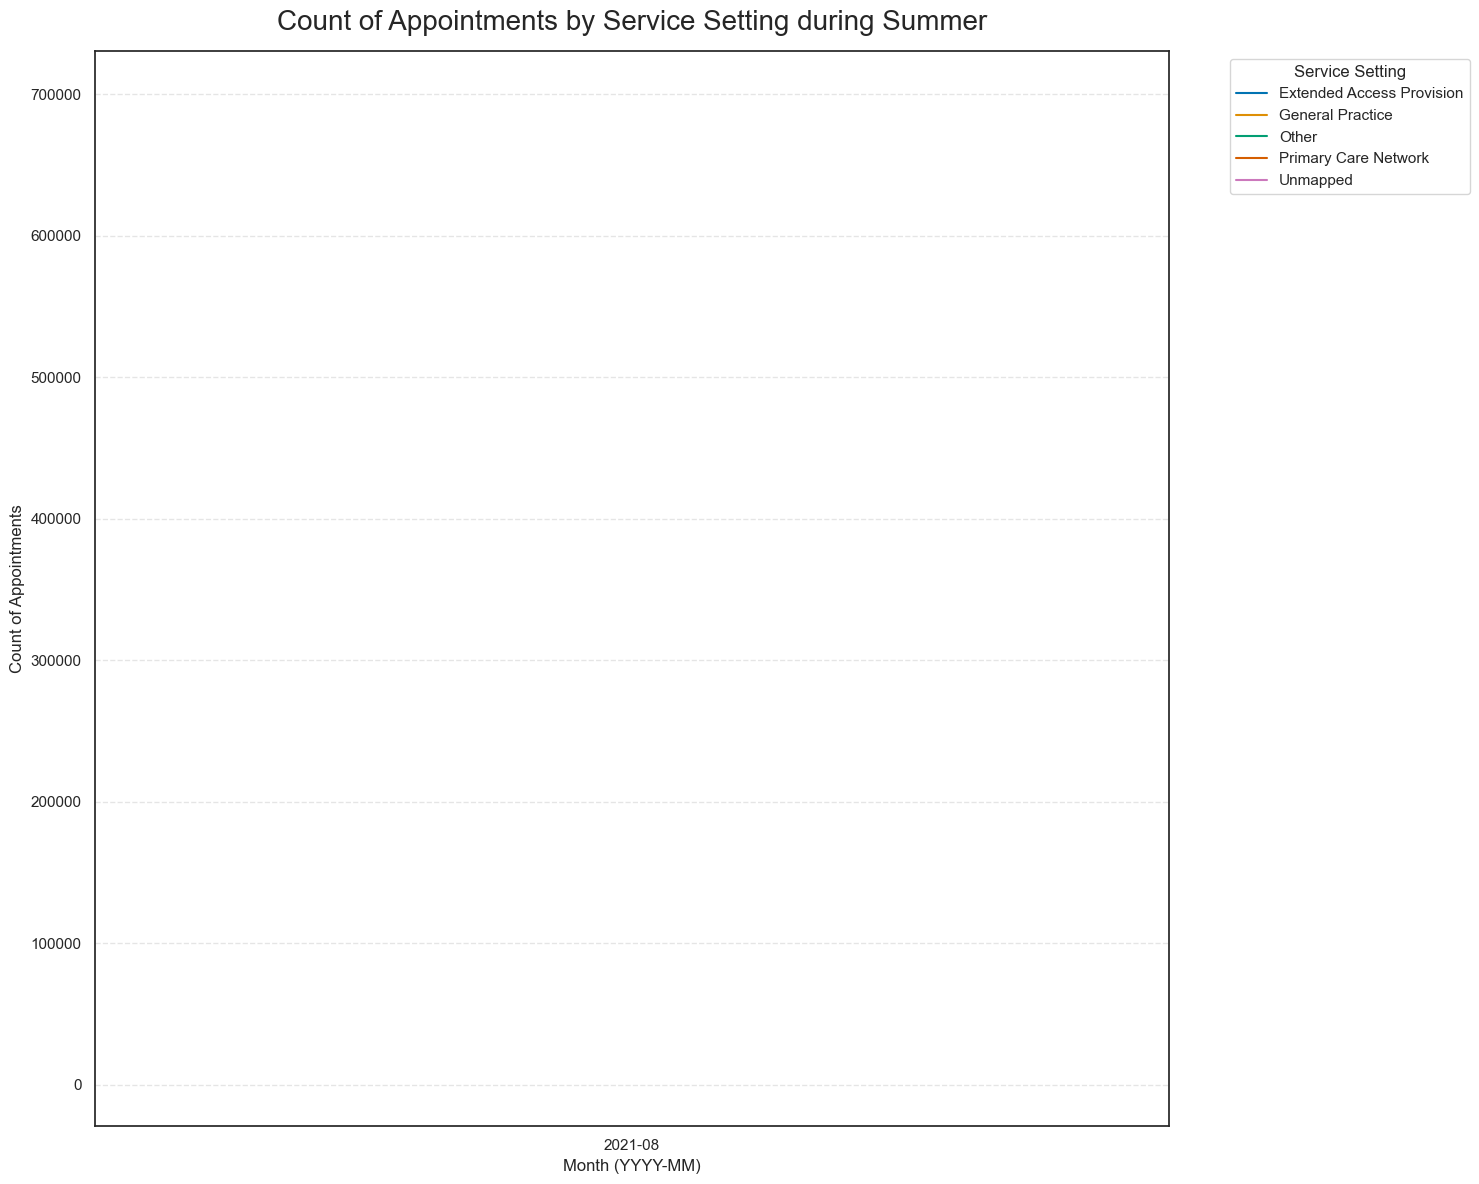

In [76]:
# Look at June to August 2021 in more detail to allow a closer look.
nc_appts_per_ss_summer = nc_appts_per_ss[nc_appts_per_ss['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]

# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_ss_summer, errorbar=None)

# Add an informative title.
plt.title('Count of Appointments by Service Setting during Summer', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Autumn (September to November 2021):**

**Observation:** The line plot is empty. The x-axis label shows only one month - August 2021 - which implies that no appointments took place during June or July 2021.

In [77]:
# Check the minimum and maximum appointment dates within the filtered data.
print(nc_appts_per_ss_summer['appointment_date'].min())
print(nc_appts_per_ss_summer['appointment_date'].max())

2021-08-01 00:00:00
2021-08-31 00:00:00


**Observation:** The earliest appointment date was 1st August and the latest was 31st August. This confirms that appointments only took place in one of the three summer months. It is, therefore, not possible to plot the data on a lineplot.

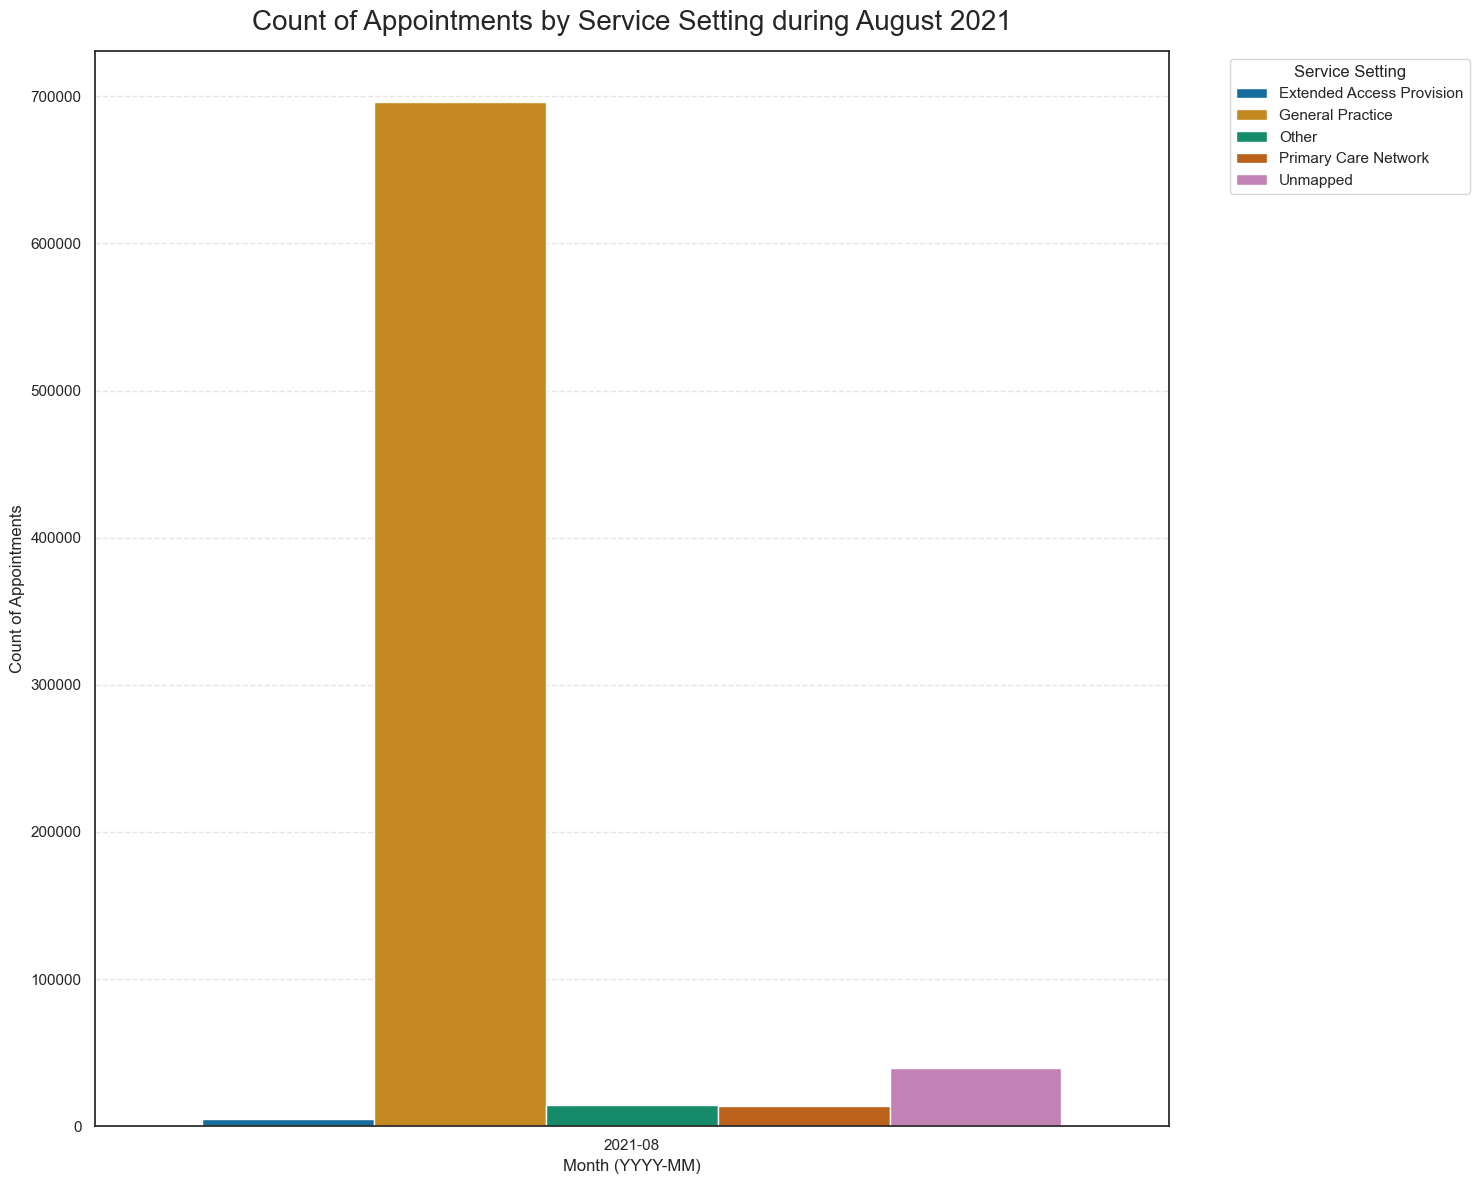

In [78]:
# Look at June to August 2021 in more detail to allow a closer look.
nc_appts_per_ss_summer = nc_appts_per_ss[nc_appts_per_ss['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]

# Create a barplot.
sns.barplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_ss_summer, errorbar=None)

# Add an informative title.
plt.title('Count of Appointments by Service Setting during August 2021', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Observation:** The barplot indicates that the vast majority of appointments (approx. 700k) were booked with General Practice during August 2021, with the remainder (approx. 50k) split between Extended Access Provision, Primary Care Networks, "Other" service settings, and "Unmapped" service settings.

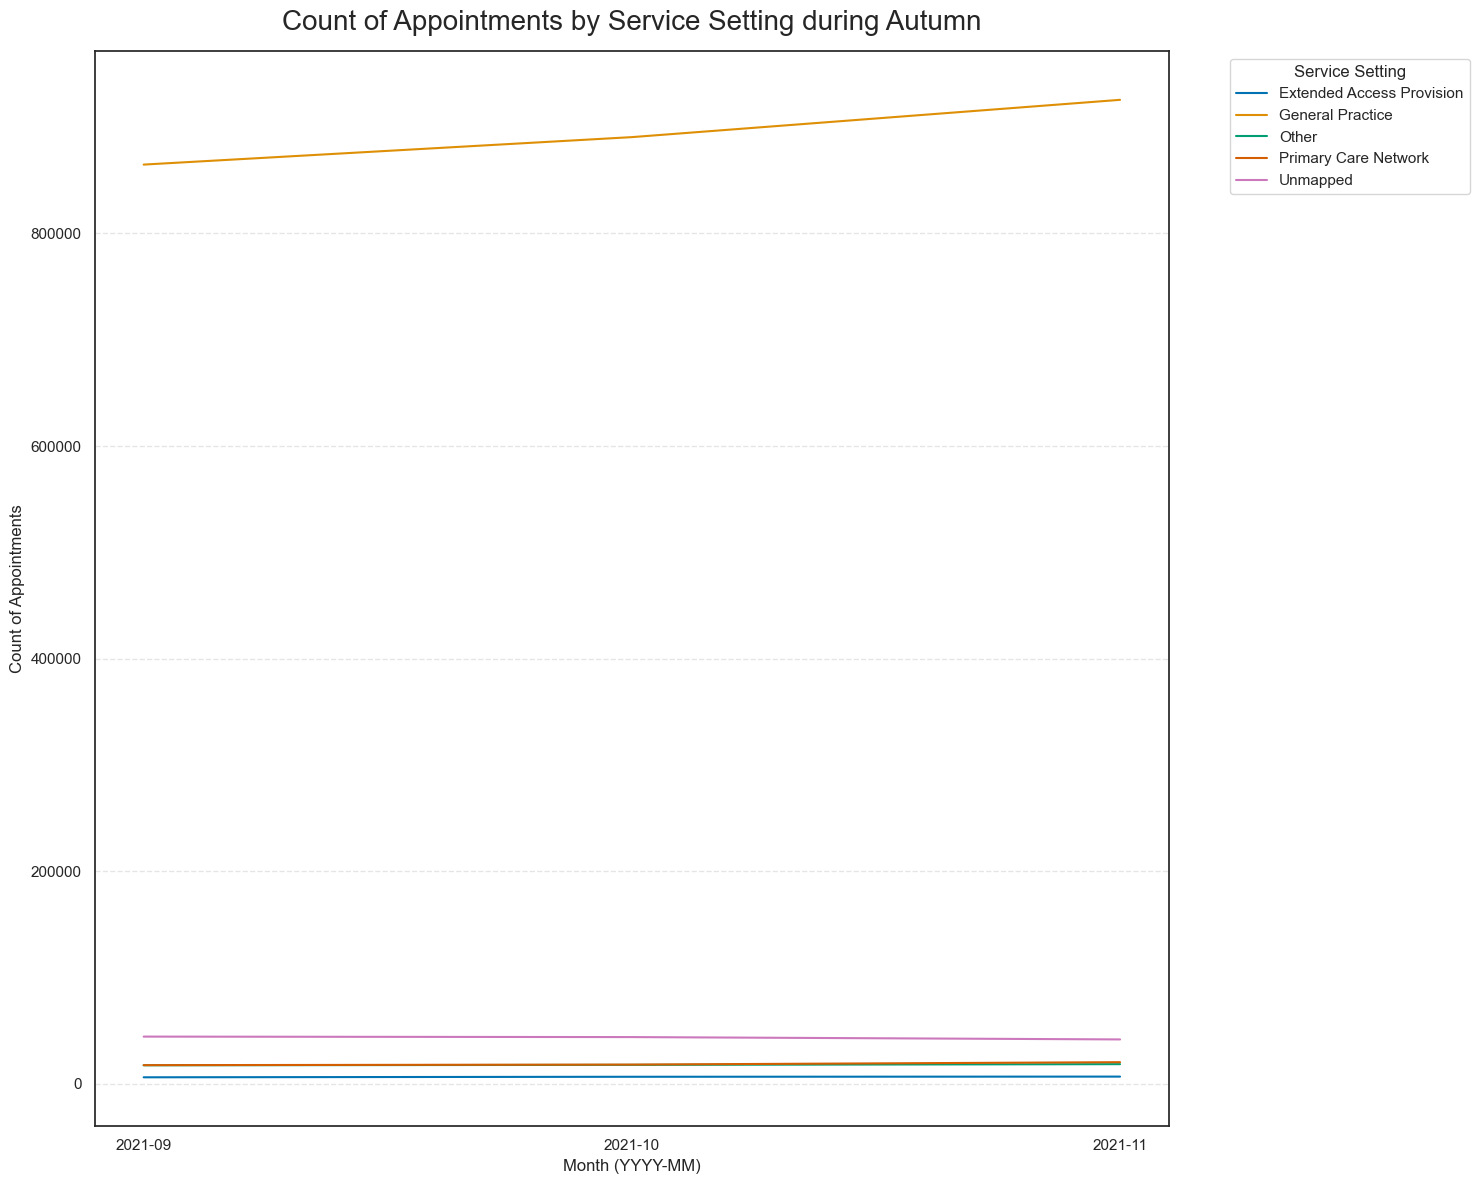

In [79]:
# Look at September to November 2021 in more detail to allow a closer look.
nc_appts_per_ss_autumn = nc_appts_per_ss[nc_appts_per_ss['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]

# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_ss_autumn, errorbar=None)

# Add an informative title.
plt.title('Count of Appointments by Service Setting during Autumn', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Observation:** The pattern of General Practice experiencing the highest appointment demand continued from August to November 2021, with all other service settings continuing to experience much lower demand over this period. The trend was for monthly general practice appointment demand to rise from approx. 700k in August to approx. 950k in November, with demand in all other service settings being (nearly) static between September and November.

**Winter (December to February 2022):**

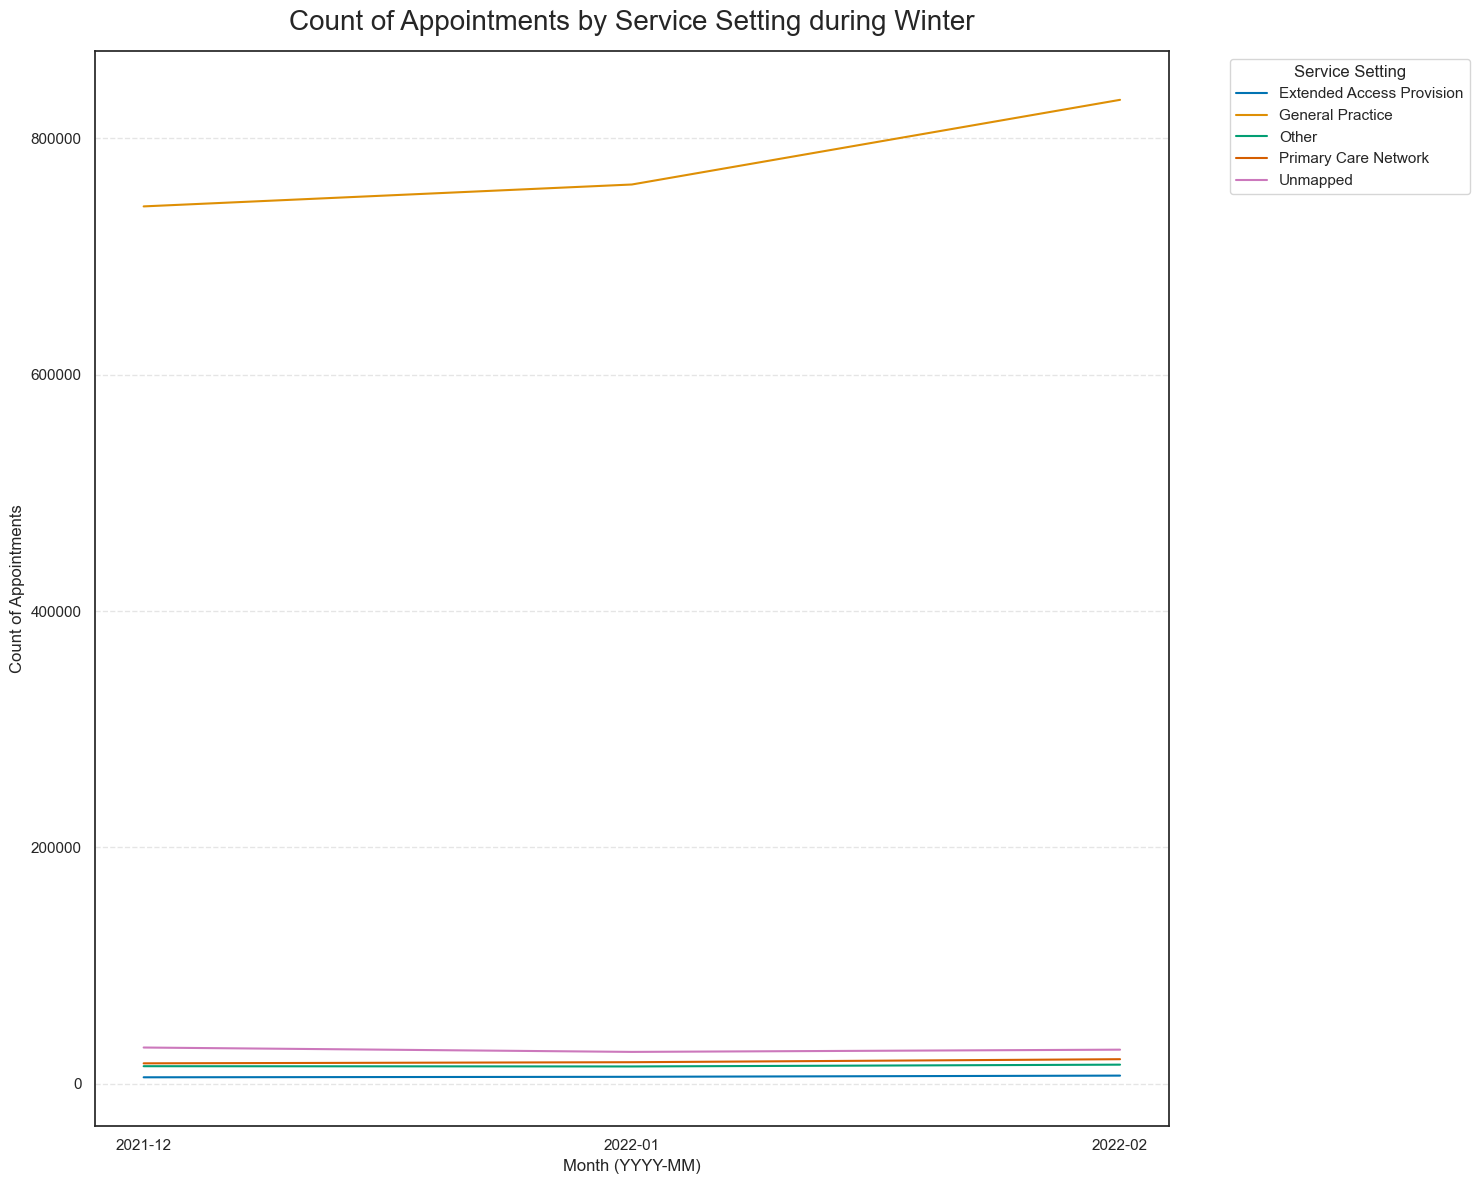

In [80]:
# Look at December to February 2022 in more detail to allow a closer look.
nc_appts_per_ss_winter = nc_appts_per_ss[nc_appts_per_ss['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]

# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_ss_winter, errorbar=None)

# Add an informative title.
plt.title('Count of Appointments by Service Setting during Winter', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Observation:** The pattern of General Practice experiencing the highest appointment demand continued from November 2021 to February 2022, with all other service settings continuing to experience much lower demand over this period. The trend for monthly general practice appointment demand was interrupted between November and December, with monthly demand falling from approx. 950k to 750k. This seems unusual, as the expectation would have been for appointment demand to continue rising to reflect the change from Autumn to Winter and the beginning of NHS 'winter pressures'. It's possible that this decrease in demand was the result of data reporting issues and/or unseasonably low sickness rates. However, this trend then reversed between December and February, with monthly demand rising from approx. 750k to 825k. Demand in all other service settings was (nearly) static between December and February.

**Spring (March to May 2022):**

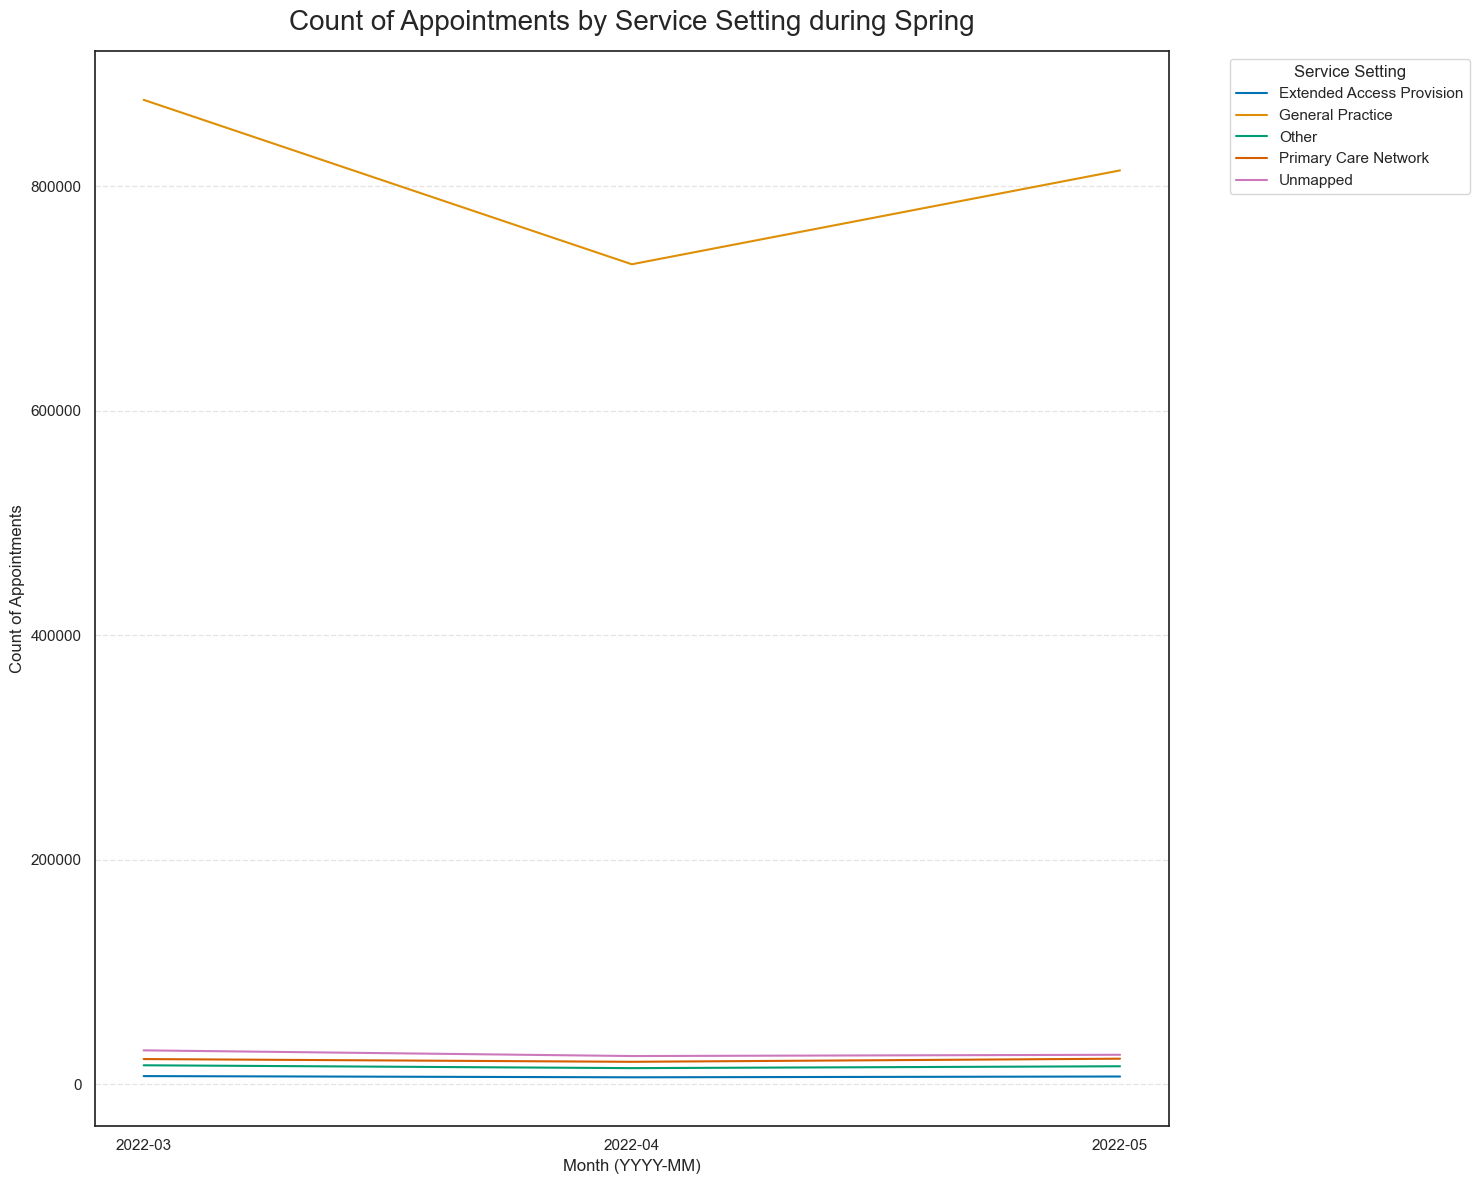

In [81]:
# Look at March to May 2022 in more detail to allow a closer look.
nc_appts_per_ss_spring = nc_appts_per_ss[nc_appts_per_ss['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', palette='colorblind', data=nc_appts_per_ss_spring, errorbar=None)

# Add an informative title.
plt.title('Count of Appointments by Service Setting during Spring', fontsize=20, pad=15)

# Rename the axes.
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)

# Add grid for easier reading
plt.grid(axis='y', alpha=0.5, linestyle='--')

# Move legend to the right and add a title to it.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')

plt.tight_layout()
plt.show()

**Observation:** The pattern of General Practice experiencing the highest appointment demand continued from February to May 2022, with all other service settings continuing to experience much lower demand over this period. The trend was for monthly general practice appointment demand to rise from approx. 825k in February to 860k in March, but was then interrupted between March and April, with monthly demand falling from approx. 860k to 720k. However, this trend then reversed again between April and May, with monthly demand rising from approx. 720k to 810k. Demand in all other service settings was (nearly) static between March and May.

**Observation:** The pattern of General Practice experiencing the highest appointment demand was observed over the whole period August 2021 to May 2022, with all other service settings experiencing much lower demand over this period. The trend for General Practice to experience higher appointment demand month-on-month was sustained between August and November 2021, but then interrupted and fluctuating between November 2021 and May 2022. The trend for all other service settings experiencing (nearly) static demand month-on-month was observed over the whole period August to May. It's possible that General Practice consistently experienced the highest appointment demand because it had the greatest starting capacity of all primary care services within the system. It's also possible that demand was highest in General Practice because patients preferred to attend appointments in traditional general practice settings, compared with relatively newer settings like Primary Care Networks. It's also possible that both these phenomena were true.

#### Visualisations relating to the Additional Analytical Questions:

##### High-level Business Question 1) Has there been adequate staff and capacity in the networks (primary care services)?

**Question 2:** How many appointments were booked each month nationally (demand)?

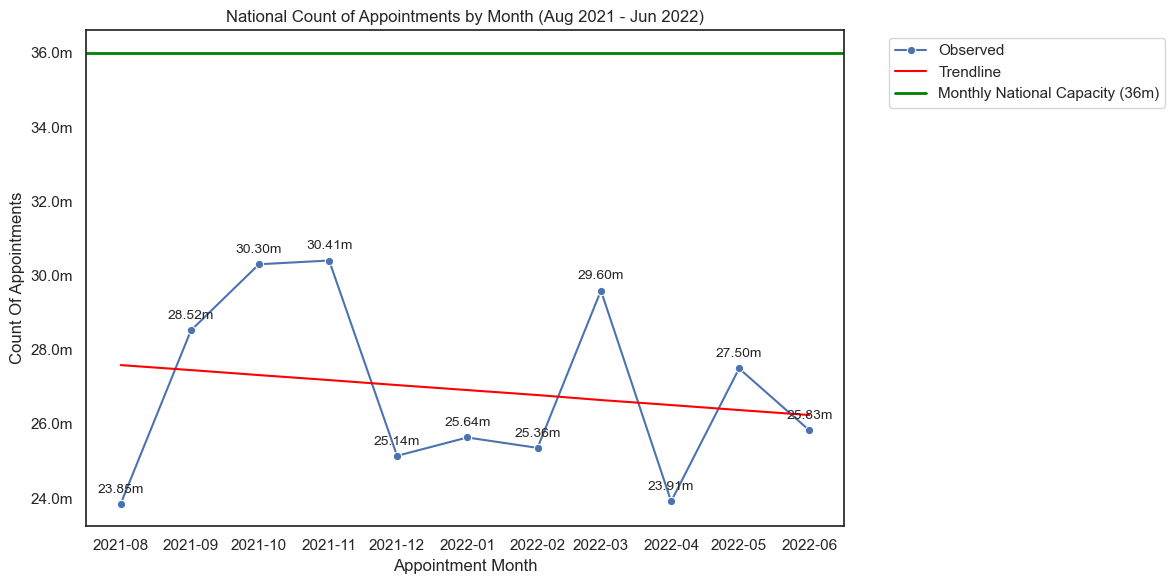

In [82]:
# Aggregate the data in the nc DataFrame.
nc_agg = nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Call the generate_time_series_plot function.
generate_time_series_plot(df = nc_agg, time_col = "appointment_month", value_col = "count_of_appointments", 
                                         plot_title = "National Count of Appointments by Month (Aug 2021 - Jun 2022)", palette = "colorblind", 
                                         reference_line = 36000000, ref_line_label = "Monthly National Capacity (36m)", 
                                         prefix = "National Count of Appointments", y_axis_format = "millions", show_trendline = True)

**Exploratory Visualisation** showing the national count of appointments per month over time between August 2021 and June 2022.

**Question 3:** How often was national daily demand manageable within national capacity?

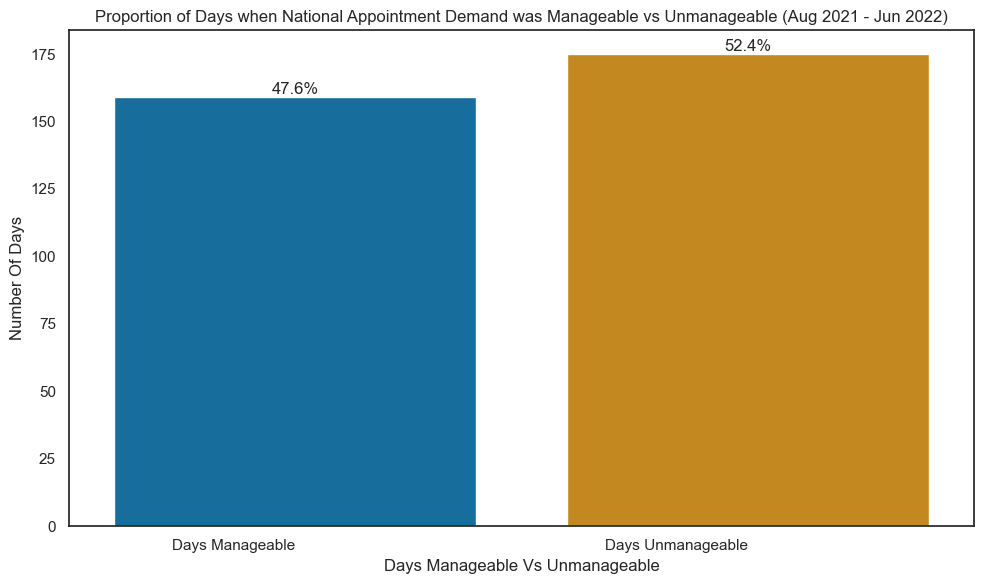

In [83]:
# Calculate the number of manageable and unmanageable days.
manageable_days = len(days_sufficient_nat_cap)
unmanageable_days = nc_num_appt_days - manageable_days

# Create a dataframe for the bar plot.
manageable_vs_unmanageable_demand_data = pd.DataFrame({'Days Manageable vs Unmanageable': ['Days Manageable', 'Days Unmanageable'], 
                                                       'Number of Days': [manageable_days, unmanageable_days]})

# Call the generate_standard_bar_plot_days function.
generate_standard_bar_plot_days(df = manageable_vs_unmanageable_demand_data, x_variable = 'Days Manageable vs Unmanageable',
                                y_variable = 'Number of Days',
                                plot_title = 'Proportion of Days when National Appointment Demand was Manageable vs Unmanageable (Aug 2021 - Jun 2022)',
                                palette = "colorblind", prefix = 'Manageable vs Unmanageable National Appointment Demand', show_percentages = True, 
                                total_value = nc_num_appt_days)

**Exploratory Visualisation** showing the proportion of days on which national demand was manageable vs unmanageable between August 2021 and June 2022.

**Question 4:** What were the top five ICB locations by appointment count?

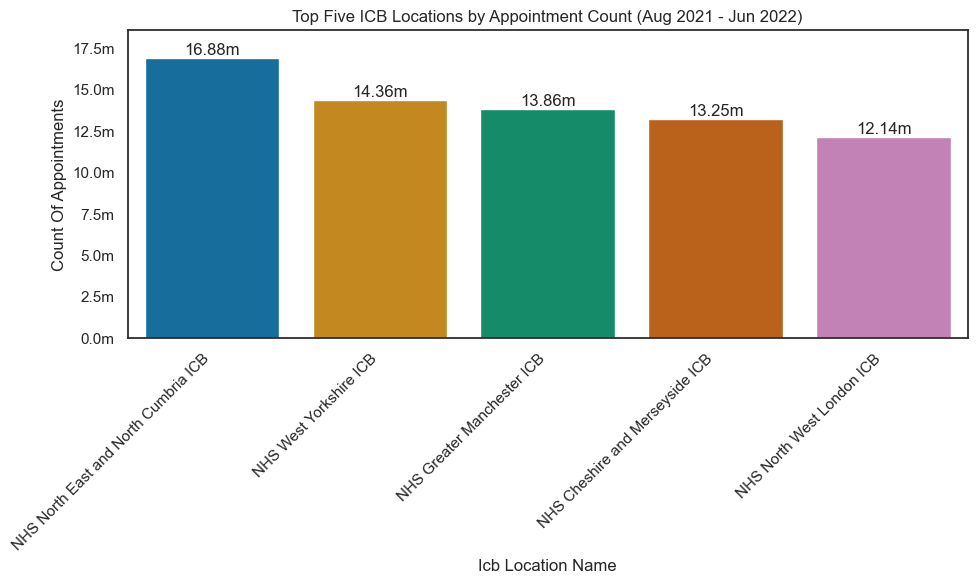

In [84]:
# Get the top five ICB locations by appointment count.
top_five_icb_locations = nc.groupby("icb_location_name")['count_of_appointments'].sum().nlargest(5).reset_index()

# Call the generate_standard_bar_plot_appts function.
generate_standard_bar_plot_appts(df = top_five_icb_locations, x_variable = 'icb_location_name', y_variable = 'count_of_appointments', 
                          plot_title = 'Top Five ICB Locations by Appointment Count (Aug 2021 - Jun 2022)',
                          palette = "colorblind", prefix = 'Top Five ICB Locations by Appointment Count', y_axis_format = "millions", 
                                 show_percentages = False, total_value = nc['count_of_appointments'].sum())

**Exploratory Visualisation** showing the top five ICB locations' counts of appointments per month over time between August 2021 and June 2022.

**Question 6:** How many appointments were booked in the top ICB location by appointment count each month (demand)?

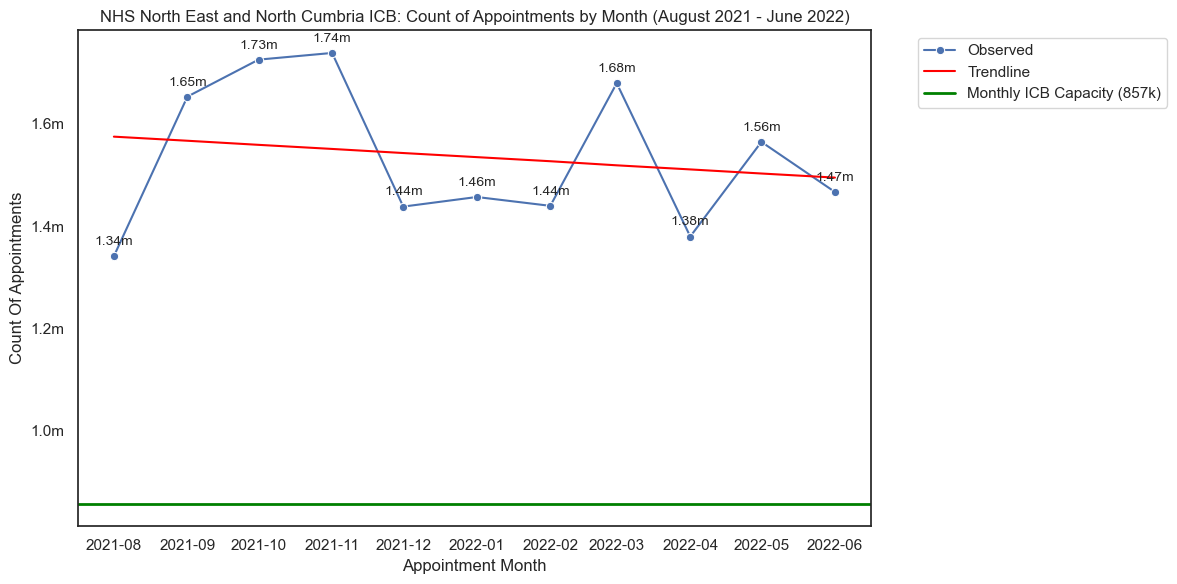

In [85]:
# Call the generate_time_series_plot function.
generate_time_series_plot(df = nenc_icb_monthly_appt_counts, time_col = 'appointment_month', value_col = 'count_of_appointments',
                                         plot_title = 'NHS North East and North Cumbria ICB: Count of Appointments by Month (August 2021 - June 2022)',
                                         palette = "colorblind", reference_line = 857130, ref_line_label = "Monthly ICB Capacity (857k)",
                                         prefix = "NENC Count of Appointments", y_axis_format = 'millions', show_trendline = True)

**Exploratory Visualisation** showing North East and North Cumbria ICB's count of appointments per month over time between August 2021 and June 2022.

**Question 7:** How often was the top ICB location by appointment count’s demand manageable within its capacity?

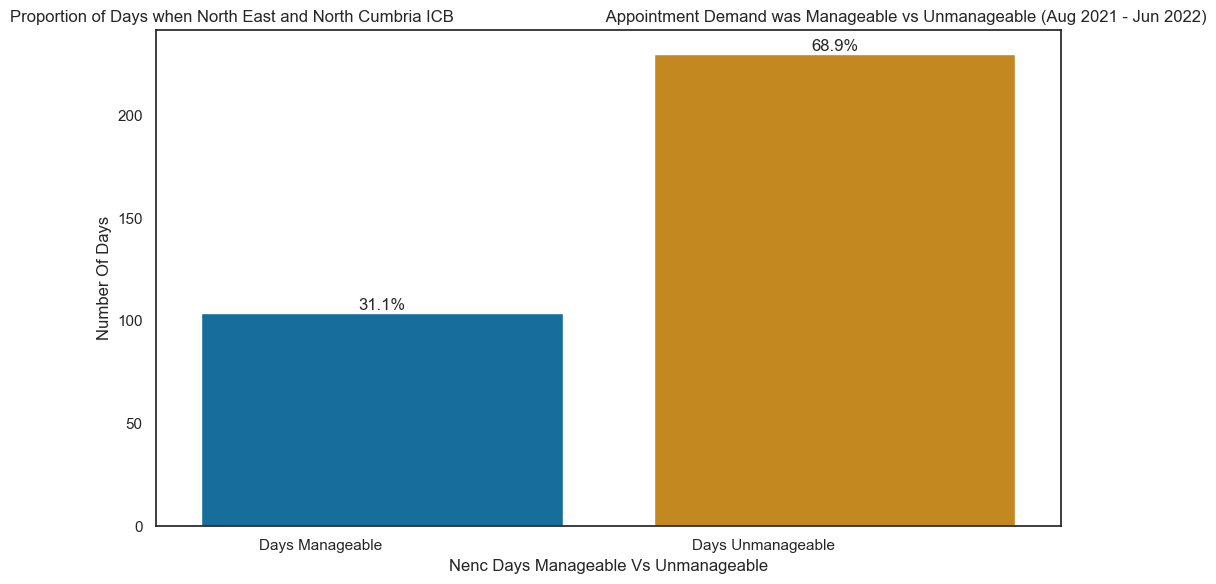

In [86]:
# Calculate the number of manageable and unmanageable days in North East and North Cumbria ICB.
manageable_days_nenc = len(days_sufficient_nenc_cap)
unmanageable_days_nenc = nenc_num_appt_days - manageable_days_nenc

# Create a dataframe for the bar plot.
nenc_manageable_vs_unmanageable_demand_data = pd.DataFrame({'NENC Days Manageable vs Unmanageable': ['Days Manageable', 'Days Unmanageable'], 
                                                       'Number of Days': [manageable_days_nenc, unmanageable_days_nenc]})

# Call the generate_standard_bar_plot_days function.
generate_standard_bar_plot_days(df = nenc_manageable_vs_unmanageable_demand_data, x_variable = 'NENC Days Manageable vs Unmanageable',
                                y_variable = 'Number of Days',
                                plot_title = 'Proportion of Days when North East and North Cumbria ICB \
                                Appointment Demand was Manageable vs Unmanageable (Aug 2021 - Jun 2022)',
                                palette = "colorblind", prefix = 'Manageable vs Unmanageable NENC Appointment Demand', show_percentages = True, 
                                total_value = nenc_num_appt_days)

**Exploratory Visualisation** showing the proportion of days on which North East and North Cumbria ICB's demand was manageable vs unmanageable between August 2021 and June 2022.

**Question 12:** Of the ICB locations that did not have enough capacity, how much demand did they experience for telephone and video/online appointments?

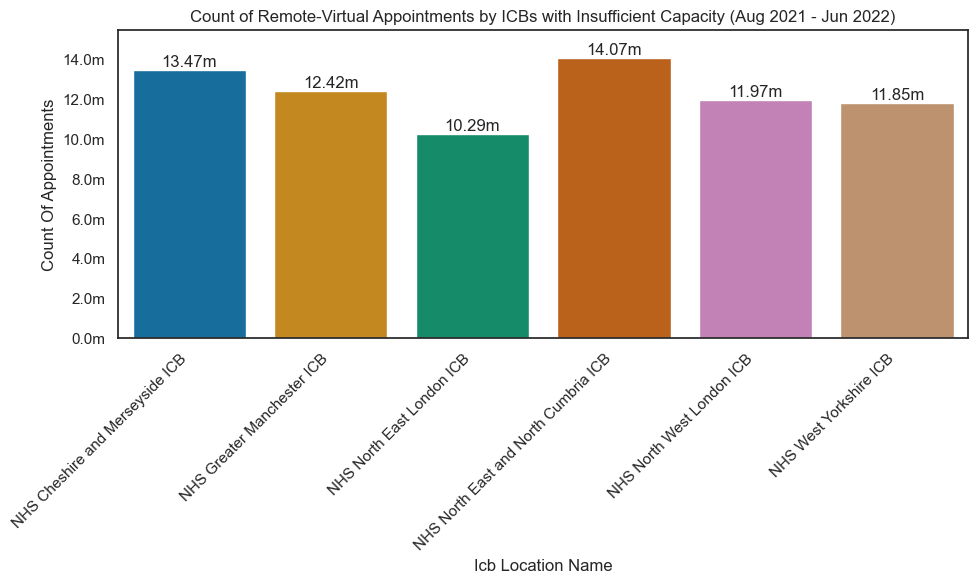

In [87]:
# Call the generate_standard_bar_plot_appts function.
generate_standard_bar_plot_appts(df = insufficient_cap_icbs_remote_virtual_appt_counts, x_variable = 'icb_location_name', 
                                 y_variable = 'count_of_appointments', 
                                 plot_title = 'Count of Remote-Virtual Appointments by ICBs with Insufficient Capacity (Aug 2021 - Jun 2022)',
                                 palette = "colorblind", prefix = 'Count of Remote-Virtual Appointments by ICBs with Insufficient Capacity', 
                                 y_axis_format = "millions", show_percentages = False,
                                 total_value = insufficient_cap_icbs_remote_virtual_appt_counts['count_of_appointments'].sum())

**Exploratory Visualisation** showing the number of remote/virtual appointments booked in each of the six ICBs that had insufficient capacity to manage their daily demand between August 2021 and June 2022.

##### High-level Business Question 2) What was the actual utilisation of resources?

**Question 2:** What was the average daily national appointment capacity utilisation (%) for the period August 2021 to June 2022

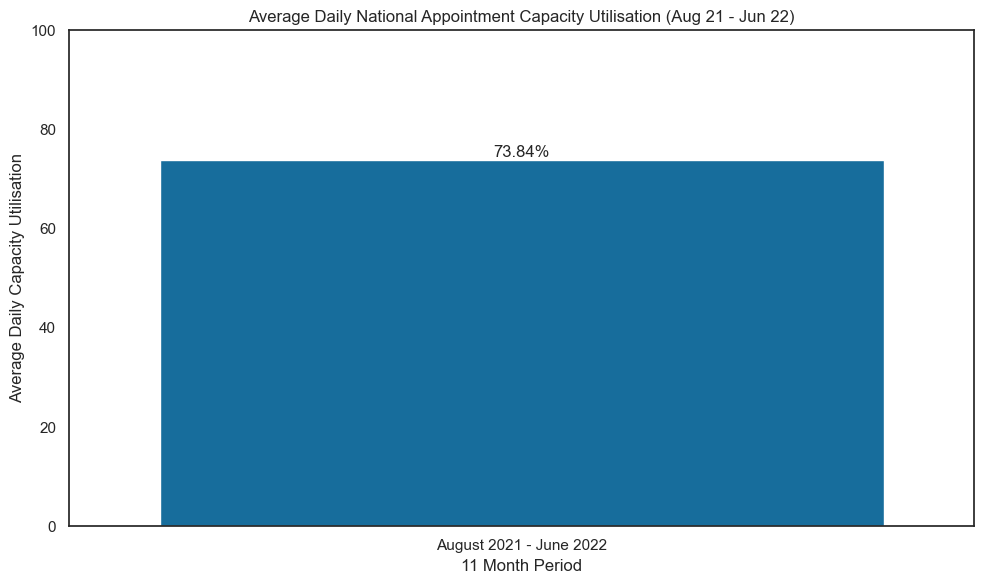

In [88]:
# Create a DataFrame for the average daily national capacity utilisation figure.
nat_cap_util_figure = pd.DataFrame({'11_month_period': ['August 2021 - June 2022'], 'average_daily_capacity_utilisation': [73.84]})

# Call the generate_standard_bar_plot_appts function.
generate_standard_bar_plot_appts(df = nat_cap_util_figure, x_variable = "11_month_period", y_variable = "average_daily_capacity_utilisation", 
                                 plot_title = "Average Daily National Appointment Capacity Utilisation (Aug 21 - Jun 22)", palette = "colorblind", 
                                 errorbar = None, reference_line = None, ref_line_label = None, 
                                 prefix = "Average Daily National Appointment Capacity Utilisation", y_axis_format = None,
                                 show_percentages = True, total_value = None)

**Exploratory visualisation** showing the average daily national appointment capacity utilisation between August 2021 and June 2022.

**Question 4:** What was NHS North East and North Cumbria ICB's average daily appointment capacity utilisation (%) for the period August 2021 to June 2022?

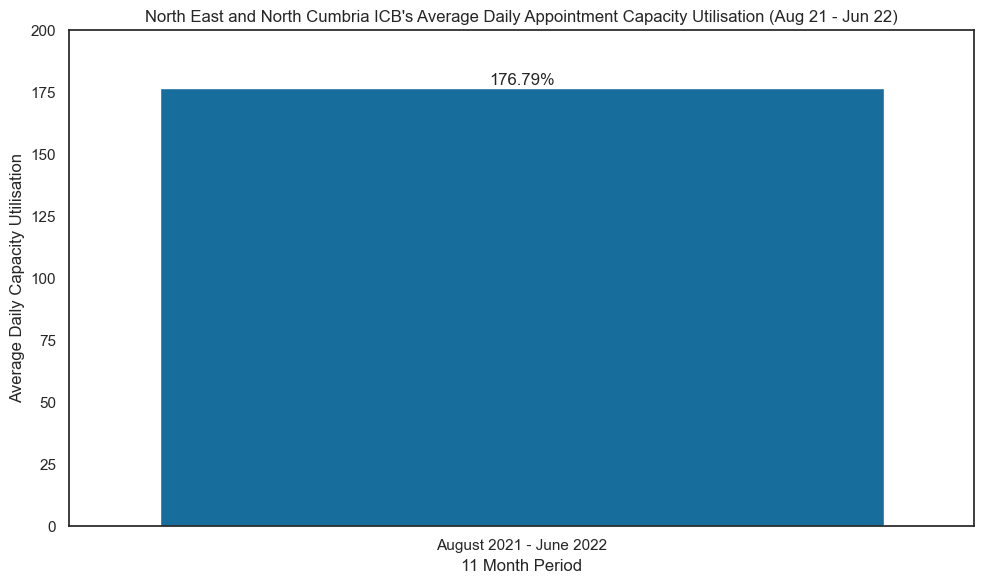

In [89]:
# Create a DataFrame for the average daily NENC capacity utilisation figure.
nenc_cap_util_figure = pd.DataFrame({'11_month_period': ['August 2021 - June 2022'], 'average_daily_capacity_utilisation': [176.79]})

# Call the generate_standard_bar_plot_appts function.
generate_standard_bar_plot_appts(df = nenc_cap_util_figure, x_variable = "11_month_period",
                                 y_variable = "average_daily_capacity_utilisation", 
                                 plot_title = "North East and North Cumbria ICB's Average Daily Appointment Capacity Utilisation (Aug 21 - Jun 22)", 
                                 palette = "colorblind", errorbar = None, reference_line = None, ref_line_label = None, 
                                 prefix = "NENC ICB's Average Daily Appointment Capacity Utilisation", y_axis_format = None,
                                 show_percentages = True, total_value = None)

**Exploratory visualisation** showing North East and North Cumbria ICB's average daily appointment capacity utilisation between August 2021 and June 2022.

**Question 5:** What proportions of the total national appointment demand between August 2021 and June 2022 were attended, booked, or status unknown?

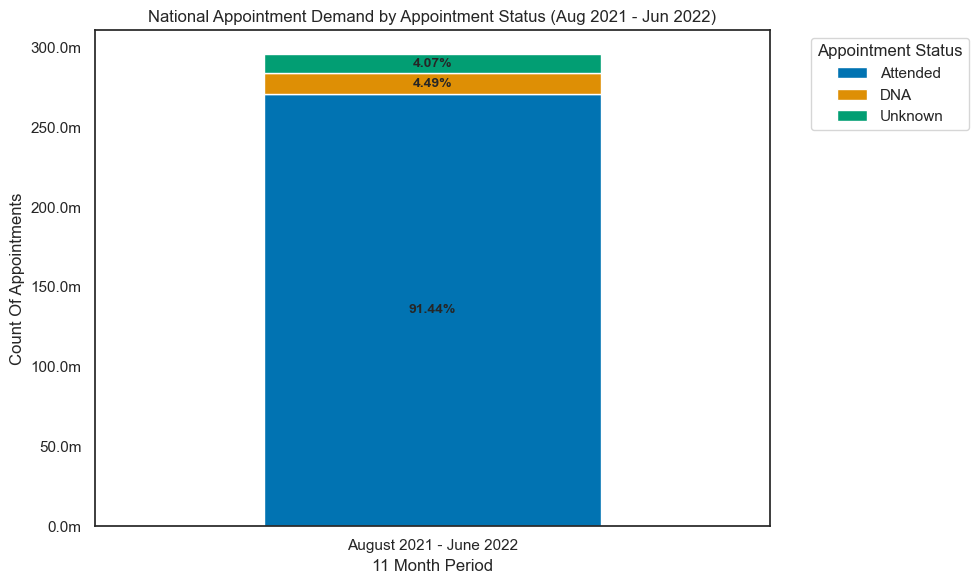

In [90]:
# Create a new column in the ar_no_dups_aug21_to_jun22_statuses DataFrame with a static label for the x-axis.
ar_no_dups_aug21_to_jun22_statuses['11_month_period'] = 'August 2021 - June 2022'

# Call the generate_stacked_bar_plot function.
generate_stacked_bar_plot(df = ar_no_dups_aug21_to_jun22_statuses, x_variable = "11_month_period", 
                          hue_variable = "appointment_status", y_variable = "count_of_appointments", 
                          plot_title = "National Appointment Demand by Appointment Status (Aug 2021 - Jun 2022)", 
                          palette = "colorblind", prefix = "National Appointment Demand by Appointment Status", y_axis_format = "millions")

**Exploratory visualisation** showing the proportion of national appointment demand that was either attended, not attended, or had an unknown attendance status between August 2021 and June 2022.

**Question 6:** What proportions of NHS North East and North Cumbria ICB's total appointment demand between August 2021 and June 2022 were attended, booked, or status unknown?

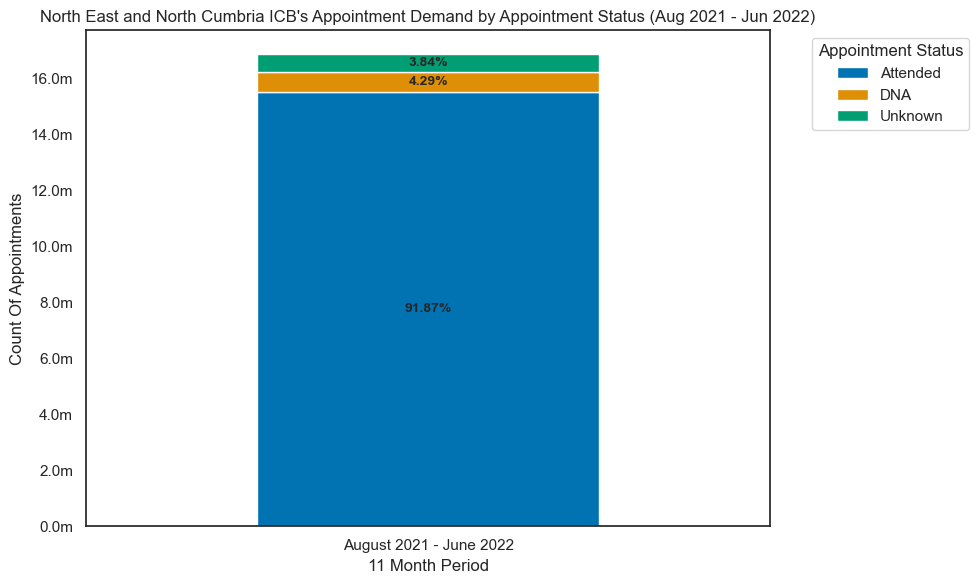

In [91]:
# Create a new column in the ar_no_dups_aug21_to_jun22_statuses DataFrame with a static label for the x-axis.
ar_no_dups_aug21_to_jun22_nenc_statuses['11_month_period'] = 'August 2021 - June 2022'

# Call the generate_stacked_bar_plot function.
generate_stacked_bar_plot(df = ar_no_dups_aug21_to_jun22_nenc_statuses, x_variable = "11_month_period", 
                          hue_variable = "appointment_status", y_variable = "count_of_appointments", 
                          plot_title = "North East and North Cumbria ICB's Appointment Demand by Appointment Status (Aug 2021 - Jun 2022)", 
                          palette = "colorblind", prefix = "NENC ICB's Appointment Demand by Appointment Status", y_axis_format = "millions")

**Exploratory visualisation** showing the proportion of North East and North Cumbria ICB's appointment demand that was either attended, not attended, or had an unknown attendance status between August 2021 and June 2022.

**Question 7:** What was NHS North East and North Cumbria ICB's DNA rate per appointment mode between August 2021 and June 2022?

In [92]:
ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode

,appointment_mode,appt_mode_totals,dna_count,dna_rate
0,Face-to-Face,11327961,609528,5.38
1,Home Visit,123916,4061,3.28
2,Telephone,4894010,92769,1.90
3,Unknown,481089,15623,3.25
4,Video/Online,43794,2176,4.97


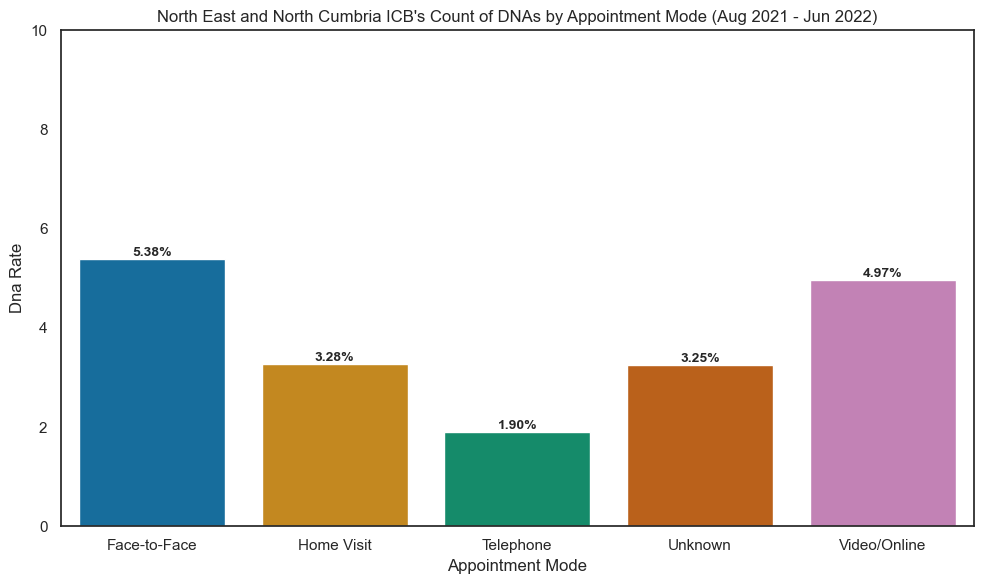

In [93]:
# Call the generate_standard_bar_plot_appts function.
generate_standard_bar_plot_appts(df = ar_no_dups_aug21_to_jun22_nenc_dna_rates_by_mode, x_variable = 'appointment_mode', 
                                 y_variable = 'dna_rate', 
                                 plot_title = "North East and North Cumbria ICB's Count of DNAs by Appointment Mode (Aug 2021 - Jun 2022)",
                                 palette = "colorblind", prefix = "NENC ICB's Count of DNAs by Appointment Mode", 
                                 y_axis_format = None, show_percentages = False, label_variable = "dna_rate", 
                                 total_value = None, y_axis_limit = 10)

**Exploratory visualisation** showing North East and North Cumbria ICB's DNA rate per appointment mode between August 2021 and June 2022.

**Question 8:** What was NHS North East and North Cumbria ICB's DNA rates for face-to-face and video/online appointments, month on month, between August 2021 and June 2022?

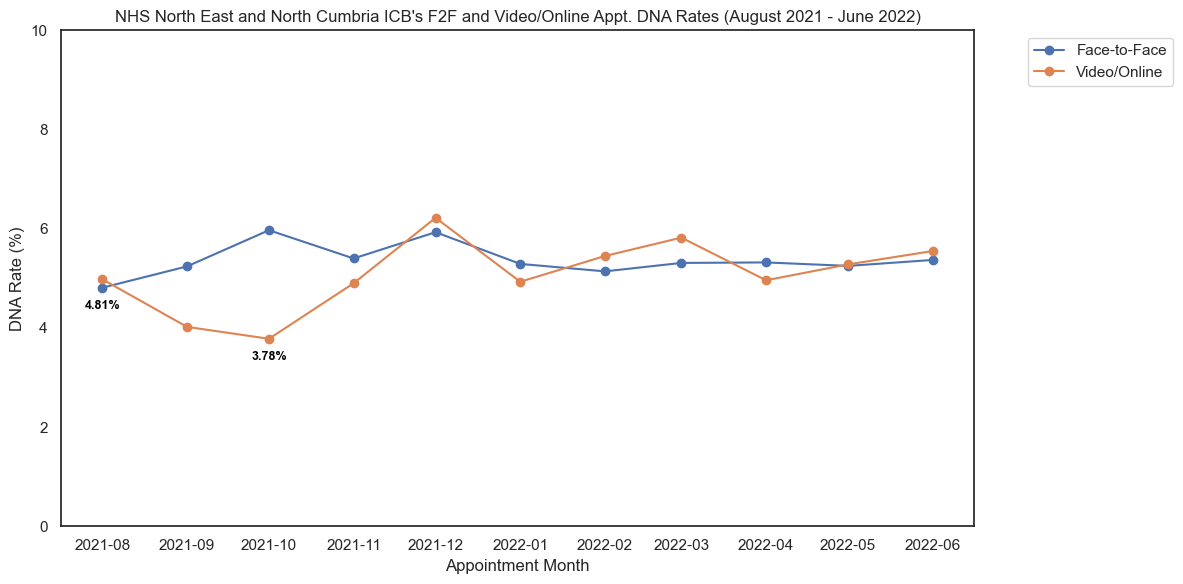

In [94]:
# Reset the index of the pivot_ar_no_dups_aug21_to_jun22_nenc_dnas DataFrame.
pivot_ar_no_dups_aug21_to_jun22_nenc_dnas_reset = pivot_ar_no_dups_aug21_to_jun22_nenc_dnas.reset_index()

# Call the generate_time_series_plot function.
generate_time_series_plot(df = pivot_ar_no_dups_aug21_to_jun22_nenc_dnas_reset, 
                          time_col = 'appointment_month', value_col = ['Face-to-Face', 'Video/Online'],
                          plot_title = "NHS North East and North Cumbria ICB's F2F and Video/Online Appt. DNA Rates (August 2021 - June 2022)", 
                          palette = "colorblind", reference_line = None, ref_line_label = None,
                          prefix = "NENC ICB's F2F and Video and Online Appt. DNA Rates", y_axis_format = None, y_axis_limit = 10, 
                          show_trendline = False)

**Exploratory visualisation** showing North East and North Cumbria ICB's DNA rates for face-to-face and video/online appointments, month on month, between August 2021 and June 2022.

# Social Media Data Analysis (Assignment Activity 5)

#### Analyse tweets from Twitter with hashtags related to healthcare in the UK:

In [95]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [96]:
# Load the data set.
tweets = pd.read_csv("tweets.csv")

# View the DataFrame.
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [97]:
# Explore the metadata.
print(tweets.shape)
print(tweets.dtypes)
print(tweets.columns)

(1174, 10)
tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count         int64
tweet_favorite_count        int64
tweet_favorited              bool
tweet_retweeted              bool
tweet_lang                 object
dtype: object
Index(['tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'],
      dtype='object')


In [98]:
# Explore the data set.
print(tweets.info())
print(tweets.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std

In [99]:
# Explore the tweet_retweet_count column.
tweets["tweet_retweet_count"].value_counts().sort_index(ascending = False)

tweet_retweet_count
303      1
208     12
207      3
169      1
150      4
107      1
85       3
79       1
78       2
76       3
73      14
72       2
68       3
63       4
62       3
57       1
54       1
53       5
49       1
48       1
44       4
41       3
40       1
39       1
37       6
35      10
24       2
23       2
20       1
19       1
16       2
15       1
14       1
13       1
12      16
11       6
10       5
9       13
8       15
7       18
6       12
5       35
4       27
3       70
2      114
1      215
0      526
Name: count, dtype: int64

In [100]:
# Explore the tweet_favorite_count column.
tweets["tweet_favorite_count"].value_counts().sort_index(ascending = False)

tweet_favorite_count
42       1
28       1
20       1
18       1
17       1
14       1
13       1
12       1
11       1
10       1
9        1
8        1
7        1
6        2
5        5
4        7
3       13
2       16
1       91
0     1027
Name: count, dtype: int64

In [101]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.

# It would be useful to look at both the retweeted and favourited tweets in greater detail.
# This is because the more a tweet is retweeted or favourited, the more likely it is that many people share the same sentiments as the author.
# For example, one tweet was retweeted 303 times and another was favourited 42 times, which indicates that the tweets resonated with a lot of people.
# The NHS could gain great insight by looking at such tweets if they relate to the services they provide/commission, e.g., primary care appointments.
# However, care should be taken to not focus exclusively on those tweets that have been retweeted or favourited many times.
# To do this would be to risk forgoing useful insights within tweets that could also have been popular but which may not have had such a wide audience.

In [102]:
# Create a new DataFrame containing only the text.
tweets_text = tweets[["tweet_full_text"]]

# View the DataFrame.
tweets_text

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."
...,...
1169,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…
1170,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie..."
1171,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp..."
1172,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC


In [103]:
# Loop through the messages, and create a list of values containing the # symbol.
# Create a variable (tags) and assign an empty list to it.
tags = []

# Use a for loop to extract hashtags.
for y in [x.split(" ") for x in tweets["tweet_full_text"].values]:
    for z in y:
        if "#" in z:
            # Change to lowercase.
            tags.append(z.lower())

# Create a pandas Series to count the values in the list.
tags = pd.Series(tags).value_counts()

In [104]:
# Display the first 30 records.
tags.head(30)

#healthcare                    716
#health                         80
#medicine                       41
#ai                             40
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#medtwitter                     24
#biotech                        24
#competitiveintelligence        24
#meded                          23
#vaccine                        18
#hiring                         18
#news                           17
#machinelearning                17
#technology                     17
#coronavirus                    16
#womeninmedicine                16
#covid                          16
#competitivemarketing           16
#wellness                       15
#healthtech                     15
#doctorofveterinarymedicine     14
#science                        14
#medicare           

In [105]:
# Convert the series to a DataFrame in preparation for visualisation.
twitter_data = tags.to_frame().reset_index()

# Rename the columns.
twitter_data.columns = ["word", "count"]

In [106]:
# Fix the count datatype.
# Ensure the count data type is an integer for data analysis.
twitter_data["count"] = twitter_data["count"].astype(int)

# View the result.
twitter_data

,word,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
...,...,...
1749,#evestudy,1
1750,#patientdata…,1
1751,#secure,1
1752,#sms,1


In [107]:
# Filter records where count is larger than 10.
filtered_twitter_data = twitter_data[twitter_data["count"] > 10]

# Display the filtered data.
filtered_twitter_data

,word,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
5,#medical,35
6,#strategy,30
7,#pharmaceutical,28
8,#digitalhealth,25
9,#pharma,25


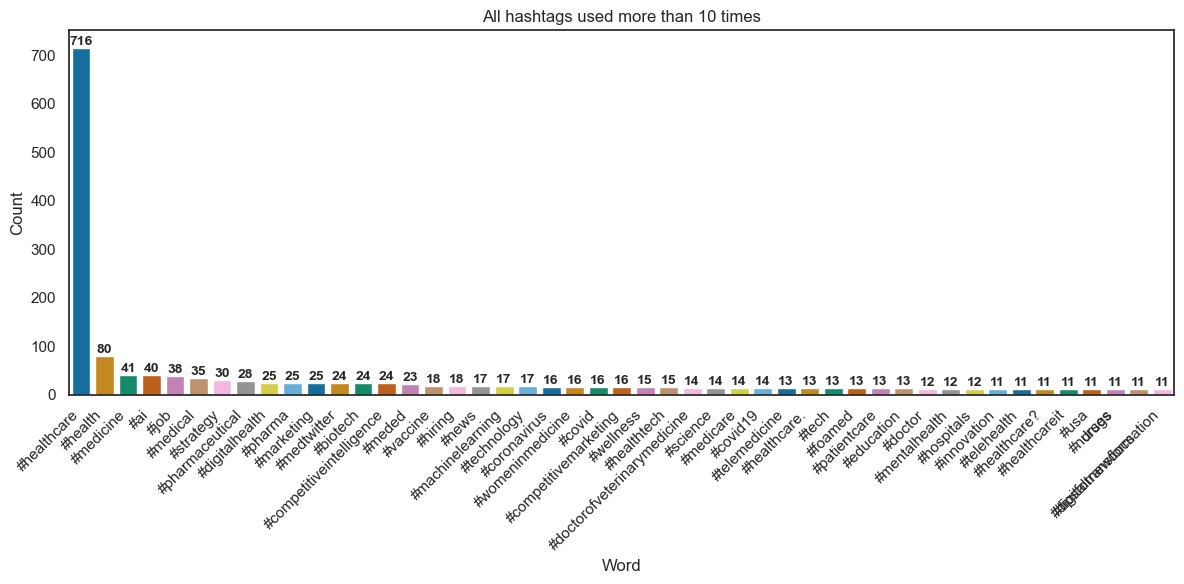

In [108]:
# Create a Seaborn barplot indicating all records with a count >10 records.
# Create the bar chart.
plt.figure(figsize = (12, 6))
ax = plt.gca()
sns.barplot(data = filtered_twitter_data, x = "word", y = "count", palette = "colorblind")

# Add data labels to the top of each bar.
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{int(height)}',
            ha="center", va="bottom", fontsize=10, fontweight='bold')

# Customise the plot.
plt.title("All hashtags used more than 10 times")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

# Save the plot.
plt.savefig("All hashtags used more than 10 times_barchart.png", dpi = 100, bbox_inches = "tight")

# View the plot.
plt.show()

**Observation:** 47 hashtags appeared more than ten times each within the dataset. #healthcare appeared a total of 716 times, with the next greatest appearance being by #health (80 times). This suggests that #healthcare could be greatly overrepresented within the dataset. Also, some of the other hashtags that featured frequently may not be relevant to the NHS or its business questions, e.g., #health, #medicine, #ai, #job, and #medical are all generic enough terms to not necessarily be relevant.

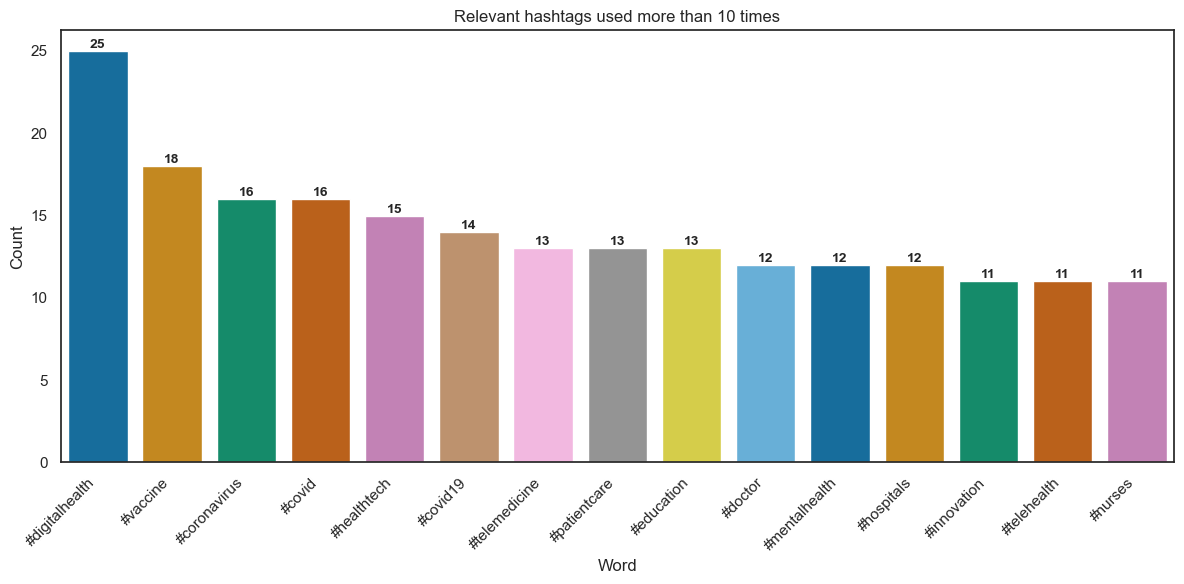

In [109]:
# Define words to remove (overrepresented or deemed unlikely to be relevant).
overrepresented_or_irrelevant = [
    '#healthcare', '#health', '#medicine', '#ai', '#job', '#medical', 
    '#strategy', '#pharmaceutical', '#pharma', '#marketing', '#medtwitter', 
    '#biotech', '#competitiveintelligence', '#meded', '#hiring', '#news', 
    '#machinelearning', '#technology', '#womeninmedicine', '#competitivemarketing', 
    '#wellness', '#doctorofveterinarymedicine', '#science', '#medicare', '#tech', 
    '#foamed', '#healthcare.', '#healthcare?', '#healthcareit', '#usa', 
    '#digitaltransformation', 'drugs\n\n#tipsfornewdocs'
]

# Filter out the overrepresented and irrelevant hashtags.
filtered_twitter_data = filtered_twitter_data[~filtered_twitter_data['word'].isin(overrepresented_or_irrelevant)]

# Create a Seaborn barplot indicating relevant records with a count >10 records.
# Create the bar chart.
plt.figure(figsize = (12, 6))
ax = plt.gca()
sns.barplot(data = filtered_twitter_data, x = "word", y = "count", palette = "colorblind")

# Add data labels to the top of each bar.
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{int(height)}',
            ha="center", va="bottom", fontsize=10, fontweight='bold')

# Customise the plot.
plt.title("Relevant hashtags used more than 10 times")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

# Save the plot.
plt.savefig("Relevant hashtags used more than 10 times_barchart.png", dpi = 100, bbox_inches = "tight")

# View the plot.
plt.show()

**Observation(s):** People are actively discussing #digitalhealth, #healthtech, #telemedicine, and #telehealth on Twitter. Tweets with these hashtags could be relevant to the NHS because they may provide insights into the demand for and effectiveness of primary care appointments that utilise digital health etc. solutions. This may be particularly relevant, as COVID-19 was clearly still topical at the time of the data collection, given the presence of #vaccine, #coronavirus, #covid, and #covid19 within the tweets, and COVID is known to have been a driving force behind the rapid scaling of digital health solutions. 212 tweets were deemed to have relevant hashtags that appeared more than 10 times each, accounting for 18% of the sample dataset (nearly 1/5 tweets). This may indicate that the value of being able to analyse Twitter data could be high enough to justify the financial investment. However, a sentiment analysis of these tweets would be required to determine how insightful this data could truly be, specifically, by measuring whether public perception of investment in digital health services is positive or negative, which could then directly inform communications and engagement efforts and commissioning priorities.

# Insights and Recommendations (inc. Assignment Activity 6)

#### Assignment Activity 6 Questions:

In [110]:
# View the ar_no_dups DataFrame.
ar_no_dups.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,icb_location_name
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,NHS Frimley ICB
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,NHS Frimley ICB
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,NHS Frimley ICB
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,NHS Frimley ICB
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,NHS Frimley ICB


In [111]:
# Print the min and max dates.
# Create two new DataFrames to hold the minimum and maximum dates (months).
ar_no_dups_min_date = ar_no_dups['appointment_month'].min()
ar_no_dups_max_date = ar_no_dups['appointment_month'].max()

# View the minimum and maximum dates (months).
print(f"Earliest Appointment Month: {ar_no_dups_min_date}")
print(f"Latest Appointment Month: {ar_no_dups_max_date}")

Earliest Appointment Month: 2020-01
Latest Appointment Month: 2022-06


**Observation(s):** The range of the dataset is January 2020 to June 2022.

In [112]:
# Filter the data set to only look at data from 2021-08 onwards.
ar_no_dups_aug21_onwards = ar_no_dups[ar_no_dups['appointment_month'] >= '2021-08']

ar_no_dups_aug21_onwards.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,icb_location_name
3652,E54000034,2021-08,Attended,GP,Face-to-Face,1 Day,6553,NHS Frimley ICB
3653,E54000034,2021-08,Attended,GP,Face-to-Face,15 to 21 Days,2390,NHS Frimley ICB
3654,E54000034,2021-08,Attended,GP,Face-to-Face,2 to 7 Days,10547,NHS Frimley ICB
3655,E54000034,2021-08,Attended,GP,Face-to-Face,22 to 28 Days,937,NHS Frimley ICB
3656,E54000034,2021-08,Attended,GP,Face-to-Face,8 to 14 Days,4961,NHS Frimley ICB


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [113]:
# Create an aggregated data set to review the different features.
# Specify the 'appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode', and 'time_between_book_and_appointment' columns.
# Group the data by count_of_appointments, then sum the data, and then reset the index.
ar_agg = ar_no_dups_aug21_onwards \
    .groupby(['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode', 'time_between_book_and_appointment']) \
    ['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [114]:
# Determine the total number of appointments per month.
# Group by appointment month, then sum the count of appointments, and then reset the index.
ar_agg_appts_by_month = ar_agg.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_agg_appts_by_month['avg daily utilisation of services'] = (ar_agg_appts_by_month['count_of_appointments'] / 30).round(1)

# View the DataFrame.
ar_agg_appts_by_month

,appointment_month,count_of_appointments,avg daily utilisation of services
0,2021-08,23843177,794772.6
1,2021-09,28514685,950489.5
2,2021-10,30296850,1009895.0
3,2021-11,30395923,1013197.4
4,2021-12,25132174,837739.1
5,2022-01,25623928,854130.9
6,2022-02,25344812,844827.1
7,2022-03,29586020,986200.7
8,2022-04,23904960,796832.0
9,2022-05,27478652,915955.1


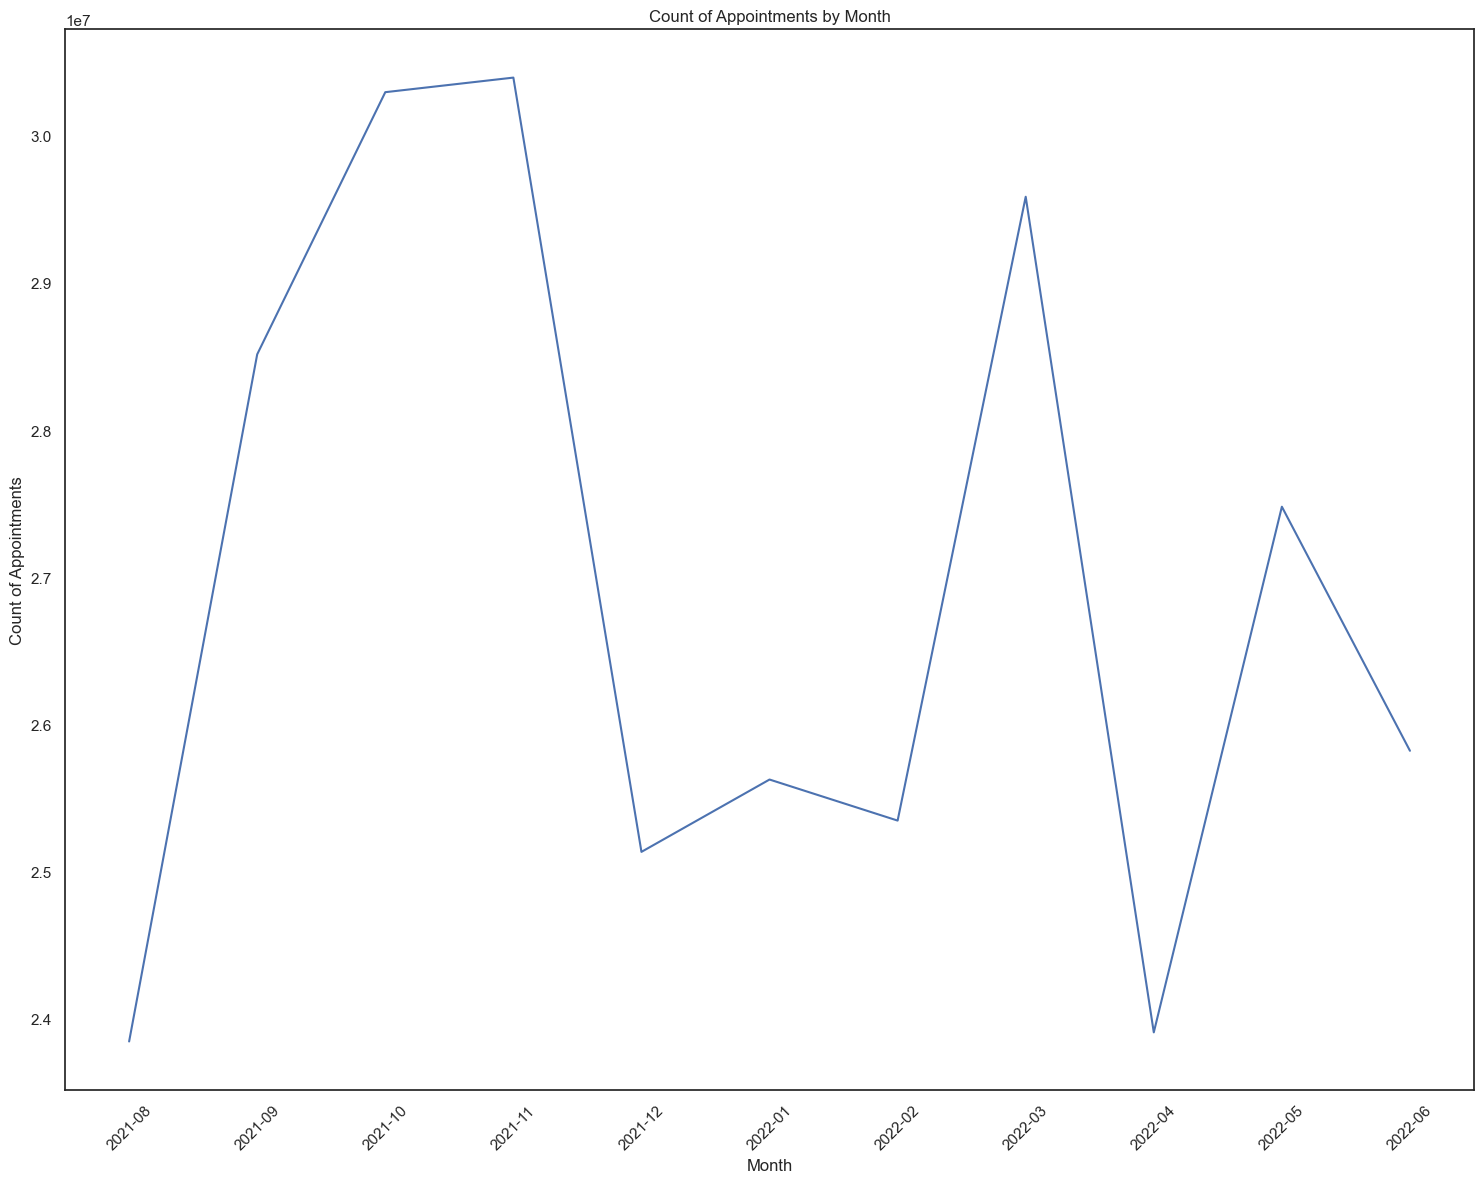

In [115]:
# Plot sum of count of monthly visits.
# Convert appointment_month to string for ar_agg
ar_agg['appointment_month'] = ar_agg['appointment_month'].astype(str)

# Convert appointment_month to string for ar_agg_appts_by_month
ar_agg_appts_by_month['appointment_month'] = ar_agg_appts_by_month['appointment_month'].astype(str)

# Create a lineplot with Seaborn.
sns.lineplot(data = ar_agg_appts_by_month, x = 'appointment_month', y = 'count_of_appointments')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Count of Appointments')
plt.title('Count of Appointments by Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** The lowest monthly count of appointments was 23.84 million in August 2021 and the highest was 30.40 million in November 2021.

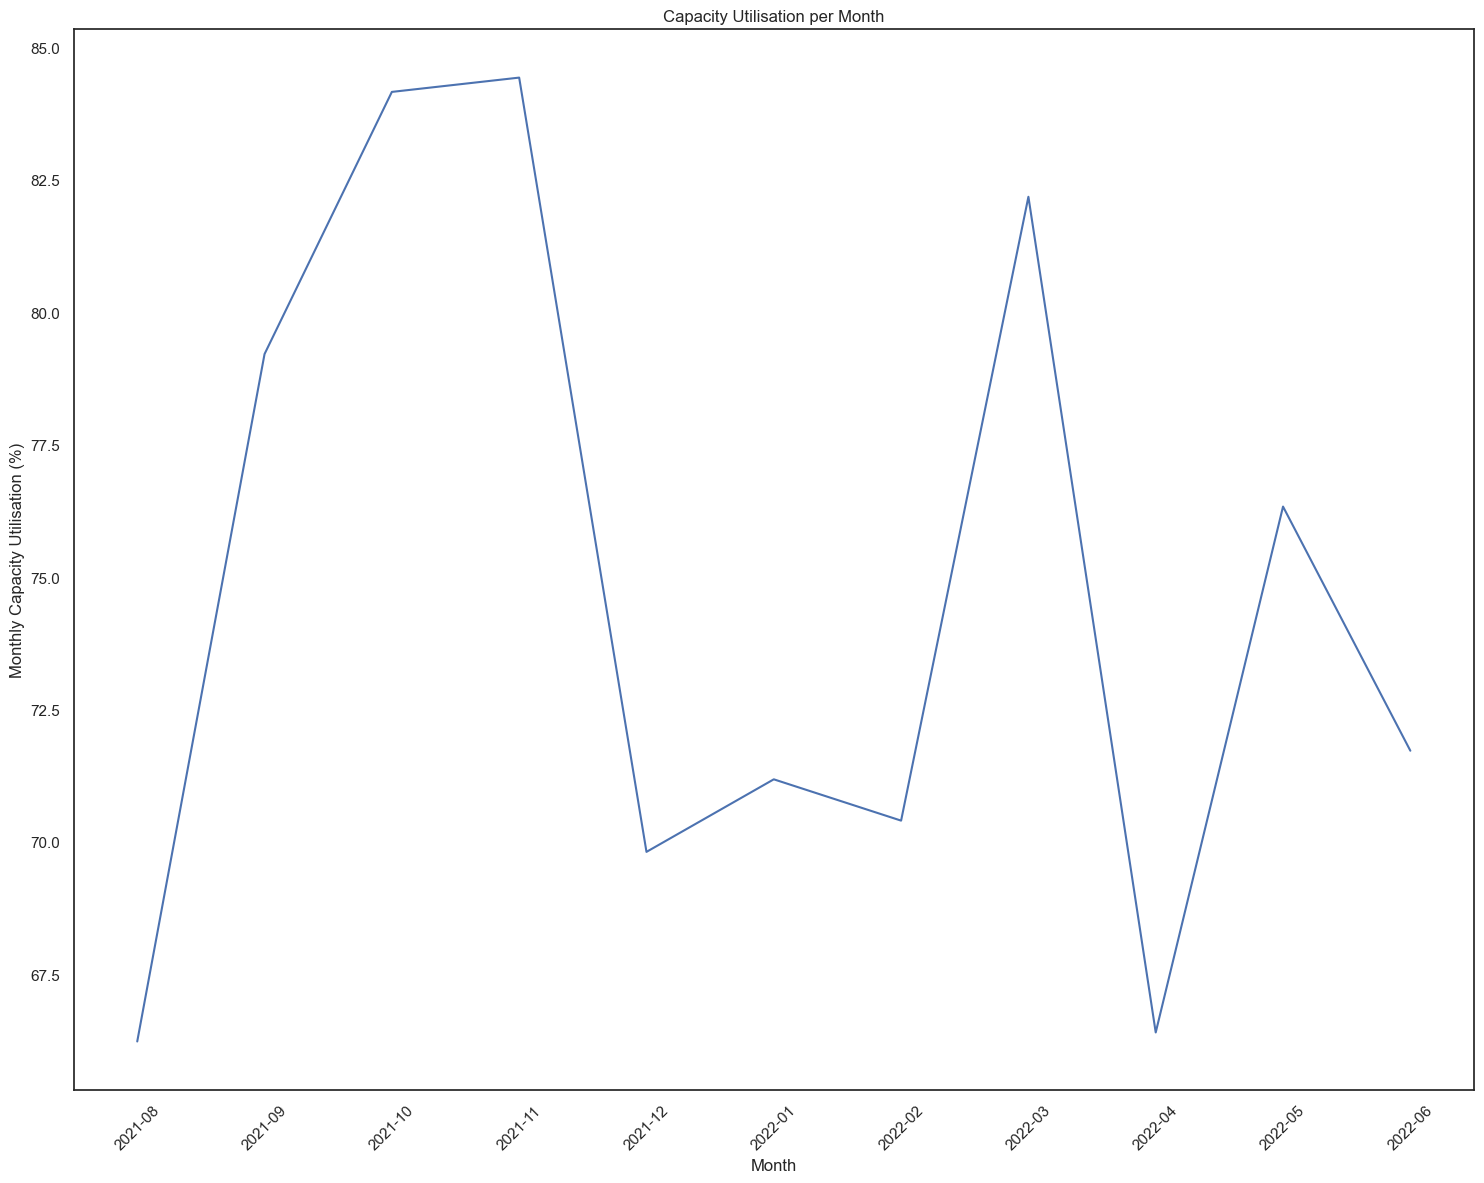

In [116]:
# Plot monthly capacity utilisation.
# Add a new column to indicate the capacity utilisation.
# Monthly count of appointments / (capacity of 1.2 million daily appointments * 30 days) to get to a daily value.
ar_agg_appts_by_month['monthly_capacity_utilisation_(%)'] = ((ar_agg_appts_by_month['count_of_appointments'] / (1200000 * 30)).round(4) * 100)

# View the DataFrame.
ar_agg_appts_by_month

# Create a lineplot.
sns.lineplot(data = ar_agg_appts_by_month, x = 'appointment_month', y = 'monthly_capacity_utilisation_(%)')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Monthly Capacity Utilisation (%)')
plt.title('Capacity Utilisation per Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** The lowest monthly capacity utilisation was 66.23% in August 2021 and the highest was 84.43% in November 2021.

**Summary:** "Should the NHS start looking at increasing staff levels?" is the wrong question. It cannot be answered through use of the data in Question 1 of the assignment activity (or through use of any of the data in any of the datasets provided by the NHS). The question should instead be "should the NHS start looking at increasing capacity levels?", to which the answer is "probably, yes, but it should also start looking at making better use of its existing capacity".

**Question 2:** How do the healthcare professional types differ over time?

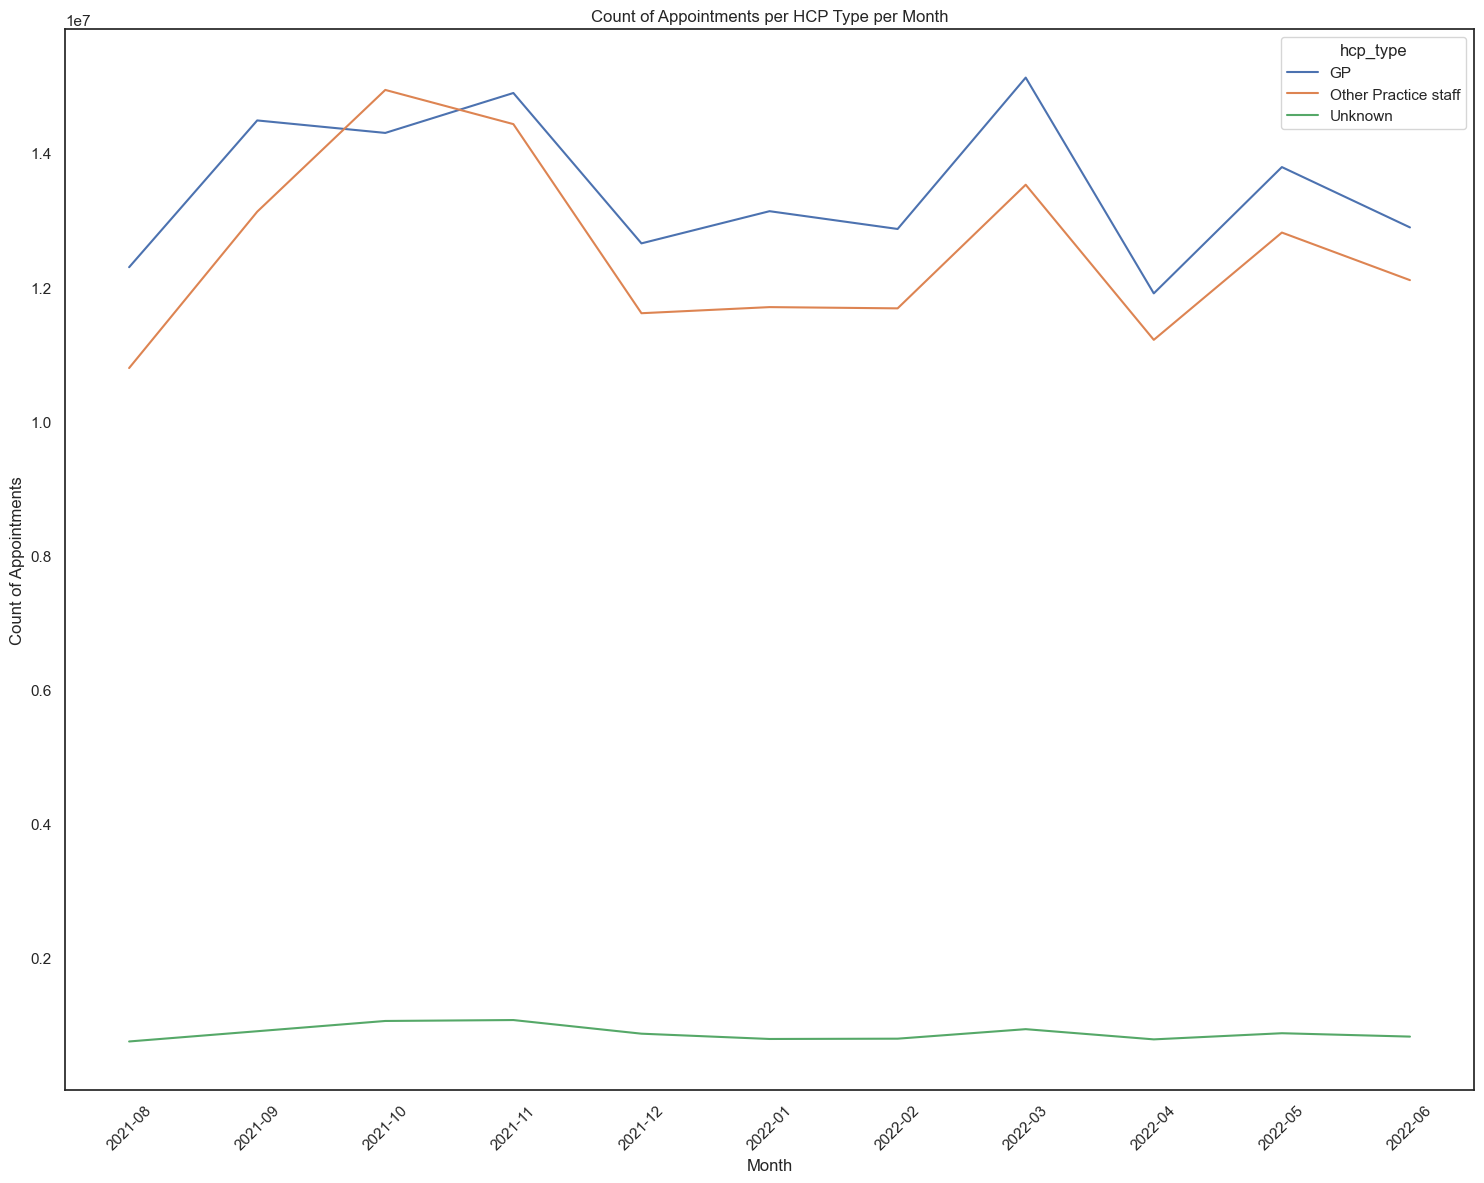

In [117]:
# Create a line plot to answer the question.
# Group the data by appointment_month and hcp_type, then sum by count_of_appointments, and then reset the index.
ar_agg_hcp_appts_by_month = ar_agg.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# Create a lineplot.
sns.lineplot(data = ar_agg_hcp_appts_by_month, x = 'appointment_month', y = 'count_of_appointments', hue = 'hcp_type')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Count of Appointments')
plt.title('Count of Appointments per HCP Type per Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Summary:** "How do the healthcare professional types differ over time?" is the wrong question. It cannot be answered through use of the data in Question 2 of the assignment activity (or through use of any of the data in any of the datasets provided by the NHS). The question should instead be "how do counts of appointments by specific HCP types differ over time?", to which the answer is "counts of appointments by GPs and other Practice Staff generally followed the same pattern over the observed period, increasing between August and October 2021, then decreasing until December 2021, then remaining stable until February 2022, after which demand fluctuated up and down with each passing month."

**Question 3:** Are there significant changes in whether or not visits are attended?

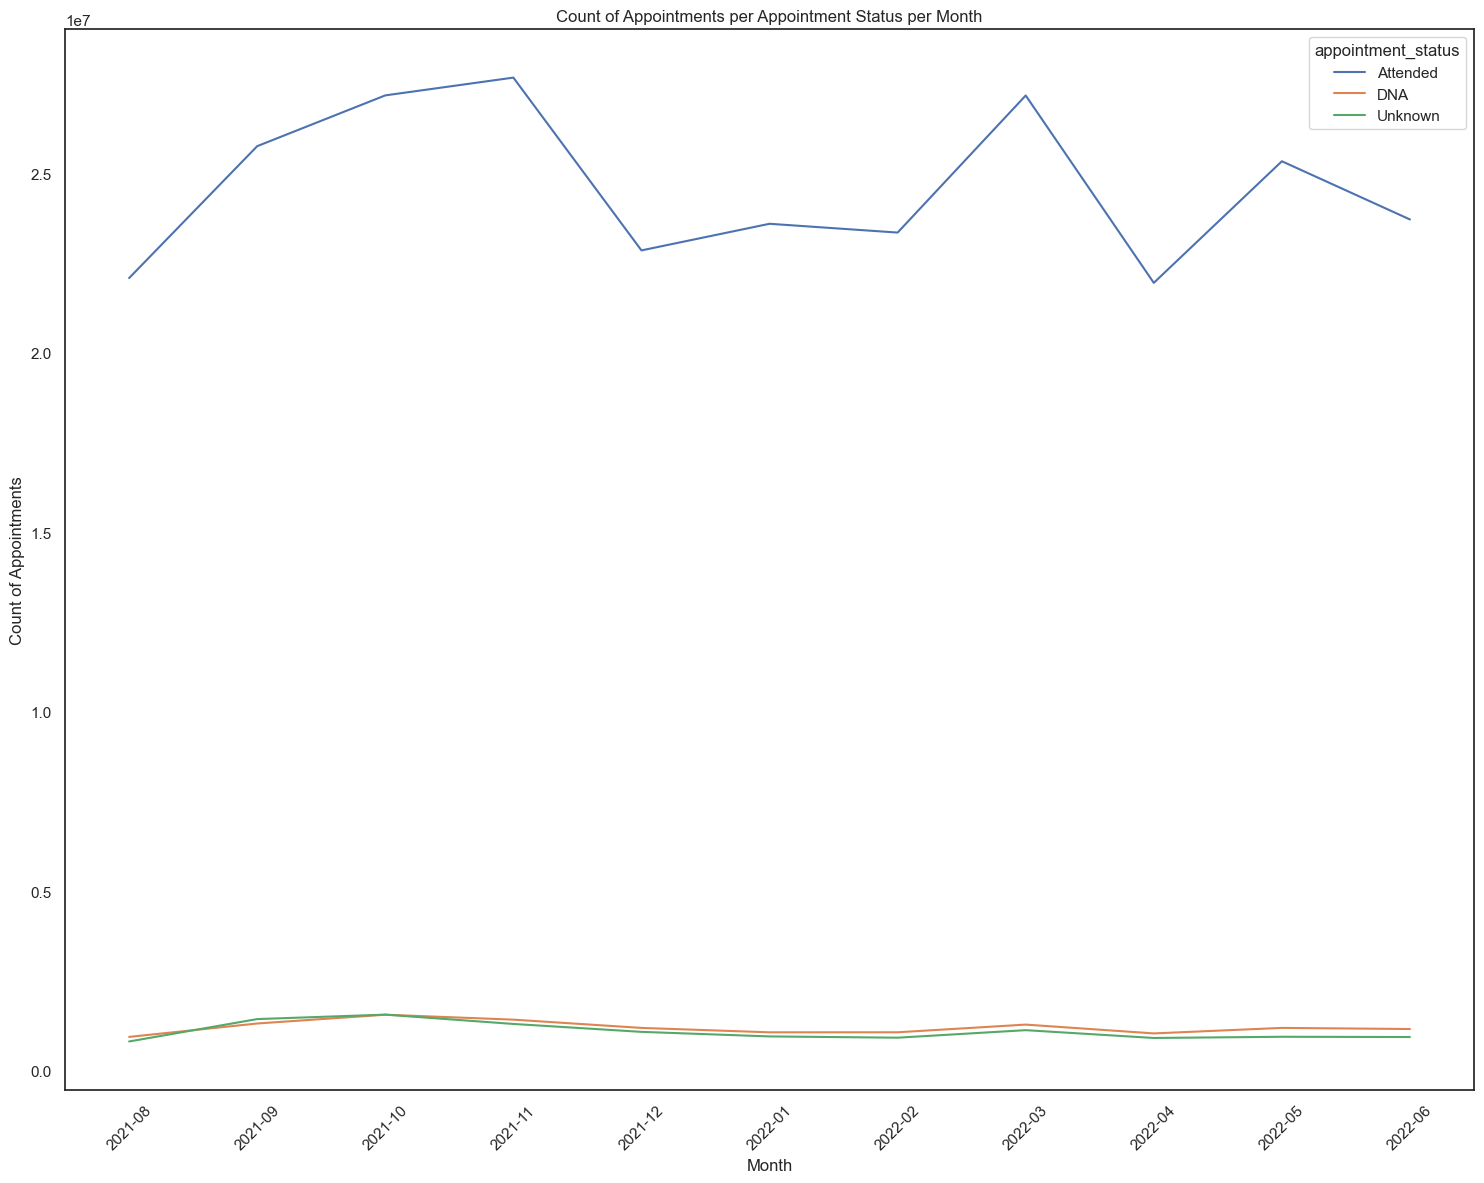

In [118]:
# Create a line plot to answer the question.
# Group the data by appointment_month and appointment_status, then sum by count_of_appointments, and then reset the index.
ar_agg_appt_status_by_month = ar_agg.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Create a lineplot.
sns.lineplot(data = ar_agg_appt_status_by_month, x = 'appointment_month', y = 'count_of_appointments', hue = 'appointment_status')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Count of Appointments')
plt.title('Count of Appointments per Appointment Status per Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** There are no significant changes in whether appointments are attended each month. Whilst the absolute numbers of appointments attended changes each month, the absolute numbers of DNA and appointments for which the attendance status is unknown remain stable. This implies that absolute numbers of DNAs remain constant, whilst the absolute numbers of appointments attended fluctuates and reflects overall trends in demand.

**Question 4:** Are there changes in terms of appointment type and the busiest months?

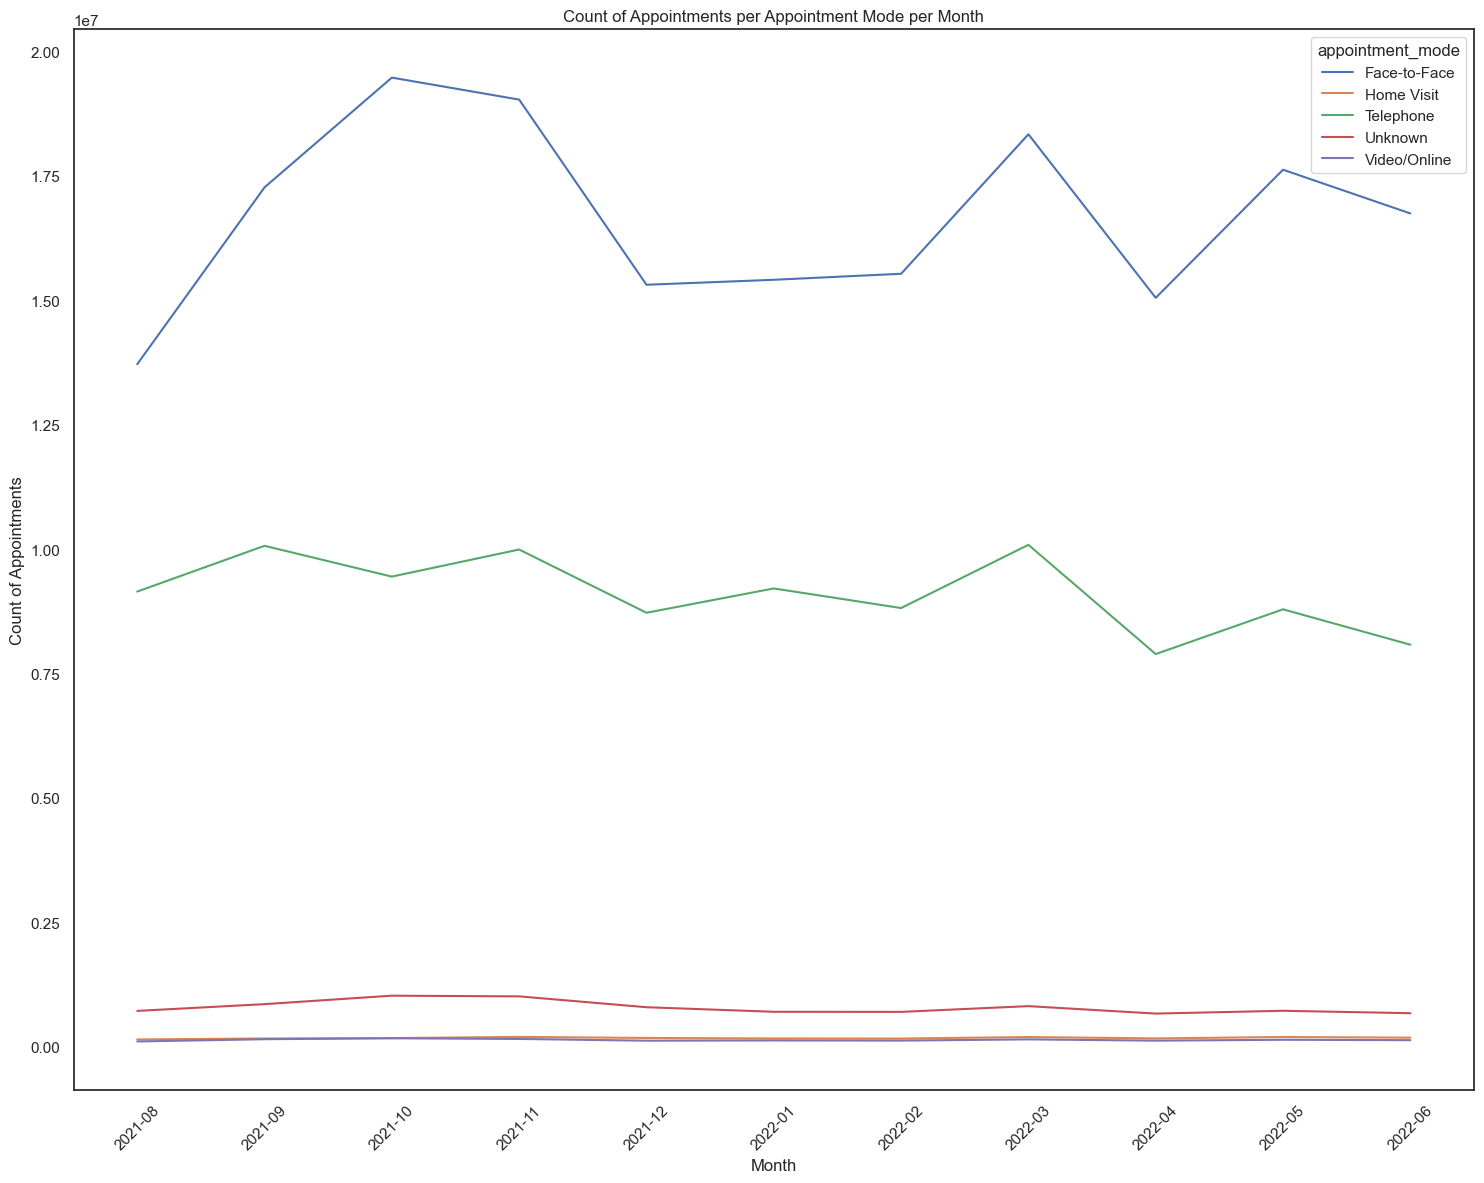

In [119]:
# Create a line plot to answer the question.
# Group the data by appointment_month and appointment_mode, then sum by count_of_appointments, and then reset the index.
ar_agg_appt_modes_by_month = ar_agg.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()

# Create a lineplot.
sns.lineplot(data = ar_agg_appt_modes_by_month, x = 'appointment_month', y = 'count_of_appointments', hue = 'appointment_mode')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Count of Appointments')
plt.title('Count of Appointments per Appointment Mode per Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** Demand was highest for face-to-face appointments in each of the observed months, followed by telephone appointments. Demand for both of these appointment types fluctuated broadly in line with overall demand trends. Meanwhile, demand for video/online appointments and home visits was much lower. However, the absolute demand for these modes was largely consistent each month, meaning it didn't fluctuate in line with overall demand trends.

**Question 5:** Are there any trends in time between booking and appointment?

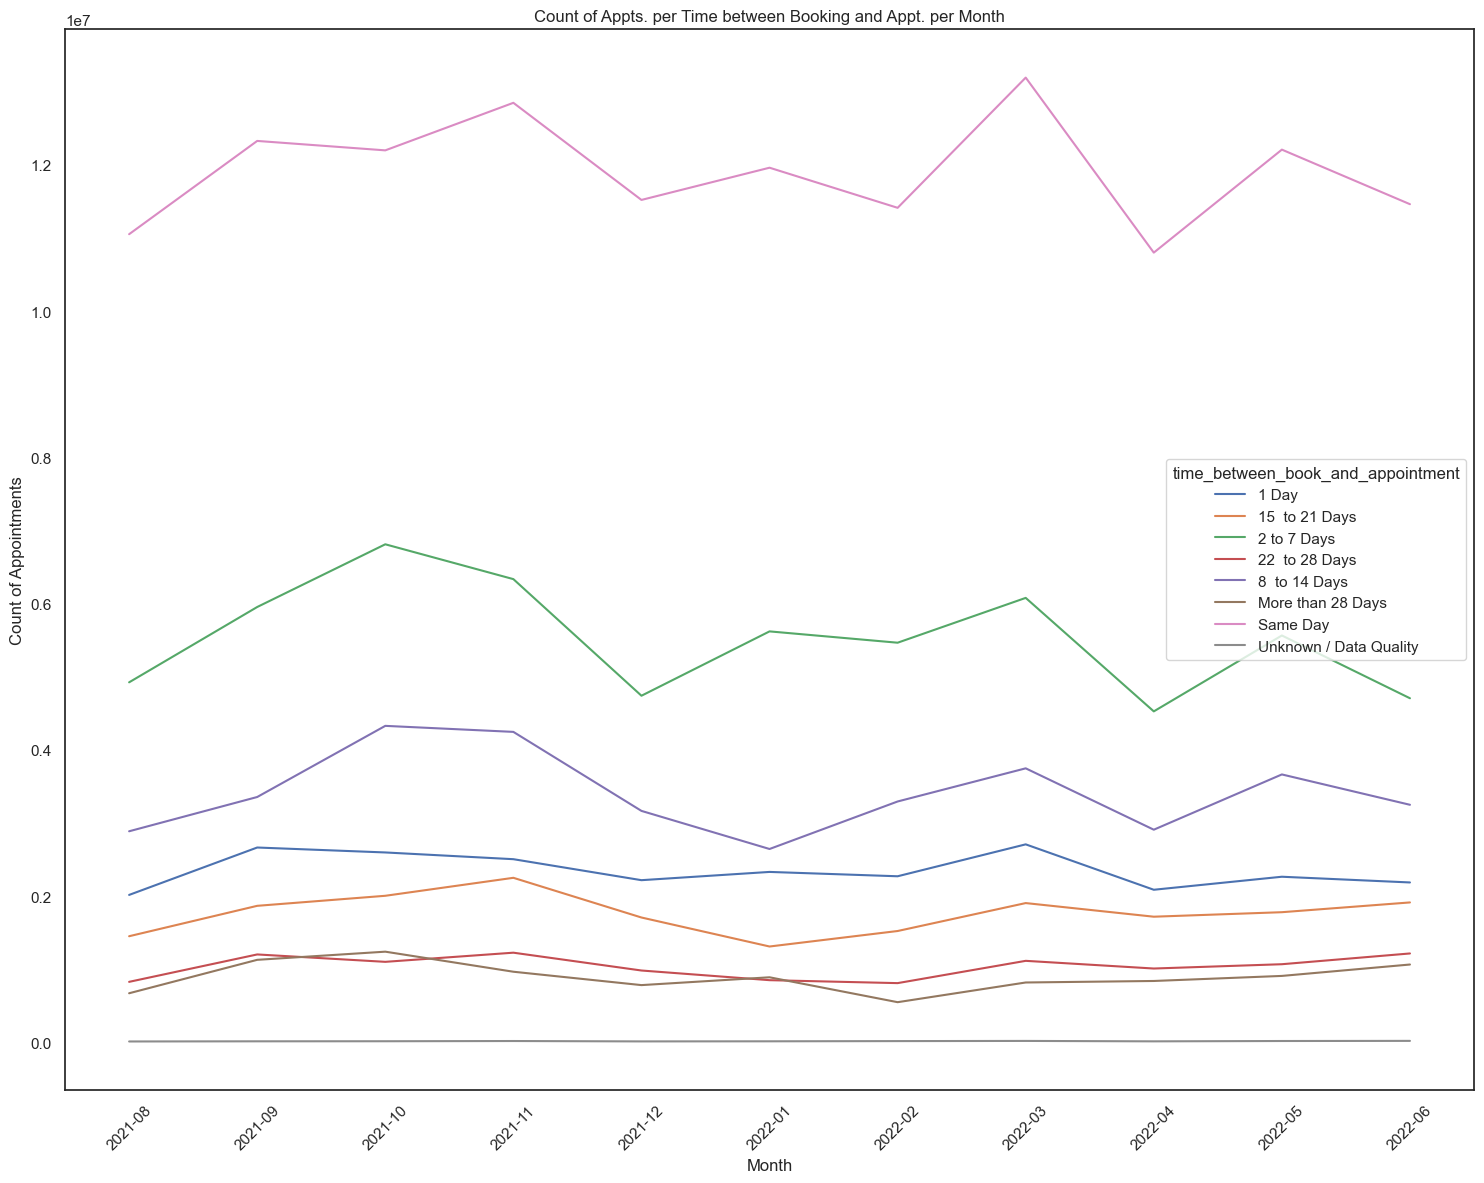

In [120]:
# Create a line plot to answer the question.
# Group the data by appointment_month and time_between_book_and_appointment, then sum by count_of_appointments, and then reset the index.
ar_agg_time_between_book_and_appt_by_month = ar_agg.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'] \
    .sum().reset_index()

# Create a lineplot.
sns.lineplot(data = ar_agg_time_between_book_and_appt_by_month, x = 'appointment_month', y = 'count_of_appointments', \
             hue = 'time_between_book_and_appointment')

# Add labels and title for clarity.
plt.xlabel('Month')
plt.ylabel('Count of Appointments')
plt.title('Count of Appts. per Time between Booking and Appt. per Month')

# Rotate x-axis labels if they overlap.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** Every month, most appointments took place on the same day they were booked. The next highest number of appointments were those that took place within 2-7 days of booking, then 8-14 days, then 1-day, and then 15-21 days. This could indicate that 1) most demand was of an urgent nature, or 2) primary care services had enough capacity to meet the demand they viewed as most urgent within a timely manner, with everything else being deemed a lower priority for managing later in the week/month (or both could be true). The fact that there were fewer appointments that were booked one day and seen the next, compared with appointments that were booked and then seen 2-7 days or 8-14 days later, is unusual, and could warrant further investigation.

**Question 6:** How do the various service settings compare?

In [121]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,icb_location_name
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,NHS North East and North Cumbria ICB
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,NHS North East and North Cumbria ICB
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,NHS North East and North Cumbria ICB
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,NHS North East and North Cumbria ICB
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,NHS North East and North Cumbria ICB


In [122]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_appts_by_month_aa6 = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
nc_appts_by_month_aa6.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


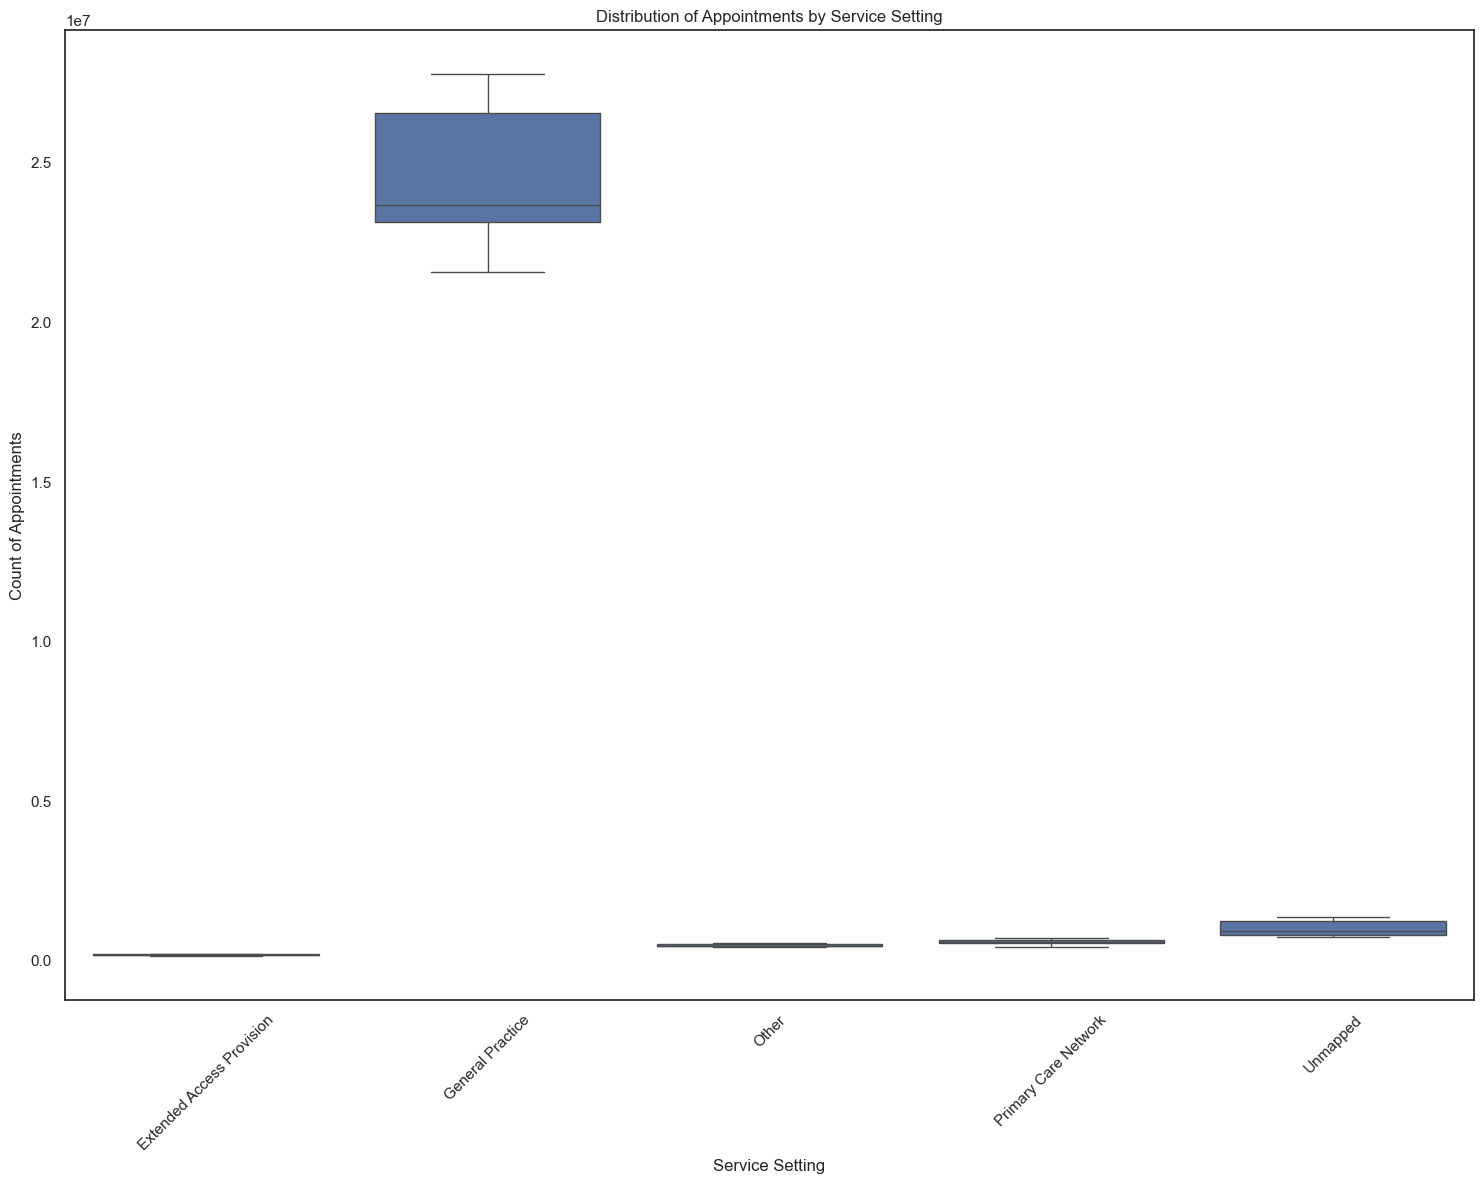

In [123]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
sns.boxplot(data = nc_appts_by_month_aa6, x = 'service_setting', y = 'count_of_appointments')

# Add labels and title for clarity.
plt.xlabel('Service Setting')
plt.ylabel('Count of Appointments')
plt.title('Distribution of Appointments by Service Setting')

# Rotate x-axis labels if needed.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** The vast majority of appointments take place in General Practice, as evidenced by the boxplot. This is making it difficult to understand the spread that each of the other service settings experiences. Therefore, the boxplot should be generated again, but this time, by excluding general practice.

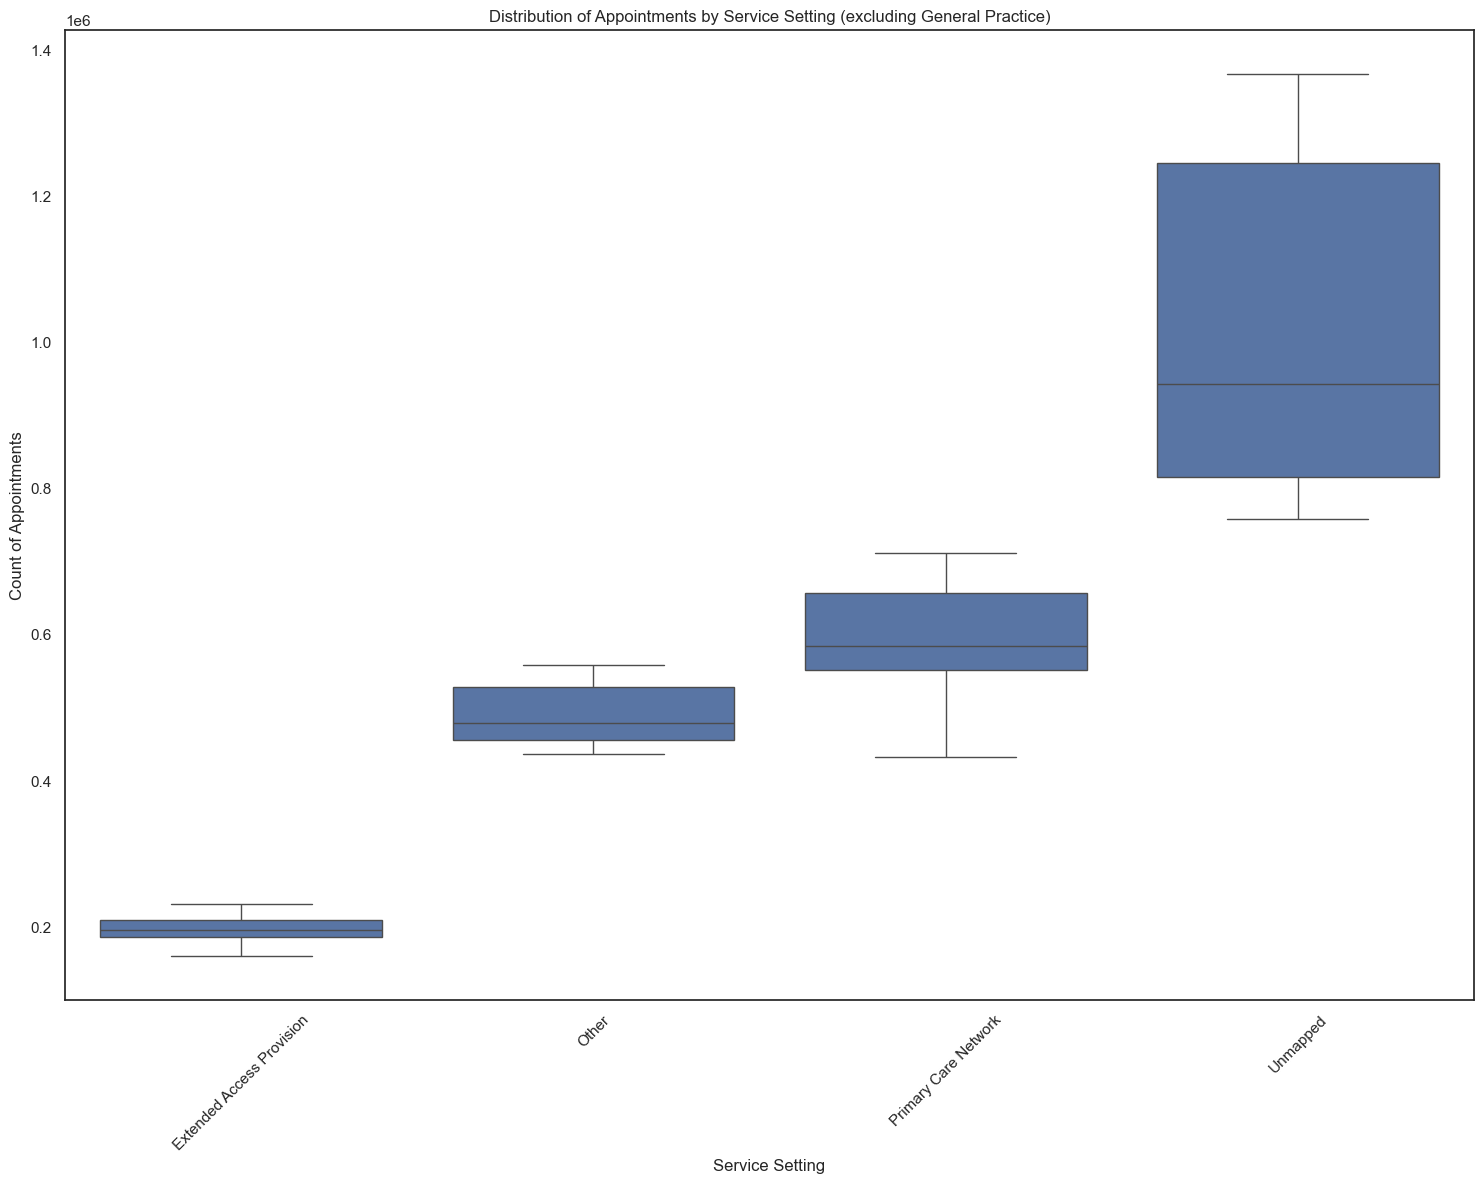

In [124]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding General Practice.
# Filter out General Practice.
nc_appts_by_month_aa6_no_gp = nc_appts_by_month_aa6[nc_appts_by_month_aa6['service_setting'] != 'General Practice']

# Create a boxplot excluding General Practice.
sns.boxplot(data = nc_appts_by_month_aa6_no_gp, x = 'service_setting', y = 'count_of_appointments')

# Add labels and title for clarity.
plt.xlabel('Service Setting')
plt.ylabel('Count of Appointments')
plt.title('Distribution of Appointments by Service Setting (excluding General Practice)')

# Rotate x-axis labels if needed.
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**Observation(s):** The spread of data can now be seen clearly for each service setting.

#### Summary of Insights and Recommendations:

**Has there been adequate capacity in primary care services?**

I believe it is fairly safe to say that, no, there was not adequate capacity, as at a national level, the NHS was unable manage its daily demand on more than half the observed days. Furthermore, I determined that six ICBs consistently had insufficient capacity to manage their demand.

However, I also determined that there were potential opportunities to make better use of existing NHS capacity.

Therefore, my recommendation is that these six ICBs try to shift some of their remote/virtual appointment demand to other six ICBs within their respective regions that were proven to have approximately 10 million unutilised appointments available over the total 11 months observed.
Before doing this, however, consideration would also need to be given to the appropriateness of shifting particular types of remote/virtual appointments, as some may need to be retained by a local service setting for quality and safety reasons.

**What was the actual utilisation of resources in primary care services?**

We have seen a huge difference between the national capacity utilisation of 74% and NHS North East and North Cumbria ICB’s utilisation of 177%, which indicates that significant variability is likely to have existed between all 42 ICBs. We have also seen that NHS North East and North Cumbria experienced a minimum of 4.81% DNAs for its face-to-face appointments and a minimum of 3.78% DNAs for its video/online appointments.

Therefore, my recommendation is that NHS England commissions this ICB to conduct a pilot study of implementing an overbooking policy, whereby they deliberately overbook their face-to-face appointments by 4.81% and their video/online appointments by 3.78% respectively. 
Before implementing such a policy, further work would be required to determine whether overbooking appointments based on monthly DNA rates is clinically safe.